# Viken KHATCHERIAN projet 10 Openclassrooms 

# Étape 4 — Apprentissage supervisé et semi-supervisé

## Objectif

L'objectif de cette étape est d'évaluer l'apport des données faiblement labellisées
dans une tâche de classification binaire `cancer` / `normal`.

Deux stratégies seront comparées :

1. **Apprentissage supervisé** :
   entraînement du CNN uniquement sur les images fortement labellisées du jeu
   d'entraînement.

2. **Apprentissage semi-supervisé** :
   pré-entraînement du même CNN sur les images faiblement labellisées,
   puis poursuite de l'entraînement sur les images fortement labellisées.

Dans les deux cas, l'évaluation finale sera réalisée sur un jeu de test fortement
labellisé, équilibré et strictement séparé des données utilisées pour l'entraînement.

Les principales métriques retenues seront l'accuracy, la précision, le rappel
(sensibilité), le F1-score et la matrice de confusion.

> Contexte : ce projet constitue une étude exploratoire de faisabilité en
> Computer Vision appliquée à l'imagerie cérébrale. Les résultats ne constituent
> pas une validation clinique d'un système de diagnostic.

In [2]:
# Imports et configuration

from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from PIL import Image

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

# Reproductibilité


SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Chemins du projet

PROJECT_ROOT = Path("/mnt/projects/vk_oc_projet10_brainscanai")

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"

EMBEDDINGS_PATH = PROCESSED_DIR / "embeddings_resnet50.csv"

# Configuration du calcul


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Projet : {PROJECT_ROOT}")
print(f"Device : {DEVICE}")

Projet : /mnt/projects/vk_oc_projet10_brainscanai
Device : cuda


In [3]:
# Chargement des embeddings produits dans le Notebook 1

if not EMBEDDINGS_PATH.exists():
    raise FileNotFoundError(
        f"Fichier introuvable : {EMBEDDINGS_PATH}"
    )

embeddings_df = pd.read_csv(EMBEDDINGS_PATH)

print("Dimensions :", embeddings_df.shape)
print("\nColonnes métadonnées :")
print(embeddings_df[["label", "subset", "filename", "path", "md5"]].head())

Dimensions : (1410, 2053)

Colonnes métadonnées :
    label   subset                                  filename  \
0  cancer  labeled  05340cd4-3bb2-459d-9937-bf27d52d8351.jpg   
1  cancer  labeled  0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg   
2  cancer  labeled  0f718241-8f63-4b55-81ce-315324b51069.jpg   
3  cancer  labeled  11a7a426-4806-401e-98b2-b96e7094d1a6.jpg   
4  cancer  labeled  1c043dbb-4623-4769-8e5e-0223bd745040.jpg   

                                                path  \
0  /mnt/projects/vk_oc_projet10_brainscanai/data/...   
1  /mnt/projects/vk_oc_projet10_brainscanai/data/...   
2  /mnt/projects/vk_oc_projet10_brainscanai/data/...   
3  /mnt/projects/vk_oc_projet10_brainscanai/data/...   
4  /mnt/projects/vk_oc_projet10_brainscanai/data/...   

                                md5  
0  82feb195cc989de29f0d584705afd746  
1  1fe2130e1834ff8646f635f6a6f86dc1  
2  32debb468cdfa4c513e648c61f8349f8  
3  bf80e340a7b4fcf553202847221bfe1f  
4  d642b0a782a25dee640a9b76a2f55112  


In [4]:
# Identification des jeux de données

# Images fortement labellisées
mask_strong = embeddings_df["subset"].eq("labeled")

strong_df = embeddings_df.loc[
    mask_strong,
    ["filename", "path", "md5", "label"]
].copy()

# Images faiblement labellisées
mask_weak = embeddings_df["subset"].eq("unlabeled")

weak_df = embeddings_df.loc[
    mask_weak,
    ["filename", "path", "md5"]
].copy()

print(f"Images fortement labellisées : {len(strong_df)}")
print(f"Images faiblement labellisées : {len(weak_df)}")

Images fortement labellisées : 99
Images faiblement labellisées : 1311


In [5]:
# Vérification des labels forts


print("Répartition des labels forts :")
print(strong_df["label"].value_counts())

print("\nNombre total :", len(strong_df))

Répartition des labels forts :
label
cancer    50
normal    49
Name: count, dtype: int64

Nombre total : 99


## Séparation du test final et préparation de la validation croisée

Les 99 images fortement labellisées sont séparées en deux parties :

- 79 images utilisées pour l'entraînement et la validation croisée ;
- 20 images conservées comme test final indépendant.

Les 20 images du test final ne seront utilisées ni pour l'entraînement,
ni pour la génération des pseudo-labels, ni pour le choix des hyperparamètres.

Une validation croisée stratifiée à 5 folds est ensuite appliquée aux
79 images restantes afin de limiter le risque de surapprentissage lié
au faible nombre d'images fortement labellisées.

In [6]:
# =============================================================================
# Séparation du test final et préparation de la validation croisée
# =============================================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold


print("Préparation de la validation croisée")
print("=" * 70)


# ---------------------------------------------------------------------------
# 1. Identifier les images fortement labellisées
# ---------------------------------------------------------------------------

mask_labeled = embeddings_df["subset"].values == "labeled"

labeled_indices = np.where(mask_labeled)[0]

y_labeled = embeddings_df.loc[
    mask_labeled,
    "label"
].values

print("Images fortement labellisées :", len(labeled_indices))
print("\nRépartition initiale :")
print(pd.Series(y_labeled).value_counts())


# ---------------------------------------------------------------------------
# 2. Séparer le test final
# ---------------------------------------------------------------------------
#
# Ces 20 images restent complètement indépendantes.
# Elles ne seront utilisées qu'une seule fois à la fin du projet.
# ---------------------------------------------------------------------------

labeled_train_indices, labeled_test_indices = train_test_split(
    labeled_indices,
    test_size=0.20,
    random_state=42,
    stratify=y_labeled
)


# Labels associés au train/CV et au test final

y_train_cv = embeddings_df.loc[
    labeled_train_indices,
    "label"
].values

y_test_final = embeddings_df.loc[
    labeled_test_indices,
    "label"
].values


print("\nSéparation finale")
print("-" * 70)

print("Train / CV :", len(labeled_train_indices))
print("Test final :", len(labeled_test_indices))

print("\nRépartition Train / CV :")
print(pd.Series(y_train_cv).value_counts())

print("\nRépartition Test final :")
print(pd.Series(y_test_final).value_counts())


# ---------------------------------------------------------------------------
# 3. Validation croisée stratifiée à 5 folds
# ---------------------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


folds = []

for fold_number, (train_fold_positions, val_fold_positions) in enumerate(
    skf.split(labeled_train_indices, y_train_cv),
    start=1
):

    fold_train_indices = labeled_train_indices[train_fold_positions]
    fold_val_indices = labeled_train_indices[val_fold_positions]

    y_fold_train = embeddings_df.loc[
        fold_train_indices,
        "label"
    ].values

    y_fold_val = embeddings_df.loc[
        fold_val_indices,
        "label"
    ].values

    folds.append({
        "fold": fold_number,
        "train_indices": fold_train_indices,
        "val_indices": fold_val_indices,
        "y_train": y_fold_train,
        "y_val": y_fold_val
    })

    print(f"\nFold {fold_number}")
    print("-" * 70)
    print("Train :", len(fold_train_indices))
    print("Validation :", len(fold_val_indices))

    print("Train :", pd.Series(y_fold_train).value_counts().to_dict())
    print("Validation :", pd.Series(y_fold_val).value_counts().to_dict())


# ---------------------------------------------------------------------------
# 4. Contrôles de sécurité
# ---------------------------------------------------------------------------

assert len(labeled_train_indices) == 79
assert len(labeled_test_indices) == 20

assert len(set(labeled_train_indices) & set(labeled_test_indices)) == 0

assert len(folds) == 5

for fold in folds:

    train_set = set(fold["train_indices"])
    val_set = set(fold["val_indices"])

    # Pas de chevauchement train / validation
    assert len(train_set & val_set) == 0

    # Les deux classes doivent être présentes
    assert set(fold["y_train"]) == {"cancer", "normal"}
    assert set(fold["y_val"]) == {"cancer", "normal"}

    # Aucun fold ne doit contenir le test final
    assert len(
        val_set & set(labeled_test_indices)
    ) == 0

    assert len(
        train_set & set(labeled_test_indices)
    ) == 0


print("\n" + "=" * 70)
print("✓ Validation de la structure Train / Validation / Test réussie.")
print("✓ 79 images réservées à la CV.")
print("✓ 20 images conservées pour le test final.")
print("✓ 5 folds stratifiés créés.")
print("✓ Aucun chevauchement détecté.")

Préparation de la validation croisée
Images fortement labellisées : 99

Répartition initiale :
cancer    50
normal    49
Name: count, dtype: int64

Séparation finale
----------------------------------------------------------------------
Train / CV : 79
Test final : 20

Répartition Train / CV :
cancer    40
normal    39
Name: count, dtype: int64

Répartition Test final :
normal    10
cancer    10
Name: count, dtype: int64

Fold 1
----------------------------------------------------------------------
Train : 63
Validation : 16
Train : {'cancer': 32, 'normal': 31}
Validation : {'normal': 8, 'cancer': 8}

Fold 2
----------------------------------------------------------------------
Train : 63
Validation : 16
Train : {'cancer': 32, 'normal': 31}
Validation : {'cancer': 8, 'normal': 8}

Fold 3
----------------------------------------------------------------------
Train : 63
Validation : 16
Train : {'cancer': 32, 'normal': 31}
Validation : {'cancer': 8, 'normal': 8}

Fold 4
------------------

## 1.2 — Génération des pseudo-labels dans chaque fold

Pour limiter le risque de fuite de données, la génération des pseudo-labels est réalisée séparément pour chacun des cinq folds.

Pour chaque fold :

* les images fortement labellisées du sous-ensemble d'entraînement sont utilisées pour établir la correspondance entre clusters et classes ;
* les 1 311 images initialement sans label sont intégrées au clustering ;
* le fold de validation est totalement exclu de cette étape ;
* la standardisation et la réduction dimensionnelle sont ajustées uniquement sur les données utilisées pour le clustering ;
* les pseudo-labels sont ensuite attribués aux images non labellisées ;
* le fold de validation est utilisé uniquement pour mesurer la capacité de cette attribution à retrouver les labels connus.

Le jeu de test final de 20 images reste complètement isolé et n'intervient à aucune étape de cette procédure.


In [7]:
# =============================================================================
# Génération des pseudo-labels fold par fold
# =============================================================================

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, f1_score

print("Clustering et génération des pseudo-labels fold par fold")
print("=" * 70)


# ---------------------------------------------------------------------------
# 1. Préparation des données communes
# ---------------------------------------------------------------------------

embedding_columns = [
    column
    for column in embeddings_df.columns
    if column.startswith("feature_")
]

# Indices des 1 311 images sans label
unlabeled_indices = weak_df.index.to_numpy()

# Embeddings des images sans label
X_unlabeled = embeddings_df.loc[
    unlabeled_indices,
    embedding_columns
].to_numpy(dtype=np.float32)

print("Images sans label :", len(unlabeled_indices))
print("Dimensions embeddings :", X_unlabeled.shape)


# ---------------------------------------------------------------------------
# 2. Conteneur pour stocker les résultats des folds
# ---------------------------------------------------------------------------

fold_results = []


# ---------------------------------------------------------------------------
# 3. Traitement indépendant de chaque fold
# ---------------------------------------------------------------------------

for fold in folds:

    fold_number = fold["fold"]

    fold_train_indices = fold["train_indices"]
    fold_val_indices = fold["val_indices"]

    y_fold_train = fold["y_train"]
    y_fold_val = fold["y_val"]

    print("\n" + "=" * 70)
    print(f"FOLD {fold_number}")
    print("=" * 70)

    print(
        f"Train fort : {len(fold_train_indices)} | "
        f"Validation : {len(fold_val_indices)} | "
        f"Sans label : {len(unlabeled_indices)}"
    )


    # -----------------------------------------------------------------------
    # 3.1 Embeddings du train fortement labellisé
    # -----------------------------------------------------------------------

    X_fold_train = embeddings_df.loc[
        fold_train_indices,
        embedding_columns
    ].to_numpy(dtype=np.float32)


    # -----------------------------------------------------------------------
    # 3.2 Ensemble utilisé pour le clustering
    #
    # IMPORTANT :
    # Le fold de validation et le test final ne sont PAS inclus.
    # -----------------------------------------------------------------------

    X_fold_clustering = np.vstack([
        X_fold_train,
        X_unlabeled
    ])

    print(
        "Ensemble de clustering :",
        X_fold_clustering.shape
    )


    # -----------------------------------------------------------------------
    # 3.3 Standardisation ajustée sur l'ensemble de clustering
    # -----------------------------------------------------------------------

    scaler_fold = StandardScaler()

    X_fold_scaled = scaler_fold.fit_transform(
        X_fold_clustering
    ).astype(np.float32)


    # -----------------------------------------------------------------------
    # 3.4 PCA
    #
    # On conserve environ 95 % de la variance.
    # Le nombre de composantes est déterminé indépendamment dans chaque fold.
    # -----------------------------------------------------------------------

    pca_full_fold = PCA(
        random_state=SEED
    )

    X_fold_pca_full = pca_full_fold.fit_transform(
        X_fold_scaled
    )

    cumulative_variance = np.cumsum(
        pca_full_fold.explained_variance_ratio_
    )

    n_components_fold = (
        np.argmax(cumulative_variance >= 0.95) + 1
    )

    pca_fold = PCA(
        n_components=n_components_fold,
        random_state=SEED
    )

    X_fold_pca = pca_fold.fit_transform(
        X_fold_scaled
    ).astype(np.float32)

    print(
        f"PCA : {X_fold_clustering.shape[1]} → "
        f"{n_components_fold} composantes"
    )

    print(
        f"Variance expliquée : "
        f"{pca_fold.explained_variance_ratio_.sum():.4f}"
    )


    # -----------------------------------------------------------------------
    # 3.5 K-Means
    # -----------------------------------------------------------------------

    kmeans_fold = KMeans(
        n_clusters=2,
        random_state=SEED,
        n_init=20,
        max_iter=300
    )

    clusters_fold = kmeans_fold.fit_predict(
        X_fold_pca
    )

    print("\nRépartition des clusters :")
    print(
        pd.Series(clusters_fold)
        .value_counts()
        .sort_index()
    )


    # -----------------------------------------------------------------------
    # 3.6 Correspondance cluster → classe
    #
    # IMPORTANT :
    # La correspondance est apprise uniquement sur le train fortement
    # labellisé du fold.
    # -----------------------------------------------------------------------

    clusters_strong_train = clusters_fold[
        :len(fold_train_indices)
    ]

    cluster_label_table = pd.crosstab(
        clusters_strong_train,
        y_fold_train
    )

    print("\nCorrespondance cluster / classe :")
    display(cluster_label_table)


    # -----------------------------------------------------------------------
    # Détermination automatique de la classe majoritaire de chaque cluster
    # -----------------------------------------------------------------------

    cluster_to_label_fold = {}

    for cluster_id in sorted(np.unique(clusters_strong_train)):

        cluster_mask = (
            clusters_strong_train == cluster_id
        )

        labels_in_cluster = y_fold_train[cluster_mask]

        majority_label = (
            pd.Series(labels_in_cluster)
            .value_counts()
            .idxmax()
        )

        cluster_to_label_fold[cluster_id] = majority_label


    print(
        "\nCorrespondance retenue :",
        cluster_to_label_fold
    )


    # -----------------------------------------------------------------------
    # 3.7 Génération des pseudo-labels pour les 1 311 images sans label
    # -----------------------------------------------------------------------

    weak_clusters_fold = clusters_fold[
        len(fold_train_indices):
    ]

    weak_labels_fold = pd.Series(
        weak_clusters_fold
    ).map(cluster_to_label_fold).to_numpy()


    # -----------------------------------------------------------------------
    # 3.8 Évaluation sur le fold de validation
    #
    # Le fold de validation n'a PAS participé au clustering.
    # Il sert uniquement à mesurer la capacité de la correspondance
    # cluster → classe à retrouver les labels connus.
    # -----------------------------------------------------------------------

    X_fold_val = embeddings_df.loc[
        fold_val_indices,
        embedding_columns
    ].to_numpy(dtype=np.float32)

    X_fold_val_scaled = scaler_fold.transform(
        X_fold_val
    ).astype(np.float32)

    X_fold_val_pca = pca_fold.transform(
        X_fold_val_scaled
    ).astype(np.float32)

    val_clusters = kmeans_fold.predict(
        X_fold_val_pca
    )

    val_predictions = pd.Series(
        val_clusters
    ).map(cluster_to_label_fold).to_numpy()


    val_accuracy = accuracy_score(
        y_fold_val,
        val_predictions
    )

    val_f1 = f1_score(
        y_fold_val,
        val_predictions,
        pos_label="cancer"
    )


    print("\nÉvaluation sur le fold de validation :")
    print(f"Accuracy : {val_accuracy:.4f}")
    print(f"F1 cancer : {val_f1:.4f}")


    # -----------------------------------------------------------------------
    # 3.9 Contrôles
    # -----------------------------------------------------------------------

    assert len(weak_labels_fold) == len(unlabeled_indices)

    assert set(weak_labels_fold) == {
        "cancer",
        "normal"
    }

    assert len(val_predictions) == len(fold_val_indices)

    assert not np.isnan(X_fold_pca).any()
    assert not np.isinf(X_fold_pca).any()


    # -----------------------------------------------------------------------
    # 3.10 Stockage des résultats
    # -----------------------------------------------------------------------

    fold_results.append({
        "fold": fold_number,
        "n_components": n_components_fold,
        "explained_variance": (
            pca_fold.explained_variance_ratio_.sum()
        ),
        "cluster_to_label": cluster_to_label_fold,
        "weak_labels": weak_labels_fold,
        "val_predictions": val_predictions,
        "val_true": y_fold_val.copy(),
        "val_accuracy": val_accuracy,
        "val_f1": val_f1
    })


# =============================================================================
# 4. Synthèse des performances de pseudo-labelisation
# =============================================================================

fold_metrics_df = pd.DataFrame([
    {
        "fold": result["fold"],
        "n_components": result["n_components"],
        "explained_variance": result["explained_variance"],
        "val_accuracy": result["val_accuracy"],
        "val_f1": result["val_f1"]
    }
    for result in fold_results
])

print("\n" + "=" * 70)
print("Synthèse de la validation croisée")
print("=" * 70)

display(fold_metrics_df)

print("\nMoyenne Accuracy :",
      f"{fold_metrics_df['val_accuracy'].mean():.4f}")

print("Écart-type Accuracy :",
      f"{fold_metrics_df['val_accuracy'].std():.4f}")

print("\nMoyenne F1 cancer :",
      f"{fold_metrics_df['val_f1'].mean():.4f}")

print("Écart-type F1 cancer :",
      f"{fold_metrics_df['val_f1'].std():.4f}")


# Contrôle final
assert len(fold_results) == 5

print("\n✓ Les cinq folds ont été traités indépendamment.")
print("✓ Le fold de validation n'a pas participé au clustering.")
print("✓ Le test final n'a pas été utilisé.")
print("✓ Les pseudo-labels ont été générés automatiquement par fold.")

Clustering et génération des pseudo-labels fold par fold
Images sans label : 1311
Dimensions embeddings : (1311, 2048)

FOLD 1
Train fort : 63 | Validation : 16 | Sans label : 1311
Ensemble de clustering : (1374, 2048)
PCA : 2048 → 667 composantes
Variance expliquée : 0.9492

Répartition des clusters :
0    511
1    863
Name: count, dtype: int64

Correspondance cluster / classe :


col_0,cancer,normal
row_0,,
0,17,2
1,15,29



Correspondance retenue : {np.int32(0): 'cancer', np.int32(1): 'normal'}

Évaluation sur le fold de validation :
Accuracy : 0.6875
F1 cancer : 0.5455

FOLD 2
Train fort : 63 | Validation : 16 | Sans label : 1311
Ensemble de clustering : (1374, 2048)
PCA : 2048 → 666 composantes
Variance expliquée : 0.9490

Répartition des clusters :
0    507
1    867
Name: count, dtype: int64

Correspondance cluster / classe :


col_0,cancer,normal
row_0,,
0,16,1
1,16,30



Correspondance retenue : {np.int32(0): 'cancer', np.int32(1): 'normal'}

Évaluation sur le fold de validation :
Accuracy : 0.6875
F1 cancer : 0.6154

FOLD 3
Train fort : 63 | Validation : 16 | Sans label : 1311
Ensemble de clustering : (1374, 2048)
PCA : 2048 → 667 composantes
Variance expliquée : 0.9490

Répartition des clusters :
0    867
1    507
Name: count, dtype: int64

Correspondance cluster / classe :


...


Correspondance retenue : {np.int32(0): 'cancer', np.int32(1): 'normal'}

Évaluation sur le fold de validation :
Accuracy : 0.7500
F1 cancer : 0.6667

FOLD 5
Train fort : 64 | Validation : 15 | Sans label : 1311
Ensemble de clustering : (1375, 2048)
PCA : 2048 → 667 composantes
Variance expliquée : 0.9492

Répartition des clusters :
0    882
1    493
Name: count, dtype: int64

Correspondance cluster / classe :


col_0,cancer,normal
row_0,,
0,16,31
1,16,1



Correspondance retenue : {np.int32(0): 'normal', np.int32(1): 'cancer'}

Évaluation sur le fold de validation :
Accuracy : 0.6667
F1 cancer : 0.6154

Synthèse de la validation croisée


,fold,n_components,explained_variance,val_accuracy,val_f1
0,1,667,0.949208,0.687500,0.545455
1,2,666,0.949009,0.687500,0.615385
2,3,667,0.949041,0.812500,0.769231
3,4,666,0.949144,0.750000,0.666667
4,5,667,0.949158,0.666667,0.615385



Moyenne Accuracy : 0.7208
Écart-type Accuracy : 0.0600

Moyenne F1 cancer : 0.6424
Écart-type F1 cancer : 0.0830

✓ Les cinq folds ont été traités indépendamment.
✓ Le fold de validation n'a pas participé au clustering.
✓ Le test final n'a pas été utilisé.
✓ Les pseudo-labels ont été générés automatiquement par fold.


Le clustering fournit une première source de pseudo-labels, avec une performance moyenne de F1 de 0,64 sur les folds de validation, mais une variabilité inter-folds qui souligne le caractère bruité des pseudo-labels. 

> **Aucune fuite de données entre les folds n'est introduite par le pipeline de clustering et de pseudo-labellisation actuel. Le scaler, la PCA, le K-Means et la correspondance cluster-classe sont ajustés séparément pour chaque fold à partir du train du fold et des données non labellisées. Les données de validation sont uniquement transformées/prédites après apprentissage, et les 20 images du test final restent exclues de l'ensemble du processus.**

Les résultats montrent également quelque chose de très utile pour la suite :

**F1-score `cancer` moyen = 0,642 ± 0,083** → les pseudo-labels sont exploitables comme **signal faible**, mais ils sont suffisamment bruités pour justifier une stratégie semi-supervisée prudente.

## 1.3 — Analyse de la stabilité des pseudo-labels

Les pseudo-labels générés par K-Means sont comparés entre les cinq folds afin d'identifier les images dont l'attribution de classe est stable ou au contraire incertaine.

Une image recevant systématiquement le même pseudo-label est considérée comme plus stable qu'une image dont le pseudo-label varie selon le fold.

Cette analyse permet de limiter l'influence des pseudo-labels potentiellement bruités lors de l'entraînement du modèle semi-supervisé.


In [8]:
# =============================================================================
# Analyse de la stabilité des pseudo-labels entre les folds
# =============================================================================

print("Analyse de la stabilité des pseudo-labels")
print("=" * 70)


# ---------------------------------------------------------------------------
# 1. Construire une matrice :
#    lignes = images sans label
#    colonnes = folds
#    valeurs = pseudo-label attribué
# ---------------------------------------------------------------------------

weak_stability_df = pd.DataFrame(
    index=unlabeled_indices
)

for result in fold_results:

    fold_number = result["fold"]

    weak_stability_df[f"fold_{fold_number}"] = (
        result["weak_labels"]
    )


# Ajouter les informations d'identification des images

weak_stability_df["path"] = embeddings_df.loc[
    unlabeled_indices,
    "path"
].values

weak_stability_df["filename"] = embeddings_df.loc[
    unlabeled_indices,
    "filename"
].values


# ---------------------------------------------------------------------------
# 2. Vérifier que les cinq folds sont présents
# ---------------------------------------------------------------------------

fold_columns = [
    f"fold_{fold_number}"
    for fold_number in range(1, 6)
]

assert all(
    column in weak_stability_df.columns
    for column in fold_columns
)

assert len(weak_stability_df) == 1311


# ---------------------------------------------------------------------------
# 3. Calculer le nombre de folds attribuant chaque classe
# ---------------------------------------------------------------------------

weak_stability_df["n_cancer"] = (
    weak_stability_df[fold_columns]
    .eq("cancer")
    .sum(axis=1)
)

weak_stability_df["n_normal"] = (
    weak_stability_df[fold_columns]
    .eq("normal")
    .sum(axis=1)
)


# ---------------------------------------------------------------------------
# 4. Déterminer le pseudo-label majoritaire
# ---------------------------------------------------------------------------

weak_stability_df["weak_label_majority"] = np.where(
    weak_stability_df["n_cancer"] >= weak_stability_df["n_normal"],
    "cancer",
    "normal"
)


# ---------------------------------------------------------------------------
# 5. Calculer le niveau de stabilité
#
# Exemple :
# 5/5 → stabilité maximale
# 4/5 → stabilité élevée
# 3/5 → stabilité faible
# ---------------------------------------------------------------------------

weak_stability_df["stability"] = (
    weak_stability_df[
        ["n_cancer", "n_normal"]
    ].max(axis=1) / len(fold_columns)
)


# ---------------------------------------------------------------------------
# 6. Classer les images selon leur stabilité
# ---------------------------------------------------------------------------

def classify_stability(value):

    if value == 1.0:
        return "très stable"

    elif value >= 0.8:
        return "stable"

    else:
        return "instable"


weak_stability_df["stability_level"] = (
    weak_stability_df["stability"]
    .apply(classify_stability)
)


# ---------------------------------------------------------------------------
# 7. Résumé
# ---------------------------------------------------------------------------

print("Répartition des pseudo-labels majoritaires :")
print(
    weak_stability_df["weak_label_majority"]
    .value_counts()
)

print("\nRépartition de la stabilité :")
print(
    weak_stability_df["stability_level"]
    .value_counts()
)

print("\nRésumé numérique :")

stability_summary = (
    weak_stability_df["stability"]
    .value_counts()
    .sort_index(ascending=False)
    .rename_axis("stability")
    .reset_index(name="n_images")
)

stability_summary["percentage"] = (
    100
    * stability_summary["n_images"]
    / len(weak_stability_df)
)

display(stability_summary)


# ---------------------------------------------------------------------------
# 8. Contrôles
# ---------------------------------------------------------------------------

assert (
    weak_stability_df["weak_label_majority"]
    .isin(["cancer", "normal"])
    .all()
)

assert (
    weak_stability_df["stability"]
    .between(0.5, 1.0)
    .all()
)

assert (
    weak_stability_df["stability_level"]
    .isin([
        "très stable",
        "stable",
        "instable"
    ])
    .all()
)


print("\n" + "=" * 70)
print("✓ Analyse de stabilité des pseudo-labels terminée.")
print("✓ 1 311 images analysées sur les 5 folds.")
print("✓ Aucun pseudo-label manquant.")

Analyse de la stabilité des pseudo-labels
Répartition des pseudo-labels majoritaires :
weak_label_majority
normal    821
cancer    490
Name: count, dtype: int64

Répartition de la stabilité :
stability_level
très stable    1295
stable           15
instable          1
Name: count, dtype: int64

Résumé numérique :


,stability,n_images,percentage
0,1.0,1295,98.779558
1,0.8,15,1.144165
2,0.6,1,0.076278



✓ Analyse de stabilité des pseudo-labels terminée.
✓ 1 311 images analysées sur les 5 folds.
✓ Aucun pseudo-label manquant.


## Ce que nous pouvons conclure

- **1 295 / 1 311 = 98,78 %** des images ont reçu exactement le même pseudo-label sur les 5 folds.
- **15 images = 1,14 %** sont stables à 4 folds sur 5.
- **1 image = 0,08 %** est réellement instable, avec seulement 3 folds sur 5 donnant le même label.
- Aucun pseudo-label n'est manquant.
- La répartition majoritaire est :
  - **821 normal**
  - **490 cancer**

Ainsi, la génération des pseudo-labels par K-Means est **très stable vis-à-vis de la variation du sous-ensemble fortement labellisé utilisé dans chaque fold**.

In [9]:
# =============================================================================
# Identification des pseudo-labels instables
# =============================================================================

unstable_pseudo_labels_df = weak_stability_df[
    weak_stability_df["stability"] < 1.0
].copy()

# Affichage des informations utiles
display(
    unstable_pseudo_labels_df[
        [
            "filename",
            "path",
            "fold_1",
            "fold_2",
            "fold_3",
            "fold_4",
            "fold_5",
            "n_cancer",
            "n_normal",
            "weak_label_majority",
            "stability",
            "stability_level",
        ]
    ].sort_values(
        by=["stability", "filename"]
    )
)

print("\nNombre d'images avec pseudo-label non parfaitement stable :", 
      len(unstable_pseudo_labels_df))

print("\nRépartition par niveau de stabilité :")
print(
    unstable_pseudo_labels_df["stability_level"]
    .value_counts()
)

# Vérifications
assert len(unstable_pseudo_labels_df) == 16
assert (unstable_pseudo_labels_df["stability"] < 1.0).all()
assert unstable_pseudo_labels_df["weak_label_majority"].isin(
    ["cancer", "normal"]
).all()

print("\n" + "=" * 70)
print("✓ Les 16 images dont le pseudo-label varie entre les folds ont été identifiées.")

,filename,path,fold_1,fold_2,fold_3,fold_4,fold_5,n_cancer,n_normal,weak_label_majority,stability,stability_level
1218,dc1bf07f-df38-49bf-8310-af79d9ccf51c.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,cancer,normal,normal,cancer,normal,2,3,normal,0.6,instable
100,00366e8d-5520-4d3c-a70b-91a7eec1f521.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,cancer,cancer,cancer,cancer,normal,4,1,cancer,0.8,stable
195,100d0f9e-344d-466b-99a7-ff8dd90b7611.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,cancer,cancer,cancer,cancer,normal,4,1,cancer,0.8,stable
515,4fc6fd73-542f-4f22-a4c1-db9804334e69.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,cancer,normal,normal,normal,normal,1,4,normal,0.8,stable
518,5068407e-c4f6-4d77-9a17-eb936200b368.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,cancer,cancer,cancer,cancer,normal,4,1,cancer,0.8,stable
615,6127ee10-688a-4e71-9b84-e80719bf4ef8.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,cancer,cancer,cancer,cancer,normal,4,1,cancer,0.8,stable
717,7438ba9a-e4a5-438a-b6e0-b60eb3b71fd0.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,cancer,cancer,cancer,cancer,normal,4,1,cancer,0.8,stable
718,744e73bc-29c6-4116-9236-785d2c4091b4.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,cancer,cancer,cancer,cancer,normal,4,1,cancer,0.8,stable
824,8bfd3282-7260-46c9-8e01-864fa9cde88f.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,cancer,cancer,cancer,cancer,normal,4,1,cancer,0.8,stable
921,a3337a5a-2572-42d5-b94d-737da22ff3a9.jpg,/mnt/projects/vk_oc_projet10_brainscanai/data/...,cancer,cancer,cancer,cancer,normal,4,1,cancer,0.8,stable



Nombre d'images avec pseudo-label non parfaitement stable : 16

Répartition par niveau de stabilité :
stability_level
stable      15
instable     1
Name: count, dtype: int64

✓ Les 16 images dont le pseudo-label varie entre les folds ont été identifiées.


## 1.5 — Analyse des désaccords entre les folds

Les désaccords observés dans les pseudo-labels sont analysés fold par fold afin de vérifier si certaines variations sont principalement associées à un fold particulier.

Cette analyse permet de distinguer une instabilité aléatoire de variations systématiques liées à la composition des données d'entraînement de chaque fold.

In [11]:
# =============================================================================
# Analyse des désaccords par fold
# =============================================================================

print("Analyse des désaccords par fold")
print("=" * 70)

# Pour chaque fold, compter les images dont le pseudo-label
# diffère du pseudo-label majoritaire
disagreement_by_fold = {}

for fold_column in fold_columns:
    disagreement_by_fold[fold_column] = (
        weak_stability_df[fold_column]
        != weak_stability_df["weak_label_majority"]
    ).sum()

disagreement_by_fold_df = (
    pd.Series(disagreement_by_fold, name="n_disagreements")
    .rename_axis("fold")
    .reset_index()
)

disagreement_by_fold_df["percentage"] = (
    100
    * disagreement_by_fold_df["n_disagreements"]
    / len(weak_stability_df)
)

display(disagreement_by_fold_df)

print("\nDétail des désaccords :")

for fold_column in fold_columns:
    n_disagreements = disagreement_by_fold_df.loc[
        disagreement_by_fold_df["fold"] == fold_column,
        "n_disagreements"
    ].iloc[0]

    print(
        f"{fold_column} : "
        f"{int(n_disagreements)} image(s) en désaccord avec le label majoritaire"
    )

# Vérifications
assert len(disagreement_by_fold_df) == 5
assert disagreement_by_fold_df["n_disagreements"].sum() == 17

print("\n" + "=" * 70)
print("✓ Analyse des désaccords par fold terminée.")

Analyse des désaccords par fold


,fold,n_disagreements,percentage
0,fold_1,2,0.152555
1,fold_2,0,0.000000
2,fold_3,0,0.000000
3,fold_4,1,0.076278
4,fold_5,14,1.067887



Détail des désaccords :
fold_1 : 2 image(s) en désaccord avec le label majoritaire
fold_2 : 0 image(s) en désaccord avec le label majoritaire
fold_3 : 0 image(s) en désaccord avec le label majoritaire
fold_4 : 1 image(s) en désaccord avec le label majoritaire
fold_5 : 14 image(s) en désaccord avec le label majoritaire

✓ Analyse des désaccords par fold terminée.


In [12]:
# =============================================================================
# Comparaison de la répartition des pseudo-labels entre les folds
# =============================================================================

print("Répartition des pseudo-labels par fold")
print("=" * 70)

pseudo_label_distribution = []

for fold_column in fold_columns:
    counts = weak_stability_df[fold_column].value_counts()

    pseudo_label_distribution.append({
        "fold": fold_column,
        "n_cancer": counts.get("cancer", 0),
        "n_normal": counts.get("normal", 0),
    })

pseudo_label_distribution_df = pd.DataFrame(
    pseudo_label_distribution
)

pseudo_label_distribution_df["pct_cancer"] = (
    100
    * pseudo_label_distribution_df["n_cancer"]
    / len(weak_stability_df)
)

pseudo_label_distribution_df["pct_normal"] = (
    100
    * pseudo_label_distribution_df["n_normal"]
    / len(weak_stability_df)
)

display(pseudo_label_distribution_df)

# Vérifications
assert len(pseudo_label_distribution_df) == 5

for _, row in pseudo_label_distribution_df.iterrows():
    assert row["n_cancer"] + row["n_normal"] == len(weak_stability_df)

print("\n" + "=" * 70)
print("✓ Répartition des pseudo-labels comparée entre les 5 folds.")

Répartition des pseudo-labels par fold


,fold,n_cancer,n_normal,pct_cancer,pct_normal
0,fold_1,492,819,37.528604,62.471396
1,fold_2,490,821,37.376049,62.623951
2,fold_3,490,821,37.376049,62.623951
3,fold_4,491,820,37.452326,62.547674
4,fold_5,476,835,36.308162,63.691838



✓ Répartition des pseudo-labels comparée entre les 5 folds.


Le fold 5 produit donc un peu moins de pseudo-labels `cancer`, mais l'écart reste faible : **environ 1,2 point de pourcentage** par rapport aux autres folds.

> **La répartition globale des pseudo-labels est stable entre les cinq folds. Le nombre de pseudo-labels `cancer` varie de 476 à 492, soit une variation maximale de 16 images (≈ 1,2 point de pourcentage). Le fold 5 présente néanmoins une légère tendance à attribuer davantage de pseudo-labels `normal`. Cette différence est principalement due aux 14 images identifiées précédemment comme des désaccords avec le pseudo-label majoritaire.**

Cela montre que **le problème n'est pas une instabilité globale du modèle de clustering**. Il concerne essentiellement un petit groupe d'images proches de la frontière de décision.

In [13]:
# =============================================================================
# Stabilité des pseudo-labels selon la classe majoritaire
# =============================================================================

print("Stabilité des pseudo-labels selon la classe majoritaire")
print("=" * 70)

stability_by_label = (
    weak_stability_df
    .groupby("weak_label_majority")["stability"]
    .agg(
        n_images="count",
        mean="mean",
        median="median",
        min="min",
        max="max"
    )
    .reset_index()
)

display(stability_by_label)

# Distribution des niveaux de stabilité par classe
stability_level_by_label = pd.crosstab(
    weak_stability_df["weak_label_majority"],
    weak_stability_df["stability_level"]
)

display(stability_level_by_label)

# Vérifications
assert set(stability_by_label["weak_label_majority"]) == {
    "cancer",
    "normal"
}

assert stability_by_label["n_images"].sum() == 1311

print("\n" + "=" * 70)
print("✓ Stabilité des pseudo-labels analysée selon la classe.")

Stabilité des pseudo-labels selon la classe majoritaire


,weak_label_majority,n_images,mean,median,min,max
0,cancer,490,0.994286,1.0,0.8,1.0
1,normal,821,0.999269,1.0,0.6,1.0


stability_level,instable,stable,très stable
weak_label_majority,,,
cancer,0,14,476
normal,1,1,819



✓ Stabilité des pseudo-labels analysée selon la classe.


### Ce que montrent les résultats

**Pseudo-label `normal` :**

- **821 images**
- Stabilité moyenne : **99,93 %**
- **819/821** sont parfaitement stables (5/5)
- **1** est stable à 4/5
- **1** est instable à 3/5

**Pseudo-label `cancer` :**

- **490 images**
- Stabilité moyenne : **99,43 %**
- **476/490** sont parfaitement stables
- **14/490** sont stables à 4/5
- Aucune n'est instable à 3/5

Ainsi, la stabilité est **très élevée pour les deux classes**, mais les pseudo-labels `cancer` sont légèrement plus sensibles aux variations entre les folds.

### Décision prise

Ne **pas**  supprimer arbitrairement les 15 images à 4/5.

Nous avons une meilleure stratégie :

#### Niveau 1 — Pseudo-label haute confiance

**Stabilité = 1.0 → 1 295 images**

Ces images ont reçu le même pseudo-label dans les **5 folds**.

#### Niveau 2 — Pseudo-label intermédiaire

**Stabilité = 0.8 → 15 images**

Ces images ont reçu le même pseudo-label dans **4 folds sur 5**.

#### Niveau 3 — Pseudo-label incertain

**Stabilité = 0.6 → 1 image**

Cette image est réellement instable.

Pour l'entraînement semi-supervisé, je recommande donc **de commencer avec les 1 295 pseudo-labels 5/5 uniquement**. Cela donne un premier jeu pseudo-labellisé très conservateur.

Puis, dans le cadre du **tuning**, nous pourrons comparer objectivement :

- seuil `1.0`
- seuil `0.8`

et vérifier si l'ajout des 15 images améliore ou dégrade le **F1-score** et le **recall** sur les jeux de validation.

### 1.6 — Constitution du jeu pseudo-labellisé haute confiance

Afin de limiter l'introduction de bruit dans l'apprentissage semi-supervisé, seules les images dont le pseudo-label est identique dans les cinq folds sont retenues dans un premier temps.

Ce seuil de stabilité de 100 % constitue une stratégie conservatrice. Un seuil moins strict (4 folds sur 5) pourra être évalué ultérieurement comme hyperparamètre lors de la comparaison des approches.

In [14]:
# =============================================================================
# Constitution du jeu pseudo-labellisé haute confiance
# =============================================================================

print("Constitution du jeu pseudo-labellisé haute confiance")
print("=" * 70)

HIGH_CONFIDENCE_THRESHOLD = 1.0

high_confidence_mask = (
    weak_stability_df["stability"] >= HIGH_CONFIDENCE_THRESHOLD
)

high_confidence_df = weak_stability_df.loc[
    high_confidence_mask
].copy()

# Récupération des informations nécessaires à l'entraînement
high_confidence_df["pseudo_label"] = (
    high_confidence_df["weak_label_majority"]
)

# Vérifications
assert len(high_confidence_df) == 1295
assert (
    high_confidence_df["stability"] == 1.0
).all()

assert high_confidence_df["pseudo_label"].isin(
    ["cancer", "normal"]
).all()

# Répartition des pseudo-labels
print("Nombre d'images pseudo-labellisées :", len(high_confidence_df))

print("\nRépartition des pseudo-labels :")
print(
    high_confidence_df["pseudo_label"]
    .value_counts()
)

print("\nRépartition en pourcentage :")
print(
    high_confidence_df["pseudo_label"]
    .value_counts(normalize=True).mul(100).round(2)
)

print("\nImages exclues du jeu haute confiance :")
print(
    len(weak_stability_df) - len(high_confidence_df)
)

print("\n" + "=" * 70)
print("✓ Jeu pseudo-labellisé haute confiance constitué.")
print("✓ Seules les images stables dans les 5 folds sont retenues.")

Constitution du jeu pseudo-labellisé haute confiance
Nombre d'images pseudo-labellisées : 1295

Répartition des pseudo-labels :
pseudo_label
normal    819
cancer    476
Name: count, dtype: int64

Répartition en pourcentage :
pseudo_label
normal    63.24
cancer    36.76
Name: proportion, dtype: float64

Images exclues du jeu haute confiance :
16

✓ Jeu pseudo-labellisé haute confiance constitué.
✓ Seules les images stables dans les 5 folds sont retenues.


In [15]:
# =============================================================================
# 1.7 — Préparation des jeux d'entraînement et du test final
# =============================================================================

print("Préparation des jeux de données")
print("=" * 70)

# -------------------------------------------------------------------------
# 1. Jeu pseudo-labellisé haute confiance
# -------------------------------------------------------------------------
# On utilise uniquement les 1 295 images dont le pseudo-label
# est identique dans les 5 folds.

weak_high_confidence_df = embeddings_df.loc[
    high_confidence_df.index,
    ["filename", "path", "md5"]
].copy()

weak_high_confidence_df["weak_label"] = (
    high_confidence_df["pseudo_label"].values
)

# -------------------------------------------------------------------------
# 2. Jeu fortement labellisé d'entraînement
# -------------------------------------------------------------------------
# Les 79 images du train/CV sont celles définies précédemment
# par labeled_train_indices.

strong_train_df = embeddings_df.loc[
    labeled_train_indices,
    ["filename", "path", "md5", "label"]
].copy()

# -------------------------------------------------------------------------
# 3. Jeu fortement labellisé de test final
# -------------------------------------------------------------------------
# Ces 20 images restent totalement isolées.

strong_test_df = embeddings_df.loc[
    labeled_test_indices,
    ["filename", "path", "md5", "label"]
].copy()

# -------------------------------------------------------------------------
# Contrôles des dimensions
# -------------------------------------------------------------------------

print(f"Weak haute confiance : {len(weak_high_confidence_df)} images")
print(f"Strong train         : {len(strong_train_df)} images")
print(f"Strong test          : {len(strong_test_df)} images")

assert len(weak_high_confidence_df) == 1295
assert len(strong_train_df) == 79
assert len(strong_test_df) == 20

# -------------------------------------------------------------------------
# Répartition des labels
# -------------------------------------------------------------------------

print("\nRépartition des pseudo-labels :")
print(
    weak_high_confidence_df["weak_label"].value_counts()
)

print("\nRépartition du strong train :")
print(
    strong_train_df["label"].value_counts()
)

print("\nRépartition du strong test :")
print(
    strong_test_df["label"].value_counts()
)

# -------------------------------------------------------------------------
# Contrôle des chevauchements
# -------------------------------------------------------------------------

weak_files = set(weak_high_confidence_df["filename"])
train_files = set(strong_train_df["filename"])
test_files = set(strong_test_df["filename"])

overlap_weak_train = weak_files & train_files
overlap_weak_test = weak_files & test_files
overlap_train_test = train_files & test_files

print("\nContrôle des chevauchements :")
print(f"Weak / train : {len(overlap_weak_train)}")
print(f"Weak / test  : {len(overlap_weak_test)}")
print(f"Train / test : {len(overlap_train_test)}")

assert len(overlap_weak_train) == 0
assert len(overlap_weak_test) == 0
assert len(overlap_train_test) == 0

# -------------------------------------------------------------------------
# Contrôle des labels
# -------------------------------------------------------------------------

assert weak_high_confidence_df["weak_label"].isin(
    ["cancer", "normal"]
).all()

assert strong_train_df["label"].isin(
    ["cancer", "normal"]
).all()

assert strong_test_df["label"].isin(
    ["cancer", "normal"]
).all()

print("\n" + "=" * 70)
print("✓ Jeux de données préparés.")
print("✓ 1 295 pseudo-labels haute confiance.")
print("✓ 79 images strong pour train/CV.")
print("✓ 20 images strong réservées au test final.")
print("✓ Aucun chevauchement détecté.")
print("✓ Le test final reste isolé.")

Préparation des jeux de données
Weak haute confiance : 1295 images
Strong train         : 79 images
Strong test          : 20 images

Répartition des pseudo-labels :
weak_label
normal    819
cancer    476
Name: count, dtype: int64

Répartition du strong train :
label
cancer    40
normal    39
Name: count, dtype: int64

Répartition du strong test :
label
normal    10
cancer    10
Name: count, dtype: int64

Contrôle des chevauchements :
Weak / train : 0
Weak / test  : 0
Train / test : 0

✓ Jeux de données préparés.
✓ 1 295 pseudo-labels haute confiance.
✓ 79 images strong pour train/CV.
✓ 20 images strong réservées au test final.
✓ Aucun chevauchement détecté.
✓ Le test final reste isolé.


In [16]:
# 4.2.9 — Sauvegarde des manifests finaux
# Les manifests utilisés pour l'entraînement sont ceux issus du protocole
# de pseudo-labellisation par validation croisée.

WEAK_HIGH_CONFIDENCE_MANIFEST_PATH = PROCESSED_DIR / "weak_high_confidence_manifest.csv"
STRONG_TRAIN_MANIFEST_PATH = PROCESSED_DIR / "strong_train_manifest.csv"
STRONG_TEST_MANIFEST_PATH = PROCESSED_DIR / "strong_test_manifest.csv"

# Sauvegarde des trois jeux
weak_high_confidence_df.to_csv(
    WEAK_HIGH_CONFIDENCE_MANIFEST_PATH,
    index=False
)

strong_train_df.to_csv(
    STRONG_TRAIN_MANIFEST_PATH,
    index=False
)

strong_test_df.to_csv(
    STRONG_TEST_MANIFEST_PATH,
    index=False
)

# Vérification après sauvegarde
weak_saved = pd.read_csv(WEAK_HIGH_CONFIDENCE_MANIFEST_PATH)
strong_train_saved = pd.read_csv(STRONG_TRAIN_MANIFEST_PATH)
strong_test_saved = pd.read_csv(STRONG_TEST_MANIFEST_PATH)

print("Manifests sauvegardés :")
print(f"- Faible supervision haute confiance : {len(weak_saved)} images")
print(f"- Entraînement fortement labellisé : {len(strong_train_saved)} images")
print(f"- Test fortement labellisé : {len(strong_test_saved)} images")

# Vérifications de cohérence
assert len(weak_saved) == 1295
assert len(strong_train_saved) == 79
assert len(strong_test_saved) == 20

assert set(strong_train_saved["path"]).isdisjoint(
    set(strong_test_saved["path"])
)

assert set(weak_saved["path"]).isdisjoint(
    set(strong_train_saved["path"])
)

assert set(weak_saved["path"]).isdisjoint(
    set(strong_test_saved["path"])
)

assert set(strong_train_saved["label"]) == {"cancer", "normal"}
assert set(strong_test_saved["label"]) == {"cancer", "normal"}
assert set(weak_saved["weak_label"]) == {"cancer", "normal"}

print("\nValidation des manifests : OK")

Manifests sauvegardés :
- Faible supervision haute confiance : 1295 images
- Entraînement fortement labellisé : 79 images
- Test fortement labellisé : 20 images

Validation des manifests : OK


In [17]:
# 4.2.10 — Chargement des manifests finaux

weak_df = pd.read_csv(WEAK_HIGH_CONFIDENCE_MANIFEST_PATH)
strong_train_df = pd.read_csv(STRONG_TRAIN_MANIFEST_PATH)
strong_test_df = pd.read_csv(STRONG_TEST_MANIFEST_PATH)

print("Manifests chargés :")
print(f"- Weak haute confiance : {len(weak_df)} images")
print(f"- Strong train : {len(strong_train_df)} images")
print(f"- Strong test : {len(strong_test_df)} images")

# Vérifications
assert len(weak_df) == 1295
assert len(strong_train_df) == 79
assert len(strong_test_df) == 20

assert set(weak_df["weak_label"]) == {"cancer", "normal"}
assert set(strong_train_df["label"]) == {"cancer", "normal"}
assert set(strong_test_df["label"]) == {"cancer", "normal"}

assert set(weak_df["path"]).isdisjoint(set(strong_train_df["path"]))
assert set(weak_df["path"]).isdisjoint(set(strong_test_df["path"]))
assert set(strong_train_df["path"]).isdisjoint(set(strong_test_df["path"]))

print("\nChargement et vérification : OK")

Manifests chargés :
- Weak haute confiance : 1295 images
- Strong train : 79 images
- Strong test : 20 images

Chargement et vérification : OK


In [20]:
# 4.2.10 bis — Fonction de prétraitement CLAHE

import cv2
import numpy as np

def apply_clahe(image_rgb, clip_limit=2.0, tile_grid_size=(8, 8)):
    """
    Applique CLAHE sur le canal de luminance L dans l'espace LAB.

    Paramètres
    ----------
    image_rgb : np.ndarray
        Image RGB sous forme de tableau numpy.
    clip_limit : float
        Limite de contraste de CLAHE.
    tile_grid_size : tuple
        Taille de la grille utilisée par CLAHE.

    Retour
    ------
    np.ndarray
        Image RGB après amélioration du contraste.
    """

    image_lab = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2LAB)

    channel_l, channel_a, channel_b = cv2.split(image_lab)

    clahe = cv2.createCLAHE(
        clipLimit=clip_limit,
        tileGridSize=tile_grid_size
    )

    channel_l_clahe = clahe.apply(channel_l)

    image_lab_clahe = cv2.merge(
        [channel_l_clahe, channel_a, channel_b]
    )

    image_rgb_clahe = cv2.cvtColor(
        image_lab_clahe,
        cv2.COLOR_LAB2RGB
    )

    return image_rgb_clahe


# Vérification simple de la fonction
assert callable(apply_clahe)

print("Fonction apply_clahe : OK")

Fonction apply_clahe : OK


In [21]:
# 4.2.11 — Dataset avec prétraitement CLAHE + ResNet-50

from torch.utils.data import Dataset
from torchvision.models import ResNet50_Weights
from PIL import Image
import numpy as np
import torch

CLASS_TO_IDX = {
    "normal": 0,
    "cancer": 1
}

# Prétraitement officiel ResNet-50 ImageNet
weights = ResNet50_Weights.DEFAULT
image_transform = weights.transforms()


class BrainScanDataset(Dataset):
    def __init__(self, dataframe, label_column=None, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.label_column = label_column
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]

        # Lecture de l'image
        with Image.open(row["path"]) as image:
            image_rgb = image.convert("RGB")

        # Conversion PIL -> numpy
        image_array = np.array(image_rgb)

        # CLAHE sur la luminance
        image_clahe = apply_clahe(image_array)

        # Retour en PIL pour les transforms torchvision
        image_clahe_pil = Image.fromarray(image_clahe)

        # Prétraitement ResNet-50
        if self.transform is not None:
            image_tensor = self.transform(image_clahe_pil)
        else:
            image_tensor = torch.from_numpy(
                np.asarray(image_clahe_pil)
            ).permute(2, 0, 1).float() / 255.0

        # Retour avec ou sans label
        if self.label_column is not None:
            label = CLASS_TO_IDX[row[self.label_column]]
            return image_tensor, label

        return image_tensor

In [23]:
# 4.2.12 — Test du Dataset sur une image

test_dataset = BrainScanDataset(
    strong_train_df,
    label_column="label",
    transform=image_transform
)

test_image, test_label = test_dataset[0]

print("Test du Dataset")
print(f"Shape : {test_image.shape}")
print(f"Dtype : {test_image.dtype}")
print(f"Label : {test_label}")
print(f"Min : {test_image.min().item():.4f}")
print(f"Max : {test_image.max().item():.4f}")

# Vérifications
assert test_image.shape == (3, 224, 224)
assert test_image.dtype == torch.float32
assert test_label in [0, 1]
assert not torch.isnan(test_image).any()
assert not torch.isinf(test_image).any()

print("\nValidation du Dataset : OK")

Test du Dataset
Shape : torch.Size([3, 224, 224])
Dtype : torch.float32
Label : 1
Min : -2.0494
Max : 2.3263

Validation du Dataset : OK


## Génération des labels faibles définitifs

Les labels faibles utilisés pour l'apprentissage semi-supervisé sont générés
à partir des représentations visuelles extraites par ResNet-50 dans le
Notebook 1.

Afin de préserver l'indépendance du jeu de test, le pipeline de
standardisation, de réduction dimensionnelle et de clustering est ajusté
uniquement sur les données destinées à l'apprentissage :

- 79 images fortement labellisées du jeu d'entraînement ;
- 1 311 images initialement non labellisées.

Les 20 images fortement labellisées du jeu de test sont totalement exclues
de cette procédure.

Les labels forts des 79 images d'entraînement sont utilisés uniquement après
le clustering afin d'associer les identifiants arbitraires des clusters aux
classes `cancer` et `normal`.

### Interprétation de la répartition des classes dans les clusters

Pour le **cluster 0** :

> **18 images sur 19 sont `cancer`**, soit environ **94,7 %** de cancer parmi les labels forts.

Pour le **cluster 1** :

> **38 images sur 60 sont `normal`**, soit environ **63,3 %** de normal parmi les labels forts.

Le **cluster 0 est donc relativement homogène**, tandis que le **cluster 1 est beaucoup plus mélangé**.

Cela confirme également ce qui a été observé dans le notebook 1 avec l'**ARI de l'étape 3** : le clustering possède une **information partiellement pertinente** pour distinguer les classes `cancer` et `normal`, mais il est loin d'être parfait.

Il est donc important de ne pas écrire :

> « K-Means détecte les cancers. »

Mais de considérer plutôt que :

> **« Les clusters sont associés aux classes `cancer` et `normal` selon la classe majoritaire observée sur les données fortement labellisées d'entraînement. Cette correspondance permet de générer des labels faibles pour les données non labellisées, mais leur fiabilité reste limitée, notamment pour le cluster 1. »**

Cette distinction est essentielle : les labels générés par K-Means sont des **pseudo-labels**, et non des diagnostics médicaux.

## Génération des labels faibles

Les identifiants de clusters étant arbitraires, ils sont convertis en classes
`cancer` / `normal` à partir de la classe majoritaire observée sur les
79 images fortement labellisées du jeu d'entraînement.

Cette correspondance est ensuite appliquée aux 1 311 images initialement
non labellisées.

Les labels obtenus sont considérés comme des **labels faibles** et ne sont
pas assimilés à des annotations humaines.

### Répartition des labels faibles

La répartition est donc :

- `cancer` : **480 / 1 311 = 36,6 %**
- `normal` : **831 / 1 311 = 63,4 %**

Cela correspond à la structure des clusters obtenue par le **K-Means train-safe**.

### Un point important pour notre analyse

Nous avons maintenant :

```text
79 strong train
40 cancer / 39 normal
        │
        ├── K-Means
        │
        ↓
1 311 weak
480 cancer / 831 normal

20 strong test
10 cancer / 10 normal
        │
        ↓
évaluation finale uniquement

Le jeu faiblement labellisé est donc déséquilibré, contrairement au jeu de test qui reste parfaitement équilibré.

## Contrôle qualité des labels faibles

Les labels générés par clustering constituent des pseudo-labels et ne doivent
pas être considérés comme des annotations humaines.

Afin d'estimer leur cohérence, nous comparons sur les 79 images fortement
labellisées du jeu d'entraînement :

- les labels humains ;
- les classes déduites des clusters.

Cette analyse permet d'identifier les limites du pseudo-étiquetage avant son
utilisation pour l'apprentissage du CNN.

## Qualité des pseudo-labels

Donc :

- **Accuracy des pseudo-labels : 0,7089 → 70,89 %**
- **F1-score `cancer` : 0,6102**

Le système de pseudo-labellisation est **imparfait mais exploitable pour une expérimentation semi-supervisée**.

L'asymétrie des résultats est à remarquer :

- parmi les **40 vrais `cancer`**, seulement **18 sont identifiés comme `cancer`** ;
- **22 cancers sont donc pseudo-étiquetés `normal`** ;
- parmi les **39 vrais `normal`**, **38 sont correctement pseudo-étiquetés `normal`**.

Le clustering est donc **beaucoup plus fiable pour identifier `normal` que `cancer`**.

**Point important dans le contexte de BrainScanAI :** les erreurs de type **faux négatif** (`cancer` → `normal`) sont particulièrement préoccupantes.

Cela constitue une excellente justification pour **ne pas considérer les 1 311 labels faibles comme des vérités de référence**.

> **Les labels faibles sont des pseudo-labels issus d'un clustering et présentent une qualité estimée à 70,89 % d'accuracy et 0,6102 de F1-score sur les 79 images fortement labellisées d'entraînement. Ils sont donc utilisés comme source d'information complémentaire et non comme annotations de référence.**

### Préparation des jeux de données PyTorch

Les trois ensembles sont chargés séparément à partir des manifests créés à l'étape précédente.

- Le jeu faiblement labellisé contient 1 311 images et leurs pseudo-labels.
- Le jeu fortement labellisé d'entraînement contient 79 images et leurs labels réels.
- Le jeu fortement labellisé de test contient 20 images et reste exclusivement réservé à l'évaluation finale.

Cette séparation est maintenue pendant toute la phase d'entraînement afin d'éviter toute fuite de données.

In [25]:
# 4.3.2 — Création des datasets à partir du BrainScanDataset avec CLAHE

weak_dataset = BrainScanDataset(
    weak_df,
    label_column="weak_label",
    transform=image_transform
)

strong_train_dataset = BrainScanDataset(
    strong_train_df,
    label_column="label",
    transform=image_transform
)

strong_test_dataset = BrainScanDataset(
    strong_test_df,
    label_column="label",
    transform=image_transform
)

# ------------------------------------------------------------
# Contrôles
# ------------------------------------------------------------

print("=" * 70)
print("4.3.2 — Datasets PyTorch")
print("=" * 70)

print()
print(f"Weak haute confiance : {len(weak_dataset)} images")
print(f"Strong train        : {len(strong_train_dataset)} images")
print(f"Strong test         : {len(strong_test_dataset)} images")

# Vérification des tailles attendues
assert len(weak_dataset) == 1295
assert len(strong_train_dataset) == 79
assert len(strong_test_dataset) == 20

# Vérification d'un échantillon de chaque dataset
weak_image, weak_label = weak_dataset[0]
train_image, train_label = strong_train_dataset[0]
test_image, test_label = strong_test_dataset[0]

assert weak_image.shape == (3, 224, 224)
assert train_image.shape == (3, 224, 224)
assert test_image.shape == (3, 224, 224)

assert weak_label in [0, 1]
assert train_label in [0, 1]
assert test_label in [0, 1]

print()
print("Contrôle des échantillons :")
print(f"Weak         → {tuple(weak_image.shape)}, label={weak_label}")
print(f"Strong train → {tuple(train_image.shape)}, label={train_label}")
print(f"Strong test  → {tuple(test_image.shape)}, label={test_label}")

print()
print("✓ 1295 images weak haute confiance.")
print("✓ 79 images strong train.")
print("✓ 20 images strong test.")
print("✓ CLAHE + transformation ResNet-50 appliqués.")
print("✓ Création des datasets : OK")

4.3.2 — Datasets PyTorch

Weak haute confiance : 1295 images
Strong train        : 79 images
Strong test         : 20 images

Contrôle des échantillons :
Weak         → (3, 224, 224), label=1
Strong train → (3, 224, 224), label=1
Strong test  → (3, 224, 224), label=0

✓ 1295 images weak haute confiance.
✓ 79 images strong train.
✓ 20 images strong test.
✓ CLAHE + transformation ResNet-50 appliqués.
✓ Création des datasets : OK


In [26]:
# ============================================================
# 4.3.3 — DataLoaders PyTorch
# ============================================================

from torch.utils.data import DataLoader

BATCH_SIZE = 32

# ------------------------------------------------------------
# Création des DataLoaders
# ------------------------------------------------------------

weak_loader = DataLoader(
    weak_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

strong_train_loader = DataLoader(
    strong_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

strong_test_loader = DataLoader(
    strong_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# ------------------------------------------------------------
# Contrôles des tailles
# ------------------------------------------------------------

print("=" * 70)
print("4.3.3 — DataLoader PyTorch")
print("=" * 70)

print()
print(f"Taille des batches : {BATCH_SIZE}")

print()
print("Nombre d'images :")
print(f"Weak haute confiance : {len(weak_dataset)}")
print(f"Strong train        : {len(strong_train_dataset)}")
print(f"Strong test         : {len(strong_test_dataset)}")

print()
print("Nombre de batches :")
print(f"Weak         : {len(weak_loader)}")
print(f"Strong train : {len(strong_train_loader)}")
print(f"Strong test  : {len(strong_test_loader)}")

# ------------------------------------------------------------
# Test d'un batch
# ------------------------------------------------------------

weak_images, weak_labels = next(iter(weak_loader))
train_images, train_labels = next(iter(strong_train_loader))
test_images, test_labels = next(iter(strong_test_loader))

print()
print("Contrôle des batches :")
print("-" * 70)

print(
    f"Weak         → images : {tuple(weak_images.shape)}, "
    f"labels : {tuple(weak_labels.shape)}"
)

print(
    f"Strong train → images : {tuple(train_images.shape)}, "
    f"labels : {tuple(train_labels.shape)}"
)

print(
    f"Strong test  → images : {tuple(test_images.shape)}, "
    f"labels : {tuple(test_labels.shape)}"
)

# ------------------------------------------------------------
# Contrôles de cohérence
# ------------------------------------------------------------

assert len(weak_dataset) == 1295
assert len(strong_train_dataset) == 79
assert len(strong_test_dataset) == 20

assert weak_images.shape[1:] == (3, 224, 224)
assert train_images.shape[1:] == (3, 224, 224)
assert test_images.shape[1:] == (3, 224, 224)

assert weak_labels.dtype == torch.long
assert train_labels.dtype == torch.long
assert test_labels.dtype == torch.long

assert torch.all((weak_labels >= 0) & (weak_labels <= 1))
assert torch.all((train_labels >= 0) & (train_labels <= 1))
assert torch.all((test_labels >= 0) & (test_labels <= 1))

assert not torch.isnan(weak_images).any()
assert not torch.isnan(train_images).any()
assert not torch.isnan(test_images).any()

assert not torch.isinf(weak_images).any()
assert not torch.isinf(train_images).any()
assert not torch.isinf(test_images).any()

print()
print("✓ DataLoader weak créé : 1295 images.")
print("✓ DataLoader strong train créé : 79 images.")
print("✓ DataLoader strong test créé : 20 images.")
print("✓ Images au format (3, 224, 224).")
print("✓ Labels encodés correctement.")
print("✓ Aucune valeur NaN ou Inf.")
print("✓ Le test reste séparé et non utilisé pour l'entraînement.")
print("✓ Validation des DataLoaders : OK")

4.3.3 — DataLoader PyTorch

Taille des batches : 32

Nombre d'images :
Weak haute confiance : 1295
Strong train        : 79
Strong test         : 20

Nombre de batches :
Weak         : 41
Strong train : 3
Strong test  : 1

Contrôle des batches :
----------------------------------------------------------------------
Weak         → images : (32, 3, 224, 224), labels : (32,)
Strong train → images : (32, 3, 224, 224), labels : (32,)
Strong test  → images : (20, 3, 224, 224), labels : (20,)

✓ DataLoader weak créé : 1295 images.
✓ DataLoader strong train créé : 79 images.
✓ DataLoader strong test créé : 20 images.
✓ Images au format (3, 224, 224).
✓ Labels encodés correctement.
✓ Aucune valeur NaN ou Inf.
✓ Le test reste séparé et non utilisé pour l'entraînement.
✓ Validation des DataLoaders : OK


## Préparation du CNN ResNet-50

Un ResNet-50 pré-entraîné sur ImageNet est utilisé comme architecture de
classification.

L'architecture sera adaptée à notre problème binaire `normal` / `cancer`
en remplaçant sa couche de classification finale par une couche produisant
deux sorties.

Deux expériences seront ensuite réalisées avec la même architecture :

- apprentissage supervisé sur les 79 images fortement labellisées ;
- apprentissage semi-supervisé avec pré-entraînement sur les 1 311
  images faiblement labellisées, puis fine-tuning sur les 79 images
  fortement labellisées.

Les deux modèles seront évalués sur les mêmes 20 images fortement
labellisées du jeu de test.

In [33]:
# ============================================================
# 4.4.1 — Chargement du ResNet-50 pré-entraîné
# ============================================================

from torchvision.models import resnet50, ResNet50_Weights

# ------------------------------------------------------------
# Chargement des poids pré-entraînés ImageNet
# ------------------------------------------------------------

weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

# ------------------------------------------------------------
# Adaptation de la couche finale à notre classification binaire
#
# ResNet-50 possède initialement 1000 sorties pour ImageNet.
# Nous remplaçons cette couche par une sortie à 2 classes :
#
# 0 → normal
# 1 → cancer
# ------------------------------------------------------------

num_features = model.fc.in_features

model.fc = nn.Linear(
    num_features,
    2
)

# Envoi du modèle sur le GPU si disponible
model = model.to(DEVICE)

# ------------------------------------------------------------
# Contrôles
# ------------------------------------------------------------

print("=" * 70)
print("4.4.1 — ResNet-50 pour classification binaire")
print("=" * 70)

print()
print(f"Device utilisé : {DEVICE}")
print(f"Nombre de features avant classification : {num_features}")
print(f"Nombre de classes : {model.fc.out_features}")

print()
print("Couche de classification finale :")
print(model.fc)

assert model.fc.out_features == 2

print()
print("✓ ResNet-50 pré-entraîné chargé.")
print("✓ Couche finale adaptée à 2 classes.")
print("✓ Modèle placé sur le device disponible.")

4.4.1 — ResNet-50 pour classification binaire

Device utilisé : cuda
Nombre de features avant classification : 2048
Nombre de classes : 2

Couche de classification finale :
Linear(in_features=2048, out_features=2, bias=True)

✓ ResNet-50 pré-entraîné chargé.
✓ Couche finale adaptée à 2 classes.
✓ Modèle placé sur le device disponible.


In [34]:
print("=" * 70)
print("4.4.2 — Paramètres entraînables du modèle")
print("=" * 70)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Nombre total de paramètres      : {total_params:,}")
print(f"Nombre de paramètres entraînables : {trainable_params:,}")
print(f"Nombre de paramètres gelés       : {frozen_params:,}")

print("\nCouches entraînables :")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  - {name}: {param.numel():,} paramètres")

4.4.2 — Paramètres entraînables du modèle
Nombre total de paramètres      : 23,512,130
Nombre de paramètres entraînables : 23,512,130
Nombre de paramètres gelés       : 0

Couches entraînables :
  - conv1.weight: 9,408 paramètres
  - bn1.weight: 64 paramètres
  - bn1.bias: 64 paramètres
  - layer1.0.conv1.weight: 4,096 paramètres
  - layer1.0.bn1.weight: 64 paramètres
  - layer1.0.bn1.bias: 64 paramètres
  - layer1.0.conv2.weight: 36,864 paramètres
  - layer1.0.bn2.weight: 64 paramètres
  - layer1.0.bn2.bias: 64 paramètres
  - layer1.0.conv3.weight: 16,384 paramètres
  - layer1.0.bn3.weight: 256 paramètres
  - layer1.0.bn3.bias: 256 paramètres
  - layer1.0.downsample.0.weight: 16,384 paramètres
  - layer1.0.downsample.1.weight: 256 paramètres
  - layer1.0.downsample.1.bias: 256 paramètres
  - layer1.1.conv1.weight: 16,384 paramètres
  - layer1.1.bn1.weight: 64 paramètres
  - layer1.1.bn1.bias: 64 paramètres
  - layer1.1.conv2.weight: 36,864 paramètres
  - layer1.1.bn2.weight: 64 paramè

In [35]:
print("=" * 70)
print("4.4.3 — Gel du backbone ResNet-50")
print("=" * 70)

# Geler toutes les couches du modèle
for param in model.parameters():
    param.requires_grad = False

# Réactiver uniquement la couche de classification finale
for param in model.fc.parameters():
    param.requires_grad = True

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"Nombre total de paramètres       : {total_params:,}")
print(f"Nombre de paramètres entraînables : {trainable_params:,}")
print(f"Nombre de paramètres gelés        : {frozen_params:,}")

print("\nCouche entraînable :")
print(f"  - model.fc : {sum(p.numel() for p in model.fc.parameters()):,} paramètres")

# Vérifications
assert trainable_params == 4_098
assert frozen_params == total_params - trainable_params
assert all(
    not param.requires_grad
    for name, param in model.named_parameters()
    if not name.startswith("fc.")
)
assert all(param.requires_grad for param in model.fc.parameters())

print("\n✓ Backbone ResNet-50 gelé.")
print("✓ Seule la couche de classification finale est entraînable.")

4.4.3 — Gel du backbone ResNet-50
Nombre total de paramètres       : 23,512,130
Nombre de paramètres entraînables : 4,098
Nombre de paramètres gelés        : 23,508,032

Couche entraînable :
  - model.fc : 4,098 paramètres

✓ Backbone ResNet-50 gelé.
✓ Seule la couche de classification finale est entraînable.


Le nombre d'images fortement labellisées étant très limité (79 images d'entraînement), le backbone ResNet-50 pré-entraîné est gelé afin de limiter le nombre de paramètres à ajuster et ainsi réduire le risque de surapprentissage. Seule la couche de classification finale est entraînée pour adapter les représentations pré-entraînées aux deux classes du problème.

On passera ensuite à la définition de la fonction de perte et de l'optimiseur, avant de lancer le moindre entraînement.

In [36]:
print("=" * 70)
print("4.4.4 — Fonction de perte et optimiseur")
print("=" * 70)

import torch.optim as optim

# Fonction de perte pour la classification à 2 classes
criterion = nn.CrossEntropyLoss()

# Optimiseur : seule model.fc est entraînable
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)

print("Fonction de perte : CrossEntropyLoss")
print("Optimiseur         : Adam")
print("Learning rate      : 0.001")
print("Paramètres optimisés : model.fc uniquement")

# Vérifications
assert isinstance(criterion, nn.CrossEntropyLoss)
assert isinstance(optimizer, optim.Adam)
assert optimizer.param_groups[0]["lr"] == 1e-3

optimized_params = list(optimizer.param_groups[0]["params"])
trainable_params_model = [
    param for param in model.parameters()
    if param.requires_grad
]

assert len(optimized_params) == len(trainable_params_model)
assert all(
    p1 is p2
    for p1, p2 in zip(optimized_params, trainable_params_model)
)

print("\n✓ Fonction de perte correctement définie.")
print("✓ Optimiseur configuré uniquement sur la couche finale.")

4.4.4 — Fonction de perte et optimiseur
Fonction de perte : CrossEntropyLoss
Optimiseur         : Adam
Learning rate      : 0.001
Paramètres optimisés : model.fc uniquement

✓ Fonction de perte correctement définie.
✓ Optimiseur configuré uniquement sur la couche finale.


In [37]:
print("=" * 70)
print("4.4.5 — Vérification du passage avant")
print("=" * 70)

# Récupération d'un batch d'images fortement labellisées
images, labels = next(iter(strong_train_loader))

# Transfert sur le GPU
images = images.to(DEVICE)
labels = labels.to(DEVICE)

# Passage avant
model.eval()

with torch.no_grad():
    outputs = model(images)

print(f"Taille du batch d'images : {images.shape}")
print(f"Taille des labels        : {labels.shape}")
print(f"Taille des sorties       : {outputs.shape}")
print(f"Device des sorties       : {outputs.device}")

print("\nPremières sorties du modèle :")
print(outputs[:5])

# Vérifications
assert images.shape[1:] == (3, 224, 224)
assert labels.shape[0] == images.shape[0]
assert outputs.shape == (images.shape[0], 2)
assert outputs.device.type == DEVICE.type

print("\n✓ Les images sont correctement transmises au modèle.")
print("✓ Le modèle produit bien 2 scores par image.")
print("✓ Le passage avant fonctionne correctement.")

4.4.5 — Vérification du passage avant
Taille du batch d'images : torch.Size([32, 3, 224, 224])
Taille des labels        : torch.Size([32])
Taille des sorties       : torch.Size([32, 2])
Device des sorties       : cuda:0

Premières sorties du modèle :
tensor([[ 0.0419,  0.1651],
        [ 0.0900, -0.1387],
        [ 0.3715, -0.0201],
        [ 0.1245, -0.0363],
        [ 0.0391, -0.2231]], device='cuda:0')

✓ Les images sont correctement transmises au modèle.
✓ Le modèle produit bien 2 scores par image.
✓ Le passage avant fonctionne correctement.


In [38]:
# Création de la fonction d'entraînement
print("=" * 70)
print("4.4.6 — Fonction d'entraînement")
print("=" * 70)

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    total_samples = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # Réinitialisation des gradients
        optimizer.zero_grad()

        # Propagation avant
        outputs = model(images)

        # Calcul de la perte
        loss = criterion(outputs, labels)

        # Rétropropagation
        loss.backward()

        # Mise à jour des paramètres entraînables
        optimizer.step()

        # Accumulation de la perte
        batch_size = images.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size

    epoch_loss = running_loss / total_samples

    return epoch_loss


print("✓ Fonction train_one_epoch définie.")
print("✓ Passage avant, calcul de perte, rétropropagation et mise à jour inclus.")

4.4.6 — Fonction d'entraînement
✓ Fonction train_one_epoch définie.
✓ Passage avant, calcul de perte, rétropropagation et mise à jour inclus.


In [39]:
# ============================================================
# 4.4.6 bis — Fonction d'évaluation du modèle
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


def evaluate_model(model, dataloader, device):
    """
    Évalue un modèle de classification binaire.

    Classe positive :
        1 = cancer

    Retourne :
        accuracy
        precision
        recall / sensibilité
        F1
        ROC-AUC
        matrice de confusion
    """

    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            # Probabilité de la classe cancer
            probabilities = torch.softmax(outputs, dim=1)[:, 1]

            # Classe prédite
            predictions = torch.argmax(outputs, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())
            all_probabilities.extend(probabilities.cpu().numpy())

    # Conversion numpy
    all_labels = np.asarray(all_labels)
    all_predictions = np.asarray(all_predictions)
    all_probabilities = np.asarray(all_probabilities)

    # Métriques
    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    precision = precision_score(
        all_labels,
        all_predictions,
        pos_label=1,
        zero_division=0
    )

    recall = recall_score(
        all_labels,
        all_predictions,
        pos_label=1,
        zero_division=0
    )

    f1 = f1_score(
        all_labels,
        all_predictions,
        pos_label=1,
        zero_division=0
    )

    # ROC-AUC nécessite les deux classes dans les données évaluées
    if len(np.unique(all_labels)) == 2:
        roc_auc = roc_auc_score(
            all_labels,
            all_probabilities
        )
    else:
        roc_auc = np.nan

    cm = confusion_matrix(
        all_labels,
        all_predictions,
        labels=[0, 1]
    )

    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm
    }

    return metrics


print("✓ Fonction evaluate_model définie.")
print("✓ Accuracy calculée.")
print("✓ Precision calculée.")
print("✓ Recall / sensibilité cancer calculé.")
print("✓ F1 cancer calculé.")
print("✓ ROC-AUC calculé.")
print("✓ Matrice de confusion calculée.")

✓ Fonction evaluate_model définie.
✓ Accuracy calculée.
✓ Precision calculée.
✓ Recall / sensibilité cancer calculé.
✓ F1 cancer calculé.
✓ ROC-AUC calculé.
✓ Matrice de confusion calculée.


In [40]:
print("=" * 70)
print("4.4.7 — Vérification de la mise à jour des paramètres")
print("=" * 70)

# Sauvegarde des paramètres avant une étape d'entraînement
fc_before = {
    name: param.detach().clone()
    for name, param in model.fc.named_parameters()
}

backbone_before = {
    name: param.detach().clone()
    for name, param in model.named_parameters()
    if not name.startswith("fc.")
}

# Une seule époque d'entraînement de test
model.train()

test_loss = train_one_epoch(
    model=model,
    dataloader=strong_train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE
)

# Vérification des paramètres après entraînement
fc_changed = any(
    not torch.equal(fc_before[name], param.detach())
    for name, param in model.fc.named_parameters()
)

backbone_unchanged = all(
    torch.equal(backbone_before[name], param.detach())
    for name, param in model.named_parameters()
    if not name.startswith("fc.")
)

print(f"Loss après une époque de test : {test_loss:.4f}")
print(f"Paramètres de fc modifiés      : {fc_changed}")
print(f"Backbone inchangé              : {backbone_unchanged}")

assert fc_changed
assert backbone_unchanged

print("\n✓ La couche fc est bien mise à jour.")
print("✓ Le backbone ResNet-50 reste gelé.")

4.4.7 — Vérification de la mise à jour des paramètres
Loss après une époque de test : 0.6592
Paramètres de fc modifiés      : True
Backbone inchangé              : True

✓ La couche fc est bien mise à jour.
✓ Le backbone ResNet-50 reste gelé.


In [41]:
print("=" * 70)
print("4.4.8 — Réinitialisation du modèle avant entraînement final")
print("=" * 70)

# Recharger un ResNet-50 neuf avec les poids ImageNet
weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

# Adapter la couche finale à la classification binaire
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

# Geler le backbone
for param in model.parameters():
    param.requires_grad = False

# Seule la couche finale est entraînable
for param in model.fc.parameters():
    param.requires_grad = True

# Transfert sur le GPU
model = model.to(DEVICE)

# Recréer l'optimiseur associé au nouveau modèle
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=1e-3
)

print(f"Device utilisé : {DEVICE}")
print(f"Paramètres entraînables : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Learning rate : {optimizer.param_groups[0]['lr']}")

assert sum(p.numel() for p in model.parameters() if p.requires_grad) == 4_098
assert all(
    not p.requires_grad
    for name, p in model.named_parameters()
    if not name.startswith("fc.")
)

print("\n✓ Modèle réinitialisé.")
print("✓ Poids ImageNet restaurés.")
print("✓ Backbone gelé.")
print("✓ Optimiseur recréé.")
print("✓ Modèle prêt pour l'entraînement supervisé final.")

4.4.8 — Réinitialisation du modèle avant entraînement final
Device utilisé : cuda
Paramètres entraînables : 4,098
Learning rate : 0.001

✓ Modèle réinitialisé.
✓ Poids ImageNet restaurés.
✓ Backbone gelé.
✓ Optimiseur recréé.
✓ Modèle prêt pour l'entraînement supervisé final.


In [42]:
# ============================================================
# 4.4.9 — Entraînement avec validation sur un fold
# ============================================================

def train_one_epoch_with_validation(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device
):
    """
    Entraîne le modèle sur un fold d'entraînement
    puis l'évalue sur le fold de validation.
    """

    # -------------------------
    # Entraînement
    # -------------------------
    train_loss = train_one_epoch(
        model=model,
        dataloader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=device
    )

    # -------------------------
    # Validation
    # -------------------------
    val_metrics = evaluate_model(
        model=model,
        dataloader=val_loader,
        device=device
    )

    return train_loss, val_metrics


print("✓ Fonction d'entraînement + validation définie.")

✓ Fonction d'entraînement + validation définie.


In [43]:
# ============================================================
# 4.4.10 — Préparation du Fold 1 pour validation croisée
# ============================================================

from torch.utils.data import DataLoader

# Récupération du premier fold
fold_train_indices = folds[0]["train_indices"]
fold_val_indices = folds[0]["val_indices"]

# Création des DataFrames correspondants
fold_train_df = strong_train_df.iloc[
    [np.where(labeled_train_indices == idx)[0][0] for idx in fold_train_indices]
].copy()

fold_val_df = strong_train_df.iloc[
    [np.where(labeled_train_indices == idx)[0][0] for idx in fold_val_indices]
].copy()

print("=" * 70)
print("4.4.10 — Préparation du Fold 1")
print("=" * 70)

print(f"Images d'entraînement : {len(fold_train_df)}")
print(f"Images de validation  : {len(fold_val_df)}")

print("\nRépartition entraînement :")
print(fold_train_df["label"].value_counts())

print("\nRépartition validation :")
print(fold_val_df["label"].value_counts())

# Création des datasets
fold_train_dataset = BrainScanDataset(
    fold_train_df,
    label_column="label",
    transform=image_transform
)

fold_val_dataset = BrainScanDataset(
    fold_val_df,
    label_column="label",
    transform=image_transform
)

# Création des DataLoaders
fold_train_loader = DataLoader(
    fold_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

fold_val_loader = DataLoader(
    fold_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# Vérifications
assert len(fold_train_dataset) + len(fold_val_dataset) == 79
assert len(fold_train_dataset) == len(fold_train_indices)
assert len(fold_val_dataset) == len(fold_val_indices)

print("\n✓ Fold 1 préparé.")
print("✓ Aucun échantillon de validation n'est utilisé pour l'entraînement.")
print("✓ Le jeu de test final de 20 images reste isolé.")

4.4.10 — Préparation du Fold 1
Images d'entraînement : 63
Images de validation  : 16

Répartition entraînement :
label
cancer    32
normal    31
Name: count, dtype: int64

Répartition validation :
label
normal    8
cancer    8
Name: count, dtype: int64

✓ Fold 1 préparé.
✓ Aucun échantillon de validation n'est utilisé pour l'entraînement.
✓ Le jeu de test final de 20 images reste isolé.


In [44]:
# ============================================================
# 4.4.11 — Initialisation d'un modèle neuf pour le Fold 1
# ============================================================

print("=" * 70)
print("4.4.11 — Initialisation du modèle pour le Fold 1")
print("=" * 70)

# Charger un ResNet-50 neuf avec les poids ImageNet
weights = ResNet50_Weights.DEFAULT
fold1_model = resnet50(weights=weights)

# Adapter la couche finale à la classification binaire
num_features = fold1_model.fc.in_features
fold1_model.fc = nn.Linear(num_features, 2)

# Geler le backbone
for param in fold1_model.parameters():
    param.requires_grad = False

# Seule la couche finale est entraînable
for param in fold1_model.fc.parameters():
    param.requires_grad = True

# Transfert sur le GPU
fold1_model = fold1_model.to(DEVICE)

# Optimiseur indépendant pour ce fold
fold1_optimizer = optim.Adam(
    fold1_model.fc.parameters(),
    lr=1e-3
)

# Fonction de coût
fold1_criterion = nn.CrossEntropyLoss()

# Vérifications
trainable_params = sum(
    p.numel()
    for p in fold1_model.parameters()
    if p.requires_grad
)

assert trainable_params == 4_098
assert fold1_model.fc.out_features == 2
assert all(
    not p.requires_grad
    for name, p in fold1_model.named_parameters()
    if not name.startswith("fc.")
)

print(f"Device utilisé          : {DEVICE}")
print(f"Paramètres entraînables : {trainable_params:,}")
print(f"Learning rate           : {fold1_optimizer.param_groups[0]['lr']}")
print("Fonction de coût        : CrossEntropyLoss")

print("\n✓ Modèle neuf créé pour le Fold 1.")
print("✓ Poids ImageNet chargés.")
print("✓ Backbone gelé.")
print("✓ Couche fc entraînable.")
print("✓ Optimiseur indépendant.")

4.4.11 — Initialisation du modèle pour le Fold 1
Device utilisé          : cuda
Paramètres entraînables : 4,098
Learning rate           : 0.001
Fonction de coût        : CrossEntropyLoss

✓ Modèle neuf créé pour le Fold 1.
✓ Poids ImageNet chargés.
✓ Backbone gelé.
✓ Couche fc entraînable.
✓ Optimiseur indépendant.


In [45]:
# ============================================================
# 4.4.12 — Entraînement du Fold 1 avec validation
# ============================================================

print("=" * 70)
print("4.4.12 — Entraînement du Fold 1")
print("=" * 70)

FOLD1_EPOCHS = 5

fold1_train_losses = []
fold1_val_metrics = []

for epoch in range(FOLD1_EPOCHS):

    train_loss, val_metrics = train_one_epoch_with_validation(
        model=fold1_model,
        train_loader=fold_train_loader,
        val_loader=fold_val_loader,
        criterion=fold1_criterion,
        optimizer=fold1_optimizer,
        device=DEVICE
    )

    fold1_train_losses.append(train_loss)
    fold1_val_metrics.append(val_metrics)

    print(
        f"Époque {epoch + 1:02d}/{FOLD1_EPOCHS} "
        f"| Train loss : {train_loss:.4f} "
        f"| Val accuracy : {val_metrics['accuracy']:.4f} "
        f"| Val F1 : {val_metrics['f1']:.4f} "
        f"| Val ROC-AUC : {val_metrics['roc_auc']:.4f}"
    )

assert len(fold1_train_losses) == FOLD1_EPOCHS
assert len(fold1_val_metrics) == FOLD1_EPOCHS

assert all(
    np.isfinite(loss)
    for loss in fold1_train_losses
)

print("\n✓ Entraînement du Fold 1 terminé.")
print("✓ Validation effectuée après chaque époque.")
print("✓ Toutes les losses sont finies.")

4.4.12 — Entraînement du Fold 1
Époque 01/5 | Train loss : 0.6789 | Val accuracy : 0.6250 | Val F1 : 0.4000 | Val ROC-AUC : 0.7969
Époque 02/5 | Train loss : 0.6010 | Val accuracy : 0.6250 | Val F1 : 0.4000 | Val ROC-AUC : 0.8750
Époque 03/5 | Train loss : 0.5333 | Val accuracy : 0.6875 | Val F1 : 0.5455 | Val ROC-AUC : 0.8594
Époque 04/5 | Train loss : 0.4792 | Val accuracy : 0.6875 | Val F1 : 0.5455 | Val ROC-AUC : 0.8750
Époque 05/5 | Train loss : 0.4271 | Val accuracy : 0.6875 | Val F1 : 0.6154 | Val ROC-AUC : 0.8906

✓ Entraînement du Fold 1 terminé.
✓ Validation effectuée après chaque époque.
✓ Toutes les losses sont finies.


In [46]:
# ============================================================
# 4.4.13 — Synthèse du Fold 1
# ============================================================

best_fold1_epoch = int(
    np.argmax([
        metrics["f1"]
        for metrics in fold1_val_metrics
    ]) + 1
)

best_fold1_metrics = fold1_val_metrics[best_fold1_epoch - 1]

print("=" * 70)
print("4.4.13 — Synthèse du Fold 1")
print("=" * 70)

print(f"Meilleure époque selon le F1 cancer : {best_fold1_epoch}")
print(f"Accuracy validation : {best_fold1_metrics['accuracy']:.4f}")
print(f"Precision           : {best_fold1_metrics['precision']:.4f}")
print(f"Recall / sensibilité: {best_fold1_metrics['recall']:.4f}")
print(f"F1 cancer           : {best_fold1_metrics['f1']:.4f}")
print(f"ROC-AUC             : {best_fold1_metrics['roc_auc']:.4f}")

print("\nMatrice de confusion :")
print(best_fold1_metrics["confusion_matrix"])

assert 1 <= best_fold1_epoch <= FOLD1_EPOCHS
assert np.isfinite(best_fold1_metrics["f1"])
assert np.isfinite(best_fold1_metrics["roc_auc"])

print("\n✓ Résultats du Fold 1 conservés.")

4.4.13 — Synthèse du Fold 1
Meilleure époque selon le F1 cancer : 5
Accuracy validation : 0.6875
Precision           : 0.8000
Recall / sensibilité: 0.5000
F1 cancer           : 0.6154
ROC-AUC             : 0.8906

Matrice de confusion :
[[7 1]
 [4 4]]

✓ Résultats du Fold 1 conservés.


In [47]:
# ============================================================
# 4.4.14 — Préparation du Fold 2
# ============================================================

print("=" * 70)
print("4.4.14 — Préparation du Fold 2")
print("=" * 70)

# Récupération du Fold 2
fold_train_indices = folds[1]["train_indices"]
fold_val_indices = folds[1]["val_indices"]

# Conversion des indices globaux vers les positions
# dans strong_train_df
fold_train_positions = [
    np.where(labeled_train_indices == idx)[0][0]
    for idx in fold_train_indices
]

fold_val_positions = [
    np.where(labeled_train_indices == idx)[0][0]
    for idx in fold_val_indices
]

# DataFrames du Fold 2
fold2_train_df = strong_train_df.iloc[
    fold_train_positions
].copy()

fold2_val_df = strong_train_df.iloc[
    fold_val_positions
].copy()

print(f"Images d'entraînement : {len(fold2_train_df)}")
print(f"Images de validation  : {len(fold2_val_df)}")

print("\nRépartition entraînement :")
print(fold2_train_df["label"].value_counts())

print("\nRépartition validation :")
print(fold2_val_df["label"].value_counts())

# Datasets
fold2_train_dataset = BrainScanDataset(
    fold2_train_df,
    label_column="label",
    transform=image_transform
)

fold2_val_dataset = BrainScanDataset(
    fold2_val_df,
    label_column="label",
    transform=image_transform
)

# DataLoaders
fold2_train_loader = DataLoader(
    fold2_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

fold2_val_loader = DataLoader(
    fold2_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# Vérifications
assert len(fold2_train_dataset) == 63
assert len(fold2_val_dataset) == 16
assert set(fold2_train_df["path"]).isdisjoint(
    set(fold2_val_df["path"])
)
assert set(fold2_train_df["path"]).isdisjoint(
    set(strong_test_df["path"])
)
assert set(fold2_val_df["path"]).isdisjoint(
    set(strong_test_df["path"])
)

print("\n✓ Fold 2 préparé.")
print("✓ Aucun chevauchement train / validation.")
print("✓ Aucun chevauchement avec le test final.")

4.4.14 — Préparation du Fold 2
Images d'entraînement : 63
Images de validation  : 16

Répartition entraînement :
label
cancer    32
normal    31
Name: count, dtype: int64

Répartition validation :
label
cancer    8
normal    8
Name: count, dtype: int64

✓ Fold 2 préparé.
✓ Aucun chevauchement train / validation.
✓ Aucun chevauchement avec le test final.


In [48]:
# ============================================================
# 4.4.15 — Initialisation d'un modèle neuf pour le Fold 2
# ============================================================

print("=" * 70)
print("4.4.15 — Initialisation du modèle pour le Fold 2")
print("=" * 70)

# Charger un ResNet-50 neuf avec les poids ImageNet
weights = ResNet50_Weights.DEFAULT
fold2_model = resnet50(weights=weights)

# Adapter la couche finale à la classification binaire
num_features = fold2_model.fc.in_features
fold2_model.fc = nn.Linear(num_features, 2)

# Geler le backbone
for param in fold2_model.parameters():
    param.requires_grad = False

# Seule la couche finale est entraînable
for param in fold2_model.fc.parameters():
    param.requires_grad = True

# Transfert sur le GPU
fold2_model = fold2_model.to(DEVICE)

# Optimiseur indépendant
fold2_optimizer = optim.Adam(
    fold2_model.fc.parameters(),
    lr=1e-3
)

# Fonction de coût
fold2_criterion = nn.CrossEntropyLoss()

# Vérifications
trainable_params = sum(
    p.numel()
    for p in fold2_model.parameters()
    if p.requires_grad
)

assert trainable_params == 4_098
assert fold2_model.fc.out_features == 2
assert all(
    not p.requires_grad
    for name, p in fold2_model.named_parameters()
    if not name.startswith("fc.")
)

print(f"Device utilisé          : {DEVICE}")
print(f"Paramètres entraînables : {trainable_params:,}")
print(f"Learning rate           : {fold2_optimizer.param_groups[0]['lr']}")
print("Fonction de coût        : CrossEntropyLoss")

print("\n✓ Modèle neuf créé pour le Fold 2.")
print("✓ Poids ImageNet chargés.")
print("✓ Backbone gelé.")
print("✓ Couche fc entraînable.")
print("✓ Optimiseur indépendant.")

4.4.15 — Initialisation du modèle pour le Fold 2
Device utilisé          : cuda
Paramètres entraînables : 4,098
Learning rate           : 0.001
Fonction de coût        : CrossEntropyLoss

✓ Modèle neuf créé pour le Fold 2.
✓ Poids ImageNet chargés.
✓ Backbone gelé.
✓ Couche fc entraînable.
✓ Optimiseur indépendant.


In [49]:
# ============================================================
# 4.4.16 — Entraînement du Fold 2 avec validation
# ============================================================

print("=" * 70)
print("4.4.16 — Entraînement du Fold 2")
print("=" * 70)

FOLD2_EPOCHS = 5

fold2_train_losses = []
fold2_val_metrics = []

for epoch in range(FOLD2_EPOCHS):

    train_loss, val_metrics = train_one_epoch_with_validation(
        model=fold2_model,
        train_loader=fold2_train_loader,
        val_loader=fold2_val_loader,
        criterion=fold2_criterion,
        optimizer=fold2_optimizer,
        device=DEVICE
    )

    fold2_train_losses.append(train_loss)
    fold2_val_metrics.append(val_metrics)

    print(
        f"Époque {epoch + 1:02d}/{FOLD2_EPOCHS} "
        f"| Train loss : {train_loss:.4f} "
        f"| Val accuracy : {val_metrics['accuracy']:.4f} "
        f"| Val F1 : {val_metrics['f1']:.4f} "
        f"| Val ROC-AUC : {val_metrics['roc_auc']:.4f}"
    )

assert len(fold2_train_losses) == FOLD2_EPOCHS
assert len(fold2_val_metrics) == FOLD2_EPOCHS

assert all(
    np.isfinite(loss)
    for loss in fold2_train_losses
)

print("\n✓ Entraînement du Fold 2 terminé.")
print("✓ Validation effectuée après chaque époque.")
print("✓ Toutes les losses sont finies.")

4.4.16 — Entraînement du Fold 2
Époque 01/5 | Train loss : 0.6809 | Val accuracy : 0.5000 | Val F1 : 0.0000 | Val ROC-AUC : 0.9688
Époque 02/5 | Train loss : 0.6027 | Val accuracy : 0.5625 | Val F1 : 0.2222 | Val ROC-AUC : 0.9844
Époque 03/5 | Train loss : 0.5396 | Val accuracy : 0.9375 | Val F1 : 0.9333 | Val ROC-AUC : 0.9844
Époque 04/5 | Train loss : 0.4905 | Val accuracy : 0.9375 | Val F1 : 0.9333 | Val ROC-AUC : 0.9844
Époque 05/5 | Train loss : 0.4368 | Val accuracy : 0.9375 | Val F1 : 0.9333 | Val ROC-AUC : 0.9844

✓ Entraînement du Fold 2 terminé.
✓ Validation effectuée après chaque époque.
✓ Toutes les losses sont finies.


In [50]:
# ============================================================
# 4.4.17 — Synthèse du Fold 2
# ============================================================

best_fold2_epoch = int(
    np.argmax([
        metrics["f1"]
        for metrics in fold2_val_metrics
    ]) + 1
)

best_fold2_metrics = fold2_val_metrics[best_fold2_epoch - 1]

print("=" * 70)
print("4.4.17 — Synthèse du Fold 2")
print("=" * 70)

print(f"Meilleure époque selon le F1 cancer : {best_fold2_epoch}")
print(f"Accuracy validation : {best_fold2_metrics['accuracy']:.4f}")
print(f"Precision           : {best_fold2_metrics['precision']:.4f}")
print(f"Recall / sensibilité: {best_fold2_metrics['recall']:.4f}")
print(f"F1 cancer           : {best_fold2_metrics['f1']:.4f}")
print(f"ROC-AUC             : {best_fold2_metrics['roc_auc']:.4f}")

print("\nMatrice de confusion :")
print(best_fold2_metrics["confusion_matrix"])

assert 1 <= best_fold2_epoch <= FOLD2_EPOCHS
assert np.isfinite(best_fold2_metrics["f1"])
assert np.isfinite(best_fold2_metrics["roc_auc"])

print("\n✓ Résultats du Fold 2 conservés.")

4.4.17 — Synthèse du Fold 2
Meilleure époque selon le F1 cancer : 3
Accuracy validation : 0.9375
Precision           : 1.0000
Recall / sensibilité: 0.8750
F1 cancer           : 0.9333
ROC-AUC             : 0.9844

Matrice de confusion :
[[8 0]
 [1 7]]

✓ Résultats du Fold 2 conservés.


In [51]:
# ============================================================
# 4.4.18 — Préparation du Fold 3
# ============================================================

print("=" * 70)
print("4.4.18 — Préparation du Fold 3")
print("=" * 70)

# Récupération du Fold 3
fold_train_indices = folds[2]["train_indices"]
fold_val_indices = folds[2]["val_indices"]

# Conversion des indices globaux vers les positions
# dans strong_train_df
fold_train_positions = [
    np.where(labeled_train_indices == idx)[0][0]
    for idx in fold_train_indices
]

fold_val_positions = [
    np.where(labeled_train_indices == idx)[0][0]
    for idx in fold_val_indices
]

# DataFrames du Fold 3
fold3_train_df = strong_train_df.iloc[
    fold_train_positions
].copy()

fold3_val_df = strong_train_df.iloc[
    fold_val_positions
].copy()

print(f"Images d'entraînement : {len(fold3_train_df)}")
print(f"Images de validation  : {len(fold3_val_df)}")

print("\nRépartition entraînement :")
print(fold3_train_df["label"].value_counts())

print("\nRépartition validation :")
print(fold3_val_df["label"].value_counts())

# Datasets
fold3_train_dataset = BrainScanDataset(
    fold3_train_df,
    label_column="label",
    transform=image_transform
)

fold3_val_dataset = BrainScanDataset(
    fold3_val_df,
    label_column="label",
    transform=image_transform
)

# DataLoaders
fold3_train_loader = DataLoader(
    fold3_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

fold3_val_loader = DataLoader(
    fold3_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# Vérifications
assert len(fold3_train_dataset) == 63
assert len(fold3_val_dataset) == 16

assert set(fold3_train_df["path"]).isdisjoint(
    set(fold3_val_df["path"])
)

assert set(fold3_train_df["path"]).isdisjoint(
    set(strong_test_df["path"])
)

assert set(fold3_val_df["path"]).isdisjoint(
    set(strong_test_df["path"])
)

print("\n✓ Fold 3 préparé.")
print("✓ Aucun chevauchement train / validation.")
print("✓ Aucun chevauchement avec le test final.")

4.4.18 — Préparation du Fold 3
Images d'entraînement : 63
Images de validation  : 16

Répartition entraînement :
label
cancer    32
normal    31
Name: count, dtype: int64

Répartition validation :
label
cancer    8
normal    8
Name: count, dtype: int64

✓ Fold 3 préparé.
✓ Aucun chevauchement train / validation.
✓ Aucun chevauchement avec le test final.


In [52]:
# ============================================================
# 4.4.19 — Initialisation d'un modèle neuf pour le Fold 3
# ============================================================

print("=" * 70)
print("4.4.19 — Initialisation du modèle pour le Fold 3")
print("=" * 70)

# Charger un ResNet-50 neuf avec les poids ImageNet
weights = ResNet50_Weights.DEFAULT
fold3_model = resnet50(weights=weights)

# Adapter la couche finale à la classification binaire
num_features = fold3_model.fc.in_features
fold3_model.fc = nn.Linear(num_features, 2)

# Geler le backbone
for param in fold3_model.parameters():
    param.requires_grad = False

# Seule la couche finale est entraînable
for param in fold3_model.fc.parameters():
    param.requires_grad = True

# Transfert sur le GPU
fold3_model = fold3_model.to(DEVICE)

# Optimiseur indépendant
fold3_optimizer = optim.Adam(
    fold3_model.fc.parameters(),
    lr=1e-3
)

# Fonction de coût
fold3_criterion = nn.CrossEntropyLoss()

# Vérifications
trainable_params = sum(
    p.numel()
    for p in fold3_model.parameters()
    if p.requires_grad
)

assert trainable_params == 4_098
assert fold3_model.fc.out_features == 2

assert all(
    not p.requires_grad
    for name, p in fold3_model.named_parameters()
    if not name.startswith("fc.")
)

print(f"Device utilisé          : {DEVICE}")
print(f"Paramètres entraînables : {trainable_params:,}")
print(f"Learning rate           : {fold3_optimizer.param_groups[0]['lr']}")
print("Fonction de coût        : CrossEntropyLoss")

print("\n✓ Modèle neuf créé pour le Fold 3.")
print("✓ Poids ImageNet chargés.")
print("✓ Backbone gelé.")
print("✓ Couche fc entraînable.")
print("✓ Optimiseur indépendant.")

4.4.19 — Initialisation du modèle pour le Fold 3
Device utilisé          : cuda
Paramètres entraînables : 4,098
Learning rate           : 0.001
Fonction de coût        : CrossEntropyLoss

✓ Modèle neuf créé pour le Fold 3.
✓ Poids ImageNet chargés.
✓ Backbone gelé.
✓ Couche fc entraînable.
✓ Optimiseur indépendant.


In [53]:
# ============================================================
# 4.4.20 — Entraînement du Fold 3 avec validation
# ============================================================

print("=" * 70)
print("4.4.20 — Entraînement du Fold 3")
print("=" * 70)

FOLD3_EPOCHS = 5

fold3_train_losses = []
fold3_val_metrics = []

for epoch in range(FOLD3_EPOCHS):

    train_loss, val_metrics = train_one_epoch_with_validation(
        model=fold3_model,
        train_loader=fold3_train_loader,
        val_loader=fold3_val_loader,
        criterion=fold3_criterion,
        optimizer=fold3_optimizer,
        device=DEVICE
    )

    fold3_train_losses.append(train_loss)
    fold3_val_metrics.append(val_metrics)

    print(
        f"Époque {epoch + 1:02d}/{FOLD3_EPOCHS} "
        f"| Train loss : {train_loss:.4f} "
        f"| Val accuracy : {val_metrics['accuracy']:.4f} "
        f"| Val F1 : {val_metrics['f1']:.4f} "
        f"| Val ROC-AUC : {val_metrics['roc_auc']:.4f}"
    )

assert len(fold3_train_losses) == FOLD3_EPOCHS
assert len(fold3_val_metrics) == FOLD3_EPOCHS

assert all(
    np.isfinite(loss)
    for loss in fold3_train_losses
)

print("\n✓ Entraînement du Fold 3 terminé.")
print("✓ Validation effectuée après chaque époque.")
print("✓ Toutes les losses sont finies.")

4.4.20 — Entraînement du Fold 3
Époque 01/5 | Train loss : 0.6935 | Val accuracy : 0.5000 | Val F1 : 0.0000 | Val ROC-AUC : 0.3438
Époque 02/5 | Train loss : 0.6199 | Val accuracy : 0.5000 | Val F1 : 0.0000 | Val ROC-AUC : 0.7031
Époque 03/5 | Train loss : 0.5507 | Val accuracy : 0.5000 | Val F1 : 0.0000 | Val ROC-AUC : 0.9531
Époque 04/5 | Train loss : 0.5014 | Val accuracy : 0.6250 | Val F1 : 0.4000 | Val ROC-AUC : 0.9688
Époque 05/5 | Train loss : 0.4483 | Val accuracy : 0.7500 | Val F1 : 0.6667 | Val ROC-AUC : 0.9844

✓ Entraînement du Fold 3 terminé.
✓ Validation effectuée après chaque époque.
✓ Toutes les losses sont finies.


In [54]:
# ============================================================
# 4.4.21 — Synthèse du Fold 3
# ============================================================

best_fold3_epoch = int(
    np.argmax([
        metrics["f1"]
        for metrics in fold3_val_metrics
    ]) + 1
)

best_fold3_metrics = fold3_val_metrics[best_fold3_epoch - 1]

print("=" * 70)
print("4.4.21 — Synthèse du Fold 3")
print("=" * 70)

print(f"Meilleure époque selon le F1 cancer : {best_fold3_epoch}")
print(f"Accuracy validation : {best_fold3_metrics['accuracy']:.4f}")
print(f"Precision           : {best_fold3_metrics['precision']:.4f}")
print(f"Recall / sensibilité: {best_fold3_metrics['recall']:.4f}")
print(f"F1 cancer           : {best_fold3_metrics['f1']:.4f}")
print(f"ROC-AUC             : {best_fold3_metrics['roc_auc']:.4f}")

print("\nMatrice de confusion :")
print(best_fold3_metrics["confusion_matrix"])

assert 1 <= best_fold3_epoch <= FOLD3_EPOCHS
assert np.isfinite(best_fold3_metrics["f1"])
assert np.isfinite(best_fold3_metrics["roc_auc"])

print("\n✓ Résultats du Fold 3 conservés.")

4.4.21 — Synthèse du Fold 3
Meilleure époque selon le F1 cancer : 5
Accuracy validation : 0.7500
Precision           : 1.0000
Recall / sensibilité: 0.5000
F1 cancer           : 0.6667
ROC-AUC             : 0.9844

Matrice de confusion :
[[8 0]
 [4 4]]

✓ Résultats du Fold 3 conservés.


In [55]:
# ============================================================
# 4.4.22 — Préparation du Fold 4
# ============================================================

print("=" * 70)
print("4.4.22 — Préparation du Fold 4")
print("=" * 70)

# Récupération du Fold 4
fold_train_indices = folds[3]["train_indices"]
fold_val_indices = folds[3]["val_indices"]

# Conversion des indices globaux vers les positions
# dans strong_train_df
fold_train_positions = [
    np.where(labeled_train_indices == idx)[0][0]
    for idx in fold_train_indices
]

fold_val_positions = [
    np.where(labeled_train_indices == idx)[0][0]
    for idx in fold_val_indices
]

# DataFrames du Fold 4
fold4_train_df = strong_train_df.iloc[
    fold_train_positions
].copy()

fold4_val_df = strong_train_df.iloc[
    fold_val_positions
].copy()

print(f"Images d'entraînement : {len(fold4_train_df)}")
print(f"Images de validation  : {len(fold4_val_df)}")

print("\nRépartition entraînement :")
print(fold4_train_df["label"].value_counts())

print("\nRépartition validation :")
print(fold4_val_df["label"].value_counts())

# Datasets
fold4_train_dataset = BrainScanDataset(
    fold4_train_df,
    label_column="label",
    transform=image_transform
)

fold4_val_dataset = BrainScanDataset(
    fold4_val_df,
    label_column="label",
    transform=image_transform
)

# DataLoaders
fold4_train_loader = DataLoader(
    fold4_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

fold4_val_loader = DataLoader(
    fold4_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# Vérifications
assert len(fold4_train_dataset) == 63
assert len(fold4_val_dataset) == 16

assert set(fold4_train_df["path"]).isdisjoint(
    set(fold4_val_df["path"])
)

assert set(fold4_train_df["path"]).isdisjoint(
    set(strong_test_df["path"])
)

assert set(fold4_val_df["path"]).isdisjoint(
    set(strong_test_df["path"])
)

print("\n✓ Fold 4 préparé.")
print("✓ Aucun chevauchement train / validation.")
print("✓ Aucun chevauchement avec le test final.")

4.4.22 — Préparation du Fold 4
Images d'entraînement : 63
Images de validation  : 16

Répartition entraînement :
label
cancer    32
normal    31
Name: count, dtype: int64

Répartition validation :
label
normal    8
cancer    8
Name: count, dtype: int64

✓ Fold 4 préparé.
✓ Aucun chevauchement train / validation.
✓ Aucun chevauchement avec le test final.


In [56]:
# ============================================================
# 4.4.23 — Initialisation d'un modèle neuf pour le Fold 4
# ============================================================

print("=" * 70)
print("4.4.23 — Initialisation du modèle pour le Fold 4")
print("=" * 70)

# Charger un ResNet-50 neuf avec les poids ImageNet
weights = ResNet50_Weights.DEFAULT
fold4_model = resnet50(weights=weights)

# Adapter la couche finale à la classification binaire
num_features = fold4_model.fc.in_features
fold4_model.fc = nn.Linear(num_features, 2)

# Geler le backbone
for param in fold4_model.parameters():
    param.requires_grad = False

# Seule la couche finale est entraînable
for param in fold4_model.fc.parameters():
    param.requires_grad = True

# Transfert sur le GPU
fold4_model = fold4_model.to(DEVICE)

# Optimiseur indépendant
fold4_optimizer = optim.Adam(
    fold4_model.fc.parameters(),
    lr=1e-3
)

# Fonction de coût
fold4_criterion = nn.CrossEntropyLoss()

# Vérifications
trainable_params = sum(
    p.numel()
    for p in fold4_model.parameters()
    if p.requires_grad
)

assert trainable_params == 4_098
assert fold4_model.fc.out_features == 2

assert all(
    not p.requires_grad
    for name, p in fold4_model.named_parameters()
    if not name.startswith("fc.")
)

print(f"Device utilisé          : {DEVICE}")
print(f"Paramètres entraînables : {trainable_params:,}")
print(f"Learning rate           : {fold4_optimizer.param_groups[0]['lr']}")
print("Fonction de coût        : CrossEntropyLoss")

print("\n✓ Modèle neuf créé pour le Fold 4.")
print("✓ Poids ImageNet chargés.")
print("✓ Backbone gelé.")
print("✓ Couche fc entraînable.")
print("✓ Optimiseur indépendant.")

4.4.23 — Initialisation du modèle pour le Fold 4
Device utilisé          : cuda
Paramètres entraînables : 4,098
Learning rate           : 0.001
Fonction de coût        : CrossEntropyLoss

✓ Modèle neuf créé pour le Fold 4.
✓ Poids ImageNet chargés.
✓ Backbone gelé.
✓ Couche fc entraînable.
✓ Optimiseur indépendant.


In [57]:
# ============================================================
# 4.4.24 — Entraînement du Fold 4 avec validation
# ============================================================

print("=" * 70)
print("4.4.24 — Entraînement du Fold 4")
print("=" * 70)

FOLD4_EPOCHS = 5

fold4_train_losses = []
fold4_val_metrics = []

for epoch in range(FOLD4_EPOCHS):

    train_loss, val_metrics = train_one_epoch_with_validation(
        model=fold4_model,
        train_loader=fold4_train_loader,
        val_loader=fold4_val_loader,
        criterion=fold4_criterion,
        optimizer=fold4_optimizer,
        device=DEVICE
    )

    fold4_train_losses.append(train_loss)
    fold4_val_metrics.append(val_metrics)

    print(
        f"Époque {epoch + 1:02d}/{FOLD4_EPOCHS} "
        f"| Train loss : {train_loss:.4f} "
        f"| Val accuracy : {val_metrics['accuracy']:.4f} "
        f"| Val F1 : {val_metrics['f1']:.4f} "
        f"| Val ROC-AUC : {val_metrics['roc_auc']:.4f}"
    )

assert len(fold4_train_losses) == FOLD4_EPOCHS
assert len(fold4_val_metrics) == FOLD4_EPOCHS

assert all(
    np.isfinite(loss)
    for loss in fold4_train_losses
)

print("\n✓ Entraînement du Fold 4 terminé.")
print("✓ Validation effectuée après chaque époque.")
print("✓ Toutes les losses sont finies.")

4.4.24 — Entraînement du Fold 4
Époque 01/5 | Train loss : 0.7071 | Val accuracy : 0.5000 | Val F1 : 0.0000 | Val ROC-AUC : 0.4844
Époque 02/5 | Train loss : 0.6275 | Val accuracy : 0.6250 | Val F1 : 0.4000 | Val ROC-AUC : 0.7969
Époque 03/5 | Train loss : 0.5644 | Val accuracy : 0.6875 | Val F1 : 0.5455 | Val ROC-AUC : 0.9062
Époque 04/5 | Train loss : 0.5224 | Val accuracy : 0.8125 | Val F1 : 0.7692 | Val ROC-AUC : 0.9219
Époque 05/5 | Train loss : 0.4532 | Val accuracy : 0.8125 | Val F1 : 0.7692 | Val ROC-AUC : 0.9531

✓ Entraînement du Fold 4 terminé.
✓ Validation effectuée après chaque époque.
✓ Toutes les losses sont finies.


In [58]:
# ============================================================
# 4.4.25 — Synthèse du Fold 4
# ============================================================

best_fold4_epoch = int(
    np.argmax([
        metrics["f1"]
        for metrics in fold4_val_metrics
    ]) + 1
)

best_fold4_metrics = fold4_val_metrics[best_fold4_epoch - 1]

print("=" * 70)
print("4.4.25 — Synthèse du Fold 4")
print("=" * 70)

print(f"Meilleure époque selon le F1 cancer : {best_fold4_epoch}")
print(f"Accuracy validation : {best_fold4_metrics['accuracy']:.4f}")
print(f"Precision           : {best_fold4_metrics['precision']:.4f}")
print(f"Recall / sensibilité: {best_fold4_metrics['recall']:.4f}")
print(f"F1 cancer           : {best_fold4_metrics['f1']:.4f}")
print(f"ROC-AUC             : {best_fold4_metrics['roc_auc']:.4f}")

print("\nMatrice de confusion :")
print(best_fold4_metrics["confusion_matrix"])

assert 1 <= best_fold4_epoch <= FOLD4_EPOCHS
assert np.isfinite(best_fold4_metrics["f1"])
assert np.isfinite(best_fold4_metrics["roc_auc"])

print("\n✓ Résultats du Fold 4 conservés.")

4.4.25 — Synthèse du Fold 4
Meilleure époque selon le F1 cancer : 4
Accuracy validation : 0.8125
Precision           : 1.0000
Recall / sensibilité: 0.6250
F1 cancer           : 0.7692
ROC-AUC             : 0.9219

Matrice de confusion :
[[8 0]
 [3 5]]

✓ Résultats du Fold 4 conservés.


In [59]:
# ============================================================
# 4.4.26 — Préparation du Fold 5
# ============================================================

print("=" * 70)
print("4.4.26 — Préparation du Fold 5")
print("=" * 70)

# Récupération du Fold 5
fold_train_indices = folds[4]["train_indices"]
fold_val_indices = folds[4]["val_indices"]

# Conversion des indices globaux vers les positions
# dans strong_train_df
fold_train_positions = [
    np.where(labeled_train_indices == idx)[0][0]
    for idx in fold_train_indices
]

fold_val_positions = [
    np.where(labeled_train_indices == idx)[0][0]
    for idx in fold_val_indices
]

# DataFrames du Fold 5
fold5_train_df = strong_train_df.iloc[
    fold_train_positions
].copy()

fold5_val_df = strong_train_df.iloc[
    fold_val_positions
].copy()

print(f"Images d'entraînement : {len(fold5_train_df)}")
print(f"Images de validation  : {len(fold5_val_df)}")

print("\nRépartition entraînement :")
print(fold5_train_df["label"].value_counts())

print("\nRépartition validation :")
print(fold5_val_df["label"].value_counts())

# Datasets
fold5_train_dataset = BrainScanDataset(
    fold5_train_df,
    label_column="label",
    transform=image_transform
)

fold5_val_dataset = BrainScanDataset(
    fold5_val_df,
    label_column="label",
    transform=image_transform
)

# DataLoaders
fold5_train_loader = DataLoader(
    fold5_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

fold5_val_loader = DataLoader(
    fold5_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

# Vérifications
assert len(fold5_train_dataset) == 64
assert len(fold5_val_dataset) == 15

assert set(fold5_train_df["path"]).isdisjoint(
    set(fold5_val_df["path"])
)

assert set(fold5_train_df["path"]).isdisjoint(
    set(strong_test_df["path"])
)

assert set(fold5_val_df["path"]).isdisjoint(
    set(strong_test_df["path"])
)

print("\n✓ Fold 5 préparé.")
print("✓ Aucun chevauchement train / validation.")
print("✓ Aucun chevauchement avec le test final.")

4.4.26 — Préparation du Fold 5
Images d'entraînement : 64
Images de validation  : 15

Répartition entraînement :
label
cancer    32
normal    32
Name: count, dtype: int64

Répartition validation :
label
cancer    8
normal    7
Name: count, dtype: int64

✓ Fold 5 préparé.
✓ Aucun chevauchement train / validation.
✓ Aucun chevauchement avec le test final.


In [60]:
# ============================================================
# 4.4.27 — Initialisation du modèle Fold 5
# ============================================================

print("=" * 70)
print("4.4.27 — Initialisation du modèle Fold 5")
print("=" * 70)

fold5_model = resnet50(weights=ResNet50_Weights.DEFAULT)

num_features = fold5_model.fc.in_features
fold5_model.fc = nn.Linear(num_features, 2)

# Gel du backbone
for param in fold5_model.parameters():
    param.requires_grad = False

# Seule la tête de classification est entraînable
for param in fold5_model.fc.parameters():
    param.requires_grad = True

fold5_model = fold5_model.to(DEVICE)

fold5_criterion = nn.CrossEntropyLoss()

fold5_optimizer = optim.Adam(
    fold5_model.fc.parameters(),
    lr=1e-3
)

# Vérifications
trainable_parameters = sum(
    p.numel()
    for p in fold5_model.parameters()
    if p.requires_grad
)

assert trainable_parameters == 4098

assert fold5_model.fc.out_features == 2

print(f"Device : {DEVICE}")
print(f"Paramètres entraînables : {trainable_parameters}")
print("Learning rate : 0.001")
print("Backbone : gelé")
print("Classification head : entraînable")

print("\n✓ Modèle Fold 5 initialisé.")

4.4.27 — Initialisation du modèle Fold 5
Device : cuda
Paramètres entraînables : 4098
Learning rate : 0.001
Backbone : gelé
Classification head : entraînable

✓ Modèle Fold 5 initialisé.


In [61]:
# ============================================================
# 4.4.28 — Entraînement du Fold 5 avec validation
# ============================================================

print("=" * 70)
print("4.4.28 — Entraînement du Fold 5")
print("=" * 70)

FOLD5_EPOCHS = 5

fold5_train_losses = []
fold5_val_metrics = []

for epoch in range(FOLD5_EPOCHS):

    train_loss, val_metrics = train_one_epoch_with_validation(
        model=fold5_model,
        train_loader=fold5_train_loader,
        val_loader=fold5_val_loader,
        criterion=fold5_criterion,
        optimizer=fold5_optimizer,
        device=DEVICE
    )

    fold5_train_losses.append(train_loss)
    fold5_val_metrics.append(val_metrics)

    print(
        f"Époque {epoch + 1:02d}/{FOLD5_EPOCHS} "
        f"| Train loss : {train_loss:.4f} "
        f"| Val accuracy : {val_metrics['accuracy']:.4f} "
        f"| Val F1 : {val_metrics['f1']:.4f} "
        f"| Val ROC-AUC : {val_metrics['roc_auc']:.4f}"
    )

assert len(fold5_train_losses) == FOLD5_EPOCHS
assert len(fold5_val_metrics) == FOLD5_EPOCHS

assert all(
    np.isfinite(loss)
    for loss in fold5_train_losses
)

print("\n✓ Entraînement du Fold 5 terminé.")
print("✓ Validation effectuée après chaque époque.")
print("✓ Toutes les losses sont finies.")

4.4.28 — Entraînement du Fold 5
Époque 01/5 | Train loss : 0.6793 | Val accuracy : 0.8000 | Val F1 : 0.8235 | Val ROC-AUC : 0.8036
Époque 02/5 | Train loss : 0.6006 | Val accuracy : 0.6667 | Val F1 : 0.6154 | Val ROC-AUC : 0.8393
Époque 03/5 | Train loss : 0.5314 | Val accuracy : 0.6667 | Val F1 : 0.6154 | Val ROC-AUC : 0.8571
Époque 04/5 | Train loss : 0.4767 | Val accuracy : 0.6667 | Val F1 : 0.6154 | Val ROC-AUC : 0.8571
Époque 05/5 | Train loss : 0.4244 | Val accuracy : 0.7333 | Val F1 : 0.7143 | Val ROC-AUC : 0.8571

✓ Entraînement du Fold 5 terminé.
✓ Validation effectuée après chaque époque.
✓ Toutes les losses sont finies.


In [62]:
# ============================================================
# 4.4.29 — Synthèse du Fold 5
# ============================================================

best_fold5_epoch = int(
    np.argmax([
        metrics["f1"]
        for metrics in fold5_val_metrics
    ]) + 1
)

best_fold5_metrics = fold5_val_metrics[best_fold5_epoch - 1]

print("=" * 70)
print("4.4.29 — Synthèse du Fold 5")
print("=" * 70)

print(f"Meilleure époque selon le F1 cancer : {best_fold5_epoch}")
print(f"Accuracy validation : {best_fold5_metrics['accuracy']:.4f}")
print(f"Precision           : {best_fold5_metrics['precision']:.4f}")
print(f"Recall / sensibilité: {best_fold5_metrics['recall']:.4f}")
print(f"F1 cancer           : {best_fold5_metrics['f1']:.4f}")
print(f"ROC-AUC             : {best_fold5_metrics['roc_auc']:.4f}")

print("\nMatrice de confusion :")
print(best_fold5_metrics["confusion_matrix"])

assert 1 <= best_fold5_epoch <= FOLD5_EPOCHS
assert np.isfinite(best_fold5_metrics["f1"])
assert np.isfinite(best_fold5_metrics["roc_auc"])

print("\n✓ Résultats du Fold 5 conservés.")

4.4.29 — Synthèse du Fold 5
Meilleure époque selon le F1 cancer : 1
Accuracy validation : 0.8000
Precision           : 0.7778
Recall / sensibilité: 0.8750
F1 cancer           : 0.8235
ROC-AUC             : 0.8036

Matrice de confusion :
[[5 2]
 [1 7]]

✓ Résultats du Fold 5 conservés.


In [64]:
# Identifier les variables de métriques déjà présentes

metric_variables = sorted([
    name
    for name in globals()
    if "fold" in name.lower() and "metric" in name.lower()
])

print("Variables contenant 'fold' et 'metric' :")
for name in metric_variables:
    print("-", name)

Variables contenant 'fold' et 'metric' :
- best_fold1_metrics
- best_fold2_metrics
- best_fold3_metrics
- best_fold4_metrics
- best_fold5_metrics
- fold1_val_metrics
- fold2_val_metrics
- fold3_val_metrics
- fold4_val_metrics
- fold5_val_metrics
- fold_metrics_df


In [65]:
# ============================================================
# 4.4.30 — Agrégation des performances des 5 folds
# ============================================================

print("=" * 70)
print("4.4.30 — Performance moyenne de la validation croisée")
print("=" * 70)

cv_metrics = {
    "Fold 1": best_fold1_metrics,
    "Fold 2": best_fold2_metrics,
    "Fold 3": best_fold3_metrics,
    "Fold 4": best_fold4_metrics,
    "Fold 5": best_fold5_metrics,
}

metrics_to_aggregate = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

cv_summary = []

for fold_name, metrics in cv_metrics.items():
    cv_summary.append({
        "fold": fold_name,
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1": metrics["f1"],
        "roc_auc": metrics["roc_auc"]
    })

cv_results_df = pd.DataFrame(cv_summary)

cv_mean = cv_results_df[metrics_to_aggregate].mean()
cv_std = cv_results_df[metrics_to_aggregate].std(ddof=1)

print("\nPerformances par fold :")
display(cv_results_df.round(4))

print("\nPerformance moyenne ± écart-type :")

for metric in metrics_to_aggregate:
    print(
        f"{metric.upper():<10} : "
        f"{cv_mean[metric]:.4f} ± {cv_std[metric]:.4f}"
    )

# Vérifications
assert len(cv_results_df) == 5

for metric in metrics_to_aggregate:
    assert np.isfinite(cv_mean[metric])
    assert np.isfinite(cv_std[metric])

print("\n✓ Les 5 folds ont été agrégés.")
print("✓ Moyennes et écarts-types calculés.")

4.4.30 — Performance moyenne de la validation croisée

Performances par fold :


,fold,accuracy,precision,recall,f1,roc_auc
0,Fold 1,0.6875,0.8000,0.500,0.6154,0.8906
1,Fold 2,0.9375,1.0000,0.875,0.9333,0.9844
2,Fold 3,0.7500,1.0000,0.500,0.6667,0.9844
3,Fold 4,0.8125,1.0000,0.625,0.7692,0.9219
4,Fold 5,0.8000,0.7778,0.875,0.8235,0.8036



Performance moyenne ± écart-type :
ACCURACY   : 0.7975 ± 0.0924
PRECISION  : 0.9156 ± 0.1159
RECALL     : 0.6750 ± 0.1896
F1         : 0.7616 ± 0.1263
ROC_AUC    : 0.9170 ± 0.0753

✓ Les 5 folds ont été agrégés.
✓ Moyennes et écarts-types calculés.


- Le point important pour ton contexte médical est le recall cancer de 67,5 %, avec un écart-type assez élevé. Il faudra donc être prudent avant de présenter le modèle comme robuste : les performances changent sensiblement selon les échantillons de validation.

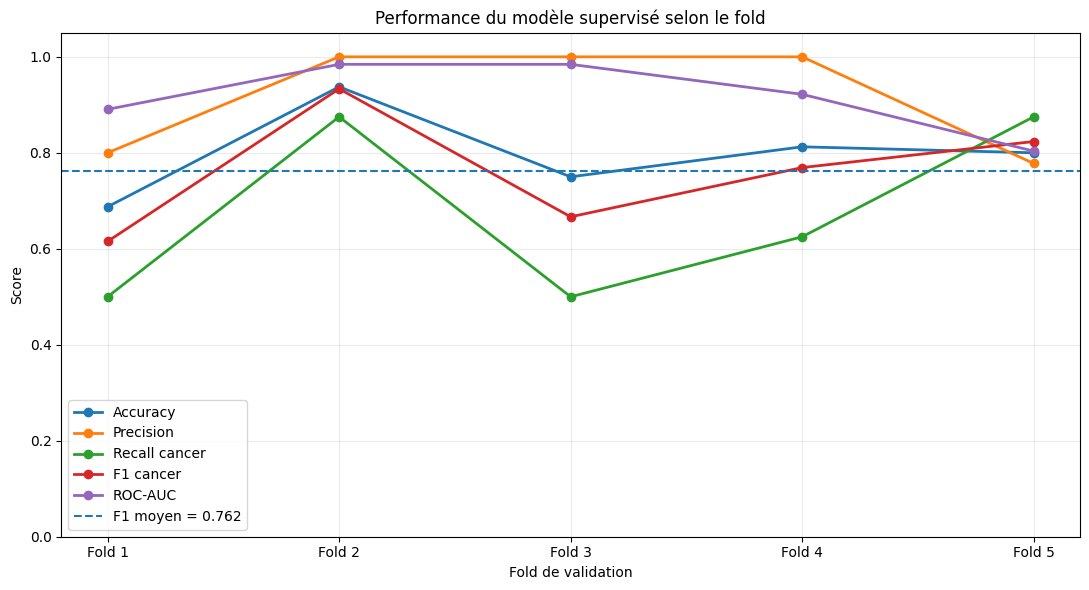

In [66]:
# ============================================================
# 4.4.31 — Visualisation des performances par fold
# ============================================================

import matplotlib.pyplot as plt

metrics_labels = {
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall cancer",
    "f1": "F1 cancer",
    "roc_auc": "ROC-AUC"
}

plt.figure(figsize=(11, 6))

for metric, label in metrics_labels.items():
    plt.plot(
        cv_results_df["fold"],
        cv_results_df[metric],
        marker="o",
        linewidth=2,
        label=label
    )

plt.axhline(
    cv_mean["f1"],
    linestyle="--",
    linewidth=1.5,
    label=f"F1 moyen = {cv_mean['f1']:.3f}"
)

plt.ylim(0, 1.05)
plt.xlabel("Fold de validation")
plt.ylabel("Score")
plt.title("Performance du modèle supervisé selon le fold")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

plt.show()

In [67]:
# ============================================================
# 4.5.1 — Configuration de l'expérience semi-supervisée
# ============================================================

print("=" * 70)
print("4.5.1 — Configuration de l'expérience semi-supervisée")
print("=" * 70)

# ------------------------------------------------------------
# Données utilisées
# ------------------------------------------------------------

SEMI_WEAK_SIZE = len(weak_high_confidence_df)
SEMI_STRONG_CV_SIZE = len(strong_train_df)
SEMI_FINAL_TEST_SIZE = len(strong_test_df)

# ------------------------------------------------------------
# Configuration initiale
# ------------------------------------------------------------

SEMI_WEAK_EPOCHS = 5
SEMI_STRONG_EPOCHS = 5

SEMI_LEARNING_RATE = 1e-3

# ------------------------------------------------------------
# Validation croisée
# ------------------------------------------------------------

N_CV_FOLDS = len(folds)

# Historique des résultats
semi_cv_results = []

# ------------------------------------------------------------
# Affichage
# ------------------------------------------------------------

print("\nDonnées utilisées :")
print(f"Labels faibles haute confiance : {SEMI_WEAK_SIZE}")
print(f"Labels forts pour la CV         : {SEMI_STRONG_CV_SIZE}")
print(f"Test final isolé                : {SEMI_FINAL_TEST_SIZE}")

print("\nConfiguration initiale :")
print(f"Époques phase faible            : {SEMI_WEAK_EPOCHS}")
print(f"Époques fine-tuning fort        : {SEMI_STRONG_EPOCHS}")
print(f"Learning rate                   : {SEMI_LEARNING_RATE}")
print(f"Nombre de folds                 : {N_CV_FOLDS}")

# ------------------------------------------------------------
# Vérifications méthodologiques
# ------------------------------------------------------------

assert SEMI_WEAK_SIZE == 1295
assert SEMI_STRONG_CV_SIZE == 79
assert SEMI_FINAL_TEST_SIZE == 20

assert SEMI_WEAK_EPOCHS > 0
assert SEMI_STRONG_EPOCHS > 0
assert SEMI_LEARNING_RATE > 0

assert N_CV_FOLDS == 5

# Le test final ne doit appartenir ni au train CV ni au weak set.
assert set(strong_test_df["path"]).isdisjoint(
    set(strong_train_df["path"])
)

assert set(strong_test_df["path"]).isdisjoint(
    set(weak_high_confidence_df["path"])
)

print("\n✓ 1 295 pseudo-labels haute confiance sélectionnés.")
print("✓ 79 labels forts réservés à la validation croisée.")
print("✓ 20 labels forts isolés pour le test final.")
print("✓ Aucun chevauchement détecté.")
print("✓ Configuration semi-supervisée prête.")

4.5.1 — Configuration de l'expérience semi-supervisée

Données utilisées :
Labels faibles haute confiance : 1295
Labels forts pour la CV         : 79
Test final isolé                : 20

Configuration initiale :
Époques phase faible            : 5
Époques fine-tuning fort        : 5
Learning rate                   : 0.001
Nombre de folds                 : 5

✓ 1 295 pseudo-labels haute confiance sélectionnés.
✓ 79 labels forts réservés à la validation croisée.
✓ 20 labels forts isolés pour le test final.
✓ Aucun chevauchement détecté.
✓ Configuration semi-supervisée prête.


In [69]:
# ============================================================
# 4.5.2 — Préparation du Fold 1 semi-supervisé
# ============================================================

print("=" * 70)
print("4.5.2 — Préparation du Fold 1 semi-supervisé")
print("=" * 70)

# ------------------------------------------------------------
# Sélection du Fold 1
# ------------------------------------------------------------

fold_id = 0

fold_train_indices = folds[fold_id]["train_indices"]
fold_val_indices = folds[fold_id]["val_indices"]

# Données fortes du Fold 1
fold_strong_train_df = embeddings_df.loc[
    fold_train_indices,
    ["filename", "path", "md5", "label"]
].copy()

fold_strong_val_df = embeddings_df.loc[
    fold_val_indices,
    ["filename", "path", "md5", "label"]
].copy()

# ------------------------------------------------------------
# Vérification des volumes
# ------------------------------------------------------------

print("\nDonnées fortes du Fold 1 :")
print(f"Train fort : {len(fold_strong_train_df)}")
print(f"Validation : {len(fold_strong_val_df)}")

print("\nRépartition du train fort :")
print(fold_strong_train_df["label"].value_counts())

print("\nRépartition de la validation :")
print(fold_strong_val_df["label"].value_counts())

print("\nDonnées faibles :")
print(f"Pseudo-labels haute confiance : {len(weak_high_confidence_df)}")
print(weak_high_confidence_df["weak_label"].value_counts())

# ------------------------------------------------------------
# Création des datasets
# ------------------------------------------------------------

fold_strong_train_dataset = BrainScanDataset(
    dataframe=fold_strong_train_df,
    label_column="label",
    transform=image_transform
)

fold_strong_val_dataset = BrainScanDataset(
    dataframe=fold_strong_val_df,
    label_column="label",
    transform=image_transform
)

fold_weak_dataset = BrainScanDataset(
    dataframe=weak_high_confidence_df,
    label_column="weak_label",
    transform=image_transform
)

# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------

fold_strong_train_loader = DataLoader(
    fold_strong_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

fold_strong_val_loader = DataLoader(
    fold_strong_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

fold_weak_loader = DataLoader(
    fold_weak_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

# ------------------------------------------------------------
# Vérifications anti-fuite
# ------------------------------------------------------------

assert len(fold_strong_train_df) + len(fold_strong_val_df) == 79

assert set(fold_strong_train_df["path"]).isdisjoint(
    set(fold_strong_val_df["path"])
)

assert set(fold_strong_train_df["path"]).isdisjoint(
    set(weak_high_confidence_df["path"])
)

assert set(fold_strong_val_df["path"]).isdisjoint(
    set(weak_high_confidence_df["path"])
)

assert set(fold_strong_train_df["path"]).isdisjoint(
    set(strong_test_df["path"])
)

assert set(fold_strong_val_df["path"]).isdisjoint(
    set(strong_test_df["path"])
)

# Vérification du périphérique de calcul
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"\nPériphérique utilisé : {device}")

# ------------------------------------------------------------
# Initialisation d'un nouveau ResNet50
# ------------------------------------------------------------

semi_model = resnet50(weights=weights)

num_features = semi_model.fc.in_features

semi_model.fc = nn.Linear(
    num_features,
    2
)

# Backbone gelé pour cette première expérience
for parameter in semi_model.parameters():
    parameter.requires_grad = False

for parameter in semi_model.fc.parameters():
    parameter.requires_grad = True

semi_model = semi_model.to(device)

# ------------------------------------------------------------
# Fonction de coût et optimiseur
# ------------------------------------------------------------

criterion_semi = nn.CrossEntropyLoss()

optimizer_semi = torch.optim.Adam(
    semi_model.fc.parameters(),
    lr=SEMI_LEARNING_RATE
)

# ------------------------------------------------------------
# Vérification finale
# ------------------------------------------------------------

trainable_parameters = sum(
    parameter.numel()
    for parameter in semi_model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in semi_model.parameters()
)

print("\nModèle semi-supervisé :")
print(f"Paramètres totaux     : {total_parameters:,}")
print(f"Paramètres entraînés  : {trainable_parameters:,}")

print("\nDataLoaders :")
print(f"Weak       : {len(fold_weak_loader)} batchs")
print(f"Train fort : {len(fold_strong_train_loader)} batchs")
print(f"Validation : {len(fold_strong_val_loader)} batchs")

print("\n✓ Fold 1 prêt.")
print("✓ Les données de validation restent séparées du train.")
print("✓ Le test final de 20 images reste isolé.")
print("✓ Modèle ResNet50 initialisé avec backbone gelé.")

4.5.2 — Préparation du Fold 1 semi-supervisé

Données fortes du Fold 1 :
Train fort : 63
Validation : 16

Répartition du train fort :
label
cancer    32
normal    31
Name: count, dtype: int64

Répartition de la validation :
label
normal    8
cancer    8
Name: count, dtype: int64

Données faibles :
Pseudo-labels haute confiance : 1295
weak_label
normal    819
cancer    476
Name: count, dtype: int64

Périphérique utilisé : cuda

Modèle semi-supervisé :
Paramètres totaux     : 23,512,130
Paramètres entraînés  : 4,098

DataLoaders :
Weak       : 41 batchs
Train fort : 2 batchs
Validation : 1 batchs

✓ Fold 1 prêt.
✓ Les données de validation restent séparées du train.
✓ Le test final de 20 images reste isolé.
✓ Modèle ResNet50 initialisé avec backbone gelé.


In [70]:
# ============================================================
# 4.5.3 — Entraînement sur les pseudo-labels avec validation
# ============================================================

print("=" * 70)
print("4.5.3 — Phase faible : entraînement sur les pseudo-labels")
print("=" * 70)

weak_train_losses = []
weak_val_metrics = []

best_weak_f1 = -np.inf
best_weak_epoch = None
best_weak_state_dict = None

for epoch in range(SEMI_WEAK_EPOCHS):

    # --------------------------------------------------------
    # Entraînement sur les 1 295 pseudo-labels
    # --------------------------------------------------------

    train_loss = train_one_epoch(
        model=semi_model,
        dataloader=fold_weak_loader,
        criterion=criterion_semi,
        optimizer=optimizer_semi,
        device=device
    )

    # --------------------------------------------------------
    # Évaluation sur les 16 labels forts de validation
    # --------------------------------------------------------

    val_metrics = evaluate_model(
        model=semi_model,
        dataloader=fold_strong_val_loader,
        device=device
    )

    weak_train_losses.append(train_loss)
    weak_val_metrics.append(val_metrics)

    # --------------------------------------------------------
    # Sélection du meilleur modèle selon le F1 cancer
    # --------------------------------------------------------

    current_f1 = val_metrics["f1"]

    if current_f1 > best_weak_f1:
        best_weak_f1 = current_f1
        best_weak_epoch = epoch + 1
        best_weak_state_dict = {
            key: value.detach().cpu().clone()
            for key, value in semi_model.state_dict().items()
        }

    print(
        f"Époque {epoch + 1:02d}/{SEMI_WEAK_EPOCHS} | "
        f"Loss train : {train_loss:.4f} | "
        f"Val Accuracy : {val_metrics['accuracy']:.4f} | "
        f"Val F1 cancer : {val_metrics['f1']:.4f} | "
        f"Val ROC-AUC : {val_metrics['roc_auc']:.4f}"
    )

# ------------------------------------------------------------
# Restauration du meilleur état observé sur la validation
# ------------------------------------------------------------

semi_model.load_state_dict(best_weak_state_dict)

print("\n" + "-" * 70)
print("Résultat de la phase faible")
print("-" * 70)

print(f"Meilleure époque : {best_weak_epoch}")
print(f"Meilleur F1 validation : {best_weak_f1:.4f}")

best_weak_val_metrics = weak_val_metrics[best_weak_epoch - 1]

print(f"Accuracy validation : {best_weak_val_metrics['accuracy']:.4f}")
print(f"Precision validation : {best_weak_val_metrics['precision']:.4f}")
print(f"Recall cancer : {best_weak_val_metrics['recall']:.4f}")
print(f"F1 cancer : {best_weak_val_metrics['f1']:.4f}")
print(f"ROC-AUC : {best_weak_val_metrics['roc_auc']:.4f}")

print("\n✓ Phase faible terminée.")
print("✓ Le meilleur modèle selon le F1 cancer a été conservé.")
print("✓ Les 16 images de validation n'ont pas été utilisées pour l'entraînement.")

4.5.3 — Phase faible : entraînement sur les pseudo-labels
Époque 01/5 | Loss train : 0.5268 | Val Accuracy : 0.7500 | Val F1 cancer : 0.6667 | Val ROC-AUC : 0.8750
Époque 02/5 | Loss train : 0.4079 | Val Accuracy : 0.7500 | Val F1 cancer : 0.6667 | Val ROC-AUC : 0.9219
Époque 03/5 | Loss train : 0.3833 | Val Accuracy : 0.7500 | Val F1 cancer : 0.6667 | Val ROC-AUC : 0.9062
Époque 04/5 | Loss train : 0.3633 | Val Accuracy : 0.7500 | Val F1 cancer : 0.6667 | Val ROC-AUC : 0.9531
Époque 05/5 | Loss train : 0.3397 | Val Accuracy : 0.7500 | Val F1 cancer : 0.6667 | Val ROC-AUC : 0.9844

----------------------------------------------------------------------
Résultat de la phase faible
----------------------------------------------------------------------
Meilleure époque : 1
Meilleur F1 validation : 0.6667
Accuracy validation : 0.7500
Precision validation : 1.0000
Recall cancer : 0.5000
F1 cancer : 0.6667
ROC-AUC : 0.8750

✓ Phase faible terminée.
✓ Le meilleur modèle selon le F1 cancer a ét

In [71]:
# ============================================================
# 4.5.4 — Fine-tuning sur les labels forts du Fold 1
# ============================================================

print("=" * 70)
print("4.5.4 — Phase forte : fine-tuning sur les labels forts")
print("=" * 70)

strong_train_losses = []
strong_val_metrics = []

best_strong_f1 = -np.inf
best_strong_epoch = None
best_strong_state_dict = None

for epoch in range(SEMI_STRONG_EPOCHS):

    # --------------------------------------------------------
    # Entraînement sur les 63 labels forts du Fold 1
    # --------------------------------------------------------

    train_loss = train_one_epoch(
        model=semi_model,
        dataloader=fold_strong_train_loader,
        criterion=criterion_semi,
        optimizer=optimizer_semi,
        device=device
    )

    # --------------------------------------------------------
    # Évaluation sur les 16 images de validation
    # --------------------------------------------------------

    val_metrics = evaluate_model(
        model=semi_model,
        dataloader=fold_strong_val_loader,
        device=device
    )

    strong_train_losses.append(train_loss)
    strong_val_metrics.append(val_metrics)

    # --------------------------------------------------------
    # Sélection du meilleur modèle selon le F1 cancer
    # --------------------------------------------------------

    current_f1 = val_metrics["f1"]

    if current_f1 > best_strong_f1:
        best_strong_f1 = current_f1
        best_strong_epoch = epoch + 1
        best_strong_state_dict = {
            key: value.detach().cpu().clone()
            for key, value in semi_model.state_dict().items()
        }

    print(
        f"Époque {epoch + 1:02d}/{SEMI_STRONG_EPOCHS} | "
        f"Loss train : {train_loss:.4f} | "
        f"Val Accuracy : {val_metrics['accuracy']:.4f} | "
        f"Val F1 cancer : {val_metrics['f1']:.4f} | "
        f"Val ROC-AUC : {val_metrics['roc_auc']:.4f}"
    )

# ------------------------------------------------------------
# Restauration du meilleur état observé sur la validation
# ------------------------------------------------------------

semi_model.load_state_dict(best_strong_state_dict)

print("\n" + "-" * 70)
print("Résultat du fine-tuning fort")
print("-" * 70)

print(f"Meilleure époque : {best_strong_epoch}")
print(f"Meilleur F1 validation : {best_strong_f1:.4f}")

best_strong_val_metrics = strong_val_metrics[best_strong_epoch - 1]

print(f"Accuracy validation : {best_strong_val_metrics['accuracy']:.4f}")
print(f"Precision validation : {best_strong_val_metrics['precision']:.4f}")
print(f"Recall cancer : {best_strong_val_metrics['recall']:.4f}")
print(f"F1 cancer : {best_strong_val_metrics['f1']:.4f}")
print(f"ROC-AUC : {best_strong_val_metrics['roc_auc']:.4f}")

print("\n✓ Fine-tuning fort terminé.")
print("✓ Le même modèle a été conservé après la phase faible.")
print("✓ Le meilleur état selon le F1 cancer a été conservé.")
print("✓ Les 16 images de validation restent indépendantes de l'entraînement.")
print("✓ Les 20 images du test final restent totalement isolées.")

4.5.4 — Phase forte : fine-tuning sur les labels forts
Époque 01/5 | Loss train : 0.4442 | Val Accuracy : 0.7500 | Val F1 cancer : 0.6667 | Val ROC-AUC : 0.8750
Époque 02/5 | Loss train : 0.4341 | Val Accuracy : 0.7500 | Val F1 cancer : 0.6667 | Val ROC-AUC : 0.8906
Époque 03/5 | Loss train : 0.4315 | Val Accuracy : 0.7500 | Val F1 cancer : 0.6667 | Val ROC-AUC : 0.9062
Époque 04/5 | Loss train : 0.3576 | Val Accuracy : 0.7500 | Val F1 cancer : 0.6667 | Val ROC-AUC : 0.9375
Époque 05/5 | Loss train : 0.3676 | Val Accuracy : 0.8125 | Val F1 cancer : 0.7692 | Val ROC-AUC : 0.9531

----------------------------------------------------------------------
Résultat du fine-tuning fort
----------------------------------------------------------------------
Meilleure époque : 5
Meilleur F1 validation : 0.7692
Accuracy validation : 0.8125
Precision validation : 1.0000
Recall cancer : 0.6250
F1 cancer : 0.7692
ROC-AUC : 0.9531

✓ Fine-tuning fort terminé.
✓ Le même modèle a été conservé après la ph

In [72]:
# ============================================================
# 4.5.5 — Enregistrement des résultats du Fold 1
# ============================================================

print("=" * 70)
print("4.5.5 — Résultats du Fold 1 semi-supervisé")
print("=" * 70)

# ------------------------------------------------------------
# Résultats du meilleur modèle du Fold 1
# ------------------------------------------------------------

fold_1_semi_result = {
    "fold": 1,
    "weak_epochs": SEMI_WEAK_EPOCHS,
    "strong_epochs": SEMI_STRONG_EPOCHS,
    "learning_rate": SEMI_LEARNING_RATE,
    "weak_samples": SEMI_WEAK_SIZE,
    "strong_train_samples": len(fold_strong_train_df),
    "validation_samples": len(fold_strong_val_df),
    "best_weak_epoch": best_weak_epoch,
    "best_weak_f1": best_weak_f1,
    "best_strong_epoch": best_strong_epoch,
    "accuracy": best_strong_val_metrics["accuracy"],
    "precision": best_strong_val_metrics["precision"],
    "recall": best_strong_val_metrics["recall"],
    "f1": best_strong_val_metrics["f1"],
    "roc_auc": best_strong_val_metrics["roc_auc"],
    "confusion_matrix": best_strong_val_metrics["confusion_matrix"].tolist()
}

# ------------------------------------------------------------
# Stockage dans la liste globale
# ------------------------------------------------------------

semi_cv_results = [fold_1_semi_result]

# ------------------------------------------------------------
# Affichage
# ------------------------------------------------------------

semi_fold_results_df = pd.DataFrame(semi_cv_results)

display(semi_fold_results_df)

print("\nRésumé du Fold 1 :")
print(
    f"Accuracy : {fold_1_semi_result['accuracy']:.4f}"
)
print(
    f"Precision : {fold_1_semi_result['precision']:.4f}"
)
print(
    f"Recall cancer : {fold_1_semi_result['recall']:.4f}"
)
print(
    f"F1 cancer : {fold_1_semi_result['f1']:.4f}"
)
print(
    f"ROC-AUC : {fold_1_semi_result['roc_auc']:.4f}"
)

print(
    f"\nMatrice de confusion : "
    f"{fold_1_semi_result['confusion_matrix']}"
)

# ------------------------------------------------------------
# Vérifications
# ------------------------------------------------------------

assert len(semi_cv_results) == 1
assert semi_cv_results[0]["fold"] == 1
assert semi_cv_results[0]["f1"] == best_strong_val_metrics["f1"]

print("\n✓ Résultats du Fold 1 enregistrés.")
print("✓ Les résultats pourront être comparés aux quatre autres folds.")
print("✓ Aucun résultat du test final n'a été utilisé.")

4.5.5 — Résultats du Fold 1 semi-supervisé


,fold,weak_epochs,strong_epochs,learning_rate,weak_samples,strong_train_samples,validation_samples,best_weak_epoch,best_weak_f1,best_strong_epoch,accuracy,precision,recall,f1,roc_auc,confusion_matrix
0,1,5,5,0.001,1295,63,16,1,0.666667,5,0.8125,1.0,0.625,0.769231,0.953125,"[[8, 0], [3, 5]]"



Résumé du Fold 1 :
Accuracy : 0.8125
Precision : 1.0000
Recall cancer : 0.6250
F1 cancer : 0.7692
ROC-AUC : 0.9531

Matrice de confusion : [[8, 0], [3, 5]]

✓ Résultats du Fold 1 enregistrés.
✓ Les résultats pourront être comparés aux quatre autres folds.
✓ Aucun résultat du test final n'a été utilisé.


In [73]:
# ============================================================
# 4.5.6 — Préparation du Fold 2 semi-supervisé
# ============================================================

print("=" * 70)
print("4.5.6 — Préparation du Fold 2 semi-supervisé")
print("=" * 70)

# ------------------------------------------------------------
# Sélection du Fold 2
# ------------------------------------------------------------

fold_id = 1

fold_train_indices = folds[fold_id]["train_indices"]
fold_val_indices = folds[fold_id]["val_indices"]

fold_strong_train_df = embeddings_df.loc[
    fold_train_indices,
    ["filename", "path", "md5", "label"]
].copy()

fold_strong_val_df = embeddings_df.loc[
    fold_val_indices,
    ["filename", "path", "md5", "label"]
].copy()

print("\nDonnées fortes du Fold 2 :")
print(f"Train fort : {len(fold_strong_train_df)}")
print(f"Validation : {len(fold_strong_val_df)}")

print("\nRépartition du train fort :")
print(fold_strong_train_df["label"].value_counts())

print("\nRépartition de la validation :")
print(fold_strong_val_df["label"].value_counts())

print("\nDonnées faibles :")
print(f"Pseudo-labels haute confiance : {len(weak_high_confidence_df)}")
print(weak_high_confidence_df["weak_label"].value_counts())


# ------------------------------------------------------------
# Création des datasets
# ------------------------------------------------------------

fold_strong_train_dataset = BrainScanDataset(
    dataframe=fold_strong_train_df,
    label_column="label",
    transform=image_transform
)

fold_strong_val_dataset = BrainScanDataset(
    dataframe=fold_strong_val_df,
    label_column="label",
    transform=image_transform
)

fold_weak_dataset = BrainScanDataset(
    dataframe=weak_high_confidence_df,
    label_column="weak_label",
    transform=image_transform
)


# ------------------------------------------------------------
# Création des DataLoaders
# ------------------------------------------------------------

fold_strong_train_loader = DataLoader(
    fold_strong_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

fold_strong_val_loader = DataLoader(
    fold_strong_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

fold_weak_loader = DataLoader(
    fold_weak_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)


# ------------------------------------------------------------
# Vérification de l'absence de fuite de données
# ------------------------------------------------------------

assert len(fold_strong_train_df) + len(fold_strong_val_df) == 79

assert set(fold_strong_train_df["path"]).isdisjoint(
    set(fold_strong_val_df["path"])
)

assert set(fold_strong_train_df["path"]).isdisjoint(
    set(weak_high_confidence_df["path"])
)

assert set(fold_strong_val_df["path"]).isdisjoint(
    set(weak_high_confidence_df["path"])
)

assert set(fold_strong_train_df["path"]).isdisjoint(
    set(strong_test_df["path"])
)

assert set(fold_strong_val_df["path"]).isdisjoint(
    set(strong_test_df["path"])
)


# ------------------------------------------------------------
# Nouveau modèle indépendant pour le Fold 2
# ------------------------------------------------------------

semi_model = resnet50(weights=weights)

num_features = semi_model.fc.in_features
semi_model.fc = nn.Linear(num_features, 2)

# Backbone gelé : seule la tête de classification est entraînée
for parameter in semi_model.parameters():
    parameter.requires_grad = False

for parameter in semi_model.fc.parameters():
    parameter.requires_grad = True


# ------------------------------------------------------------
# Configuration de l'entraînement
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"\nPériphérique utilisé : {device}")

semi_model = semi_model.to(device)

criterion_semi = nn.CrossEntropyLoss()

optimizer_semi = torch.optim.Adam(
    semi_model.fc.parameters(),
    lr=SEMI_LEARNING_RATE
)


# ------------------------------------------------------------
# Vérification du nombre de paramètres entraînables
# ------------------------------------------------------------

trainable_parameters = sum(
    parameter.numel()
    for parameter in semi_model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in semi_model.parameters()
)

print("\nModèle semi-supervisé :")
print(f"Paramètres totaux     : {total_parameters:,}")
print(f"Paramètres entraînés  : {trainable_parameters:,}")

print("\nDataLoaders :")
print(f"Weak       : {len(fold_weak_loader)} batchs")
print(f"Train fort : {len(fold_strong_train_loader)} batchs")
print(f"Validation : {len(fold_strong_val_loader)} batchs")


# ------------------------------------------------------------
# Validation finale de la préparation du Fold 2
# ------------------------------------------------------------

assert len(fold_strong_train_df) == 63
assert len(fold_strong_val_df) == 16
assert len(weak_high_confidence_df) == 1295

assert trainable_parameters > 0
assert trainable_parameters < total_parameters

print("\n✓ Fold 2 prêt.")
print("✓ Nouveau modèle indépendant du Fold 1.")
print("✓ Les données de validation restent séparées du train.")
print("✓ Les pseudo-labels haute confiance sont disponibles.")
print("✓ Le test final de 20 images reste totalement isolé.")
print("✓ Backbone ResNet50 gelé ; seule la tête est entraînée.")

4.5.6 — Préparation du Fold 2 semi-supervisé

Données fortes du Fold 2 :
Train fort : 63
Validation : 16

Répartition du train fort :
label
cancer    32
normal    31
Name: count, dtype: int64

Répartition de la validation :
label
cancer    8
normal    8
Name: count, dtype: int64

Données faibles :
Pseudo-labels haute confiance : 1295
weak_label
normal    819
cancer    476
Name: count, dtype: int64

Périphérique utilisé : cuda

Modèle semi-supervisé :
Paramètres totaux     : 23,512,130
Paramètres entraînés  : 4,098

DataLoaders :
Weak       : 41 batchs
Train fort : 2 batchs
Validation : 1 batchs

✓ Fold 2 prêt.
✓ Nouveau modèle indépendant du Fold 1.
✓ Les données de validation restent séparées du train.
✓ Les pseudo-labels haute confiance sont disponibles.
✓ Le test final de 20 images reste totalement isolé.
✓ Backbone ResNet50 gelé ; seule la tête est entraînée.


In [74]:
# ============================================================
# 4.5.7 — Phase faible : entraînement sur les pseudo-labels
# ============================================================

print("=" * 70)
print("4.5.7 — Phase faible : entraînement sur les pseudo-labels")
print("=" * 70)

weak_train_losses = []
weak_val_metrics = []

best_weak_f1 = -np.inf
best_weak_epoch = None
best_weak_state_dict = None

for epoch in range(SEMI_WEAK_EPOCHS):

    train_loss = train_one_epoch(
        model=semi_model,
        dataloader=fold_weak_loader,
        criterion=criterion_semi,
        optimizer=optimizer_semi,
        device=device
    )

    val_metrics = evaluate_model(
        model=semi_model,
        dataloader=fold_strong_val_loader,
        device=device
    )

    weak_train_losses.append(train_loss)
    weak_val_metrics.append(val_metrics)

    current_f1 = val_metrics["f1"]

    if current_f1 > best_weak_f1:
        best_weak_f1 = current_f1
        best_weak_epoch = epoch + 1
        best_weak_state_dict = {
            key: value.detach().cpu().clone()
            for key, value in semi_model.state_dict().items()
        }

    print(
        f"Époque {epoch + 1:02d}/{SEMI_WEAK_EPOCHS} | "
        f"Loss train : {train_loss:.4f} | "
        f"Val Accuracy : {val_metrics['accuracy']:.4f} | "
        f"Val F1 cancer : {val_metrics['f1']:.4f} | "
        f"Val ROC-AUC : {val_metrics['roc_auc']:.4f}"
    )

# Restaurer le meilleur état de la phase faible
semi_model.load_state_dict(best_weak_state_dict)

print("\n" + "-" * 70)
print("Résultat de la phase faible — Fold 2")
print("-" * 70)

print(f"Meilleure époque : {best_weak_epoch}")
print(f"Meilleur F1 validation : {best_weak_f1:.4f}")

best_weak_val_metrics = weak_val_metrics[best_weak_epoch - 1]

print(f"Accuracy validation : {best_weak_val_metrics['accuracy']:.4f}")
print(f"Precision validation : {best_weak_val_metrics['precision']:.4f}")
print(f"Recall cancer : {best_weak_val_metrics['recall']:.4f}")
print(f"F1 cancer : {best_weak_val_metrics['f1']:.4f}")
print(f"ROC-AUC : {best_weak_val_metrics['roc_auc']:.4f}")

print("\n✓ Phase faible du Fold 2 terminée.")
print("✓ Le meilleur modèle selon le F1 cancer a été conservé.")
print("✓ Les 16 images de validation restent indépendantes.")

4.5.7 — Phase faible : entraînement sur les pseudo-labels
Époque 01/5 | Loss train : 0.5335 | Val Accuracy : 0.6875 | Val F1 cancer : 0.5455 | Val ROC-AUC : 0.8906
Époque 02/5 | Loss train : 0.4156 | Val Accuracy : 0.7500 | Val F1 cancer : 0.6667 | Val ROC-AUC : 0.9531
Époque 03/5 | Loss train : 0.3818 | Val Accuracy : 0.8750 | Val F1 cancer : 0.8571 | Val ROC-AUC : 0.9688
Époque 04/5 | Loss train : 0.3679 | Val Accuracy : 0.8125 | Val F1 cancer : 0.7692 | Val ROC-AUC : 0.9688
Époque 05/5 | Loss train : 0.3491 | Val Accuracy : 0.8125 | Val F1 cancer : 0.7692 | Val ROC-AUC : 0.9688

----------------------------------------------------------------------
Résultat de la phase faible — Fold 2
----------------------------------------------------------------------
Meilleure époque : 3
Meilleur F1 validation : 0.8571
Accuracy validation : 0.8750
Precision validation : 1.0000
Recall cancer : 0.7500
F1 cancer : 0.8571
ROC-AUC : 0.9688

✓ Phase faible du Fold 2 terminée.
✓ Le meilleur modèle selo

In [75]:
# ============================================================
# 4.5.8 — Phase forte : fine-tuning sur les labels forts
# ============================================================

print("=" * 70)
print("4.5.8 — Phase forte : fine-tuning sur les labels forts")
print("=" * 70)

strong_train_losses = []
strong_val_metrics = []

best_strong_f1 = -np.inf
best_strong_epoch = None
best_strong_state_dict = None

for epoch in range(SEMI_STRONG_EPOCHS):

    train_loss = train_one_epoch(
        model=semi_model,
        dataloader=fold_strong_train_loader,
        criterion=criterion_semi,
        optimizer=optimizer_semi,
        device=device
    )

    val_metrics = evaluate_model(
        model=semi_model,
        dataloader=fold_strong_val_loader,
        device=device
    )

    strong_train_losses.append(train_loss)
    strong_val_metrics.append(val_metrics)

    current_f1 = val_metrics["f1"]

    if current_f1 > best_strong_f1:
        best_strong_f1 = current_f1
        best_strong_epoch = epoch + 1
        best_strong_state_dict = {
            key: value.detach().cpu().clone()
            for key, value in semi_model.state_dict().items()
        }

    print(
        f"Époque {epoch + 1:02d}/{SEMI_STRONG_EPOCHS} | "
        f"Loss train : {train_loss:.4f} | "
        f"Val Accuracy : {val_metrics['accuracy']:.4f} | "
        f"Val F1 cancer : {val_metrics['f1']:.4f} | "
        f"Val ROC-AUC : {val_metrics['roc_auc']:.4f}"
    )

# Restaurer le meilleur état de la phase forte
semi_model.load_state_dict(best_strong_state_dict)

print("\n" + "-" * 70)
print("Résultat du fine-tuning fort — Fold 2")
print("-" * 70)

print(f"Meilleure époque : {best_strong_epoch}")
print(f"Meilleur F1 validation : {best_strong_f1:.4f}")

best_strong_val_metrics = strong_val_metrics[best_strong_epoch - 1]

print(f"Accuracy validation : {best_strong_val_metrics['accuracy']:.4f}")
print(f"Precision validation : {best_strong_val_metrics['precision']:.4f}")
print(f"Recall cancer : {best_strong_val_metrics['recall']:.4f}")
print(f"F1 cancer : {best_strong_val_metrics['f1']:.4f}")
print(f"ROC-AUC : {best_strong_val_metrics['roc_auc']:.4f}")

print("\n" + "=" * 70)
print("✓ Fine-tuning fort du Fold 2 terminé.")
print("✓ Le même modèle a été conservé après la phase faible.")
print("✓ Le meilleur état selon le F1 cancer a été conservé.")
print("✓ La validation reste indépendante de l'entraînement.")
print("=" * 70)

4.5.8 — Phase forte : fine-tuning sur les labels forts
Époque 01/5 | Loss train : 0.4112 | Val Accuracy : 0.8125 | Val F1 cancer : 0.8000 | Val ROC-AUC : 0.9688
Époque 02/5 | Loss train : 0.3924 | Val Accuracy : 0.8125 | Val F1 cancer : 0.8000 | Val ROC-AUC : 0.9531
Époque 03/5 | Loss train : 0.3858 | Val Accuracy : 0.8125 | Val F1 cancer : 0.8000 | Val ROC-AUC : 0.9531
Époque 04/5 | Loss train : 0.4192 | Val Accuracy : 0.8125 | Val F1 cancer : 0.8000 | Val ROC-AUC : 0.9531
Époque 05/5 | Loss train : 0.3451 | Val Accuracy : 0.8750 | Val F1 cancer : 0.8750 | Val ROC-AUC : 0.9531

----------------------------------------------------------------------
Résultat du fine-tuning fort — Fold 2
----------------------------------------------------------------------
Meilleure époque : 5
Meilleur F1 validation : 0.8750
Accuracy validation : 0.8750
Precision validation : 0.8750
Recall cancer : 0.8750
F1 cancer : 0.8750
ROC-AUC : 0.9531

✓ Fine-tuning fort du Fold 2 terminé.
✓ Le même modèle a été c

In [76]:
# ============================================================
# 4.5.9 — Enregistrement des résultats du Fold 2
# ============================================================

print("=" * 70)
print("4.5.9 — Résultats du Fold 2 semi-supervisé")
print("=" * 70)

fold_2_semi_result = {
    "fold": 2,
    "weak_epochs": SEMI_WEAK_EPOCHS,
    "strong_epochs": SEMI_STRONG_EPOCHS,
    "learning_rate": SEMI_LEARNING_RATE,
    "weak_samples": SEMI_WEAK_SIZE,
    "strong_train_samples": len(fold_strong_train_df),
    "validation_samples": len(fold_strong_val_df),
    "best_weak_epoch": best_weak_epoch,
    "best_weak_f1": best_weak_f1,
    "best_strong_epoch": best_strong_epoch,
    "accuracy": best_strong_val_metrics["accuracy"],
    "precision": best_strong_val_metrics["precision"],
    "recall": best_strong_val_metrics["recall"],
    "f1": best_strong_val_metrics["f1"],
    "roc_auc": best_strong_val_metrics["roc_auc"],
    "confusion_matrix": best_strong_val_metrics["confusion_matrix"].tolist()
}

# Ajouter le Fold 2 sans supprimer le Fold 1
semi_cv_results.append(fold_2_semi_result)

semi_fold_results_df = pd.DataFrame(semi_cv_results)

display(semi_fold_results_df)

print("\nRésumé du Fold 2 :")
print(f"Accuracy : {fold_2_semi_result['accuracy']:.4f}")
print(f"Precision : {fold_2_semi_result['precision']:.4f}")
print(f"Recall cancer : {fold_2_semi_result['recall']:.4f}")
print(f"F1 cancer : {fold_2_semi_result['f1']:.4f}")
print(f"ROC-AUC : {fold_2_semi_result['roc_auc']:.4f}")

print(
    f"\nMatrice de confusion : "
    f"{fold_2_semi_result['confusion_matrix']}"
)

# Vérifications
assert len(semi_cv_results) == 2
assert semi_cv_results[0]["fold"] == 1
assert semi_cv_results[1]["fold"] == 2

assert fold_2_semi_result["f1"] == best_strong_val_metrics["f1"]
assert fold_2_semi_result["roc_auc"] == best_strong_val_metrics["roc_auc"]

print("\n✓ Résultats des Folds 1 et 2 enregistrés.")
print("✓ Le Fold 1 a bien été conservé.")
print("✓ Aucun résultat du test final n'a été utilisé.")
print("✓ Les résultats sont prêts pour le Fold 3.")

4.5.9 — Résultats du Fold 2 semi-supervisé


,fold,weak_epochs,strong_epochs,learning_rate,weak_samples,strong_train_samples,validation_samples,best_weak_epoch,best_weak_f1,best_strong_epoch,accuracy,precision,recall,f1,roc_auc,confusion_matrix
0,1,5,5,0.001,1295,63,16,1,0.666667,5,0.8125,1.000,0.625,0.769231,0.953125,"[[8, 0], [3, 5]]"
1,2,5,5,0.001,1295,63,16,3,0.857143,5,0.8750,0.875,0.875,0.875000,0.953125,"[[7, 1], [1, 7]]"



Résumé du Fold 2 :
Accuracy : 0.8750
Precision : 0.8750
Recall cancer : 0.8750
F1 cancer : 0.8750
ROC-AUC : 0.9531

Matrice de confusion : [[7, 1], [1, 7]]

✓ Résultats des Folds 1 et 2 enregistrés.
✓ Le Fold 1 a bien été conservé.
✓ Aucun résultat du test final n'a été utilisé.
✓ Les résultats sont prêts pour le Fold 3.


In [77]:
# ============================================================
# 4.5.10 — Préparation du Fold 3 semi-supervisé
# ============================================================

print("=" * 70)
print("4.5.10 — Préparation du Fold 3 semi-supervisé")
print("=" * 70)

# ------------------------------------------------------------
# Sélection du Fold 3
# ------------------------------------------------------------

fold_id = 2

fold_train_indices = folds[fold_id]["train_indices"]
fold_val_indices = folds[fold_id]["val_indices"]

fold_strong_train_df = embeddings_df.loc[
    fold_train_indices,
    ["filename", "path", "md5", "label"]
].copy()

fold_strong_val_df = embeddings_df.loc[
    fold_val_indices,
    ["filename", "path", "md5", "label"]
].copy()

print("\nDonnées fortes du Fold 3 :")
print(f"Train fort : {len(fold_strong_train_df)}")
print(f"Validation : {len(fold_strong_val_df)}")

print("\nRépartition du train fort :")
print(fold_strong_train_df["label"].value_counts())

print("\nRépartition de la validation :")
print(fold_strong_val_df["label"].value_counts())

print("\nDonnées faibles :")
print(f"Pseudo-labels haute confiance : {len(weak_high_confidence_df)}")
print(weak_high_confidence_df["weak_label"].value_counts())


# ------------------------------------------------------------
# Création des datasets
# ------------------------------------------------------------

fold_strong_train_dataset = BrainScanDataset(
    dataframe=fold_strong_train_df,
    label_column="label",
    transform=image_transform
)

fold_strong_val_dataset = BrainScanDataset(
    dataframe=fold_strong_val_df,
    label_column="label",
    transform=image_transform
)

fold_weak_dataset = BrainScanDataset(
    dataframe=weak_high_confidence_df,
    label_column="weak_label",
    transform=image_transform
)


# ------------------------------------------------------------
# Création des DataLoaders
# ------------------------------------------------------------

fold_strong_train_loader = DataLoader(
    fold_strong_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

fold_strong_val_loader = DataLoader(
    fold_strong_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

fold_weak_loader = DataLoader(
    fold_weak_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)


# ------------------------------------------------------------
# Vérification de l'absence de fuite de données
# ------------------------------------------------------------

assert len(fold_strong_train_df) + len(fold_strong_val_df) == 79

assert set(fold_strong_train_df["path"]).isdisjoint(
    set(fold_strong_val_df["path"])
)

assert set(fold_strong_train_df["path"]).isdisjoint(
    set(weak_high_confidence_df["path"])
)

assert set(fold_strong_val_df["path"]).isdisjoint(
    set(weak_high_confidence_df["path"])
)

assert set(fold_strong_train_df["path"]).isdisjoint(
    set(strong_test_df["path"])
)

assert set(fold_strong_val_df["path"]).isdisjoint(
    set(strong_test_df["path"])
)


# ------------------------------------------------------------
# Nouveau modèle indépendant pour le Fold 3
# ------------------------------------------------------------

semi_model = resnet50(weights=weights)

num_features = semi_model.fc.in_features
semi_model.fc = nn.Linear(num_features, 2)

# Backbone gelé : seule la tête de classification est entraînée
for parameter in semi_model.parameters():
    parameter.requires_grad = False

for parameter in semi_model.fc.parameters():
    parameter.requires_grad = True


# ------------------------------------------------------------
# Configuration de l'entraînement
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"\nPériphérique utilisé : {device}")

semi_model = semi_model.to(device)

criterion_semi = nn.CrossEntropyLoss()

optimizer_semi = torch.optim.Adam(
    semi_model.fc.parameters(),
    lr=SEMI_LEARNING_RATE
)


# ------------------------------------------------------------
# Vérification du nombre de paramètres entraînables
# ------------------------------------------------------------

trainable_parameters = sum(
    parameter.numel()
    for parameter in semi_model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in semi_model.parameters()
)

print("\nModèle semi-supervisé :")
print(f"Paramètres totaux     : {total_parameters:,}")
print(f"Paramètres entraînés  : {trainable_parameters:,}")

print("\nDataLoaders :")
print(f"Weak       : {len(fold_weak_loader)} batchs")
print(f"Train fort : {len(fold_strong_train_loader)} batchs")
print(f"Validation : {len(fold_strong_val_loader)} batchs")


# ------------------------------------------------------------
# Validation finale de la préparation du Fold 3
# ------------------------------------------------------------

assert len(fold_strong_train_df) == 63
assert len(fold_strong_val_df) == 16
assert len(weak_high_confidence_df) == 1295

assert trainable_parameters > 0
assert trainable_parameters < total_parameters

print("\n✓ Fold 3 prêt.")
print("✓ Nouveau modèle indépendant des Folds 1 et 2.")
print("✓ Les données de validation restent séparées du train.")
print("✓ Les pseudo-labels haute confiance sont disponibles.")
print("✓ Le test final de 20 images reste totalement isolé.")
print("✓ Backbone ResNet50 gelé ; seule la tête est entraînée.")

4.5.10 — Préparation du Fold 3 semi-supervisé

Données fortes du Fold 3 :
Train fort : 63
Validation : 16

Répartition du train fort :
label
cancer    32
normal    31
Name: count, dtype: int64

Répartition de la validation :
label
cancer    8
normal    8
Name: count, dtype: int64

Données faibles :
Pseudo-labels haute confiance : 1295
weak_label
normal    819
cancer    476
Name: count, dtype: int64

Périphérique utilisé : cuda

Modèle semi-supervisé :
Paramètres totaux     : 23,512,130
Paramètres entraînés  : 4,098

DataLoaders :
Weak       : 41 batchs
Train fort : 2 batchs
Validation : 1 batchs

✓ Fold 3 prêt.
✓ Nouveau modèle indépendant des Folds 1 et 2.
✓ Les données de validation restent séparées du train.
✓ Les pseudo-labels haute confiance sont disponibles.
✓ Le test final de 20 images reste totalement isolé.
✓ Backbone ResNet50 gelé ; seule la tête est entraînée.


In [78]:
# ============================================================
# 4.5.11 — Phase faible : entraînement sur les pseudo-labels
# ============================================================

print("=" * 70)
print("4.5.11 — Phase faible : entraînement sur les pseudo-labels")
print("=" * 70)

weak_train_losses = []
weak_val_metrics = []

best_weak_f1 = -np.inf
best_weak_epoch = None
best_weak_state_dict = None

for epoch in range(SEMI_WEAK_EPOCHS):

    train_loss = train_one_epoch(
        model=semi_model,
        dataloader=fold_weak_loader,
        criterion=criterion_semi,
        optimizer=optimizer_semi,
        device=device
    )

    val_metrics = evaluate_model(
        model=semi_model,
        dataloader=fold_strong_val_loader,
        device=device
    )

    weak_train_losses.append(train_loss)
    weak_val_metrics.append(val_metrics)

    current_f1 = val_metrics["f1"]

    if current_f1 > best_weak_f1:
        best_weak_f1 = current_f1
        best_weak_epoch = epoch + 1
        best_weak_state_dict = {
            key: value.detach().cpu().clone()
            for key, value in semi_model.state_dict().items()
        }

    print(
        f"Époque {epoch + 1:02d}/{SEMI_WEAK_EPOCHS} | "
        f"Loss train : {train_loss:.4f} | "
        f"Val Accuracy : {val_metrics['accuracy']:.4f} | "
        f"Val F1 cancer : {val_metrics['f1']:.4f} | "
        f"Val ROC-AUC : {val_metrics['roc_auc']:.4f}"
    )

semi_model.load_state_dict(best_weak_state_dict)

print("\n" + "-" * 70)
print("Résultat de la phase faible — Fold 3")
print("-" * 70)

print(f"Meilleure époque : {best_weak_epoch}")
print(f"Meilleur F1 validation : {best_weak_f1:.4f}")

best_weak_val_metrics = weak_val_metrics[best_weak_epoch - 1]

print(f"Accuracy validation : {best_weak_val_metrics['accuracy']:.4f}")
print(f"Precision validation : {best_weak_val_metrics['precision']:.4f}")
print(f"Recall cancer : {best_weak_val_metrics['recall']:.4f}")
print(f"F1 cancer : {best_weak_val_metrics['f1']:.4f}")
print(f"ROC-AUC : {best_weak_val_metrics['roc_auc']:.4f}")

print("\n✓ Phase faible du Fold 3 terminée.")
print("✓ Le meilleur état selon le F1 cancer a été conservé.")
print("✓ Les 16 images de validation restent indépendantes.")

4.5.11 — Phase faible : entraînement sur les pseudo-labels
Époque 01/5 | Loss train : 0.5255 | Val Accuracy : 0.6250 | Val F1 cancer : 0.4000 | Val ROC-AUC : 0.9844
Époque 02/5 | Loss train : 0.4259 | Val Accuracy : 0.6875 | Val F1 cancer : 0.5455 | Val ROC-AUC : 0.9531
Époque 03/5 | Loss train : 0.3825 | Val Accuracy : 0.7500 | Val F1 cancer : 0.6667 | Val ROC-AUC : 0.9531
Époque 04/5 | Loss train : 0.3602 | Val Accuracy : 0.8125 | Val F1 cancer : 0.7692 | Val ROC-AUC : 0.9688
Époque 05/5 | Loss train : 0.3513 | Val Accuracy : 0.8125 | Val F1 cancer : 0.7692 | Val ROC-AUC : 0.9688

----------------------------------------------------------------------
Résultat de la phase faible — Fold 3
----------------------------------------------------------------------
Meilleure époque : 4
Meilleur F1 validation : 0.7692
Accuracy validation : 0.8125
Precision validation : 1.0000
Recall cancer : 0.6250
F1 cancer : 0.7692
ROC-AUC : 0.9688

✓ Phase faible du Fold 3 terminée.
✓ Le meilleur état selon

In [79]:
# ============================================================
# 4.5.12 — Phase forte : fine-tuning sur les labels forts
# ============================================================

print("=" * 70)
print("4.5.12 — Phase forte : fine-tuning sur les labels forts")
print("=" * 70)

strong_train_losses = []
strong_val_metrics = []

best_strong_f1 = -np.inf
best_strong_epoch = None
best_strong_state_dict = None

for epoch in range(SEMI_STRONG_EPOCHS):

    train_loss = train_one_epoch(
        model=semi_model,
        dataloader=fold_strong_train_loader,
        criterion=criterion_semi,
        optimizer=optimizer_semi,
        device=device
    )

    val_metrics = evaluate_model(
        model=semi_model,
        dataloader=fold_strong_val_loader,
        device=device
    )

    strong_train_losses.append(train_loss)
    strong_val_metrics.append(val_metrics)

    current_f1 = val_metrics["f1"]

    if current_f1 > best_strong_f1:
        best_strong_f1 = current_f1
        best_strong_epoch = epoch + 1
        best_strong_state_dict = {
            key: value.detach().cpu().clone()
            for key, value in semi_model.state_dict().items()
        }

    print(
        f"Époque {epoch + 1:02d}/{SEMI_STRONG_EPOCHS} | "
        f"Loss train : {train_loss:.4f} | "
        f"Val Accuracy : {val_metrics['accuracy']:.4f} | "
        f"Val F1 cancer : {val_metrics['f1']:.4f} | "
        f"Val ROC-AUC : {val_metrics['roc_auc']:.4f}"
    )

semi_model.load_state_dict(best_strong_state_dict)

print("\n" + "-" * 70)
print("Résultat du fine-tuning fort — Fold 3")
print("-" * 70)

print(f"Meilleure époque : {best_strong_epoch}")
print(f"Meilleur F1 validation : {best_strong_f1:.4f}")

best_strong_val_metrics = strong_val_metrics[best_strong_epoch - 1]

print(f"Accuracy validation : {best_strong_val_metrics['accuracy']:.4f}")
print(f"Precision validation : {best_strong_val_metrics['precision']:.4f}")
print(f"Recall cancer : {best_strong_val_metrics['recall']:.4f}")
print(f"F1 cancer : {best_strong_val_metrics['f1']:.4f}")
print(f"ROC-AUC : {best_strong_val_metrics['roc_auc']:.4f}")

print("\n" + "=" * 70)
print("✓ Fine-tuning fort du Fold 3 terminé.")
print("✓ Le même modèle a été conservé après la phase faible.")
print("✓ Le meilleur état selon le F1 cancer a été conservé.")
print("✓ La validation reste indépendante de l'entraînement.")
print("=" * 70)

4.5.12 — Phase forte : fine-tuning sur les labels forts
Époque 01/5 | Loss train : 0.4350 | Val Accuracy : 0.8125 | Val F1 cancer : 0.7692 | Val ROC-AUC : 0.9688
Époque 02/5 | Loss train : 0.4378 | Val Accuracy : 0.8125 | Val F1 cancer : 0.7692 | Val ROC-AUC : 0.9688
Époque 03/5 | Loss train : 0.3941 | Val Accuracy : 0.8750 | Val F1 cancer : 0.8571 | Val ROC-AUC : 0.9688
Époque 04/5 | Loss train : 0.3646 | Val Accuracy : 0.8750 | Val F1 cancer : 0.8571 | Val ROC-AUC : 1.0000
Époque 05/5 | Loss train : 0.3405 | Val Accuracy : 0.9375 | Val F1 cancer : 0.9412 | Val ROC-AUC : 1.0000

----------------------------------------------------------------------
Résultat du fine-tuning fort — Fold 3
----------------------------------------------------------------------
Meilleure époque : 5
Meilleur F1 validation : 0.9412
Accuracy validation : 0.9375
Precision validation : 0.8889
Recall cancer : 1.0000
F1 cancer : 0.9412
ROC-AUC : 1.0000

✓ Fine-tuning fort du Fold 3 terminé.
✓ Le même modèle a été 

In [80]:
# ============================================================
# 4.5.13 — Enregistrement des résultats du Fold 3
# ============================================================

print("=" * 70)
print("4.5.13 — Résultats du Fold 3 semi-supervisé")
print("=" * 70)

fold_3_semi_result = {
    "fold": 3,
    "weak_epochs": SEMI_WEAK_EPOCHS,
    "strong_epochs": SEMI_STRONG_EPOCHS,
    "learning_rate": SEMI_LEARNING_RATE,
    "weak_samples": SEMI_WEAK_SIZE,
    "strong_train_samples": len(fold_strong_train_df),
    "validation_samples": len(fold_strong_val_df),
    "best_weak_epoch": best_weak_epoch,
    "best_weak_f1": best_weak_f1,
    "best_strong_epoch": best_strong_epoch,
    "accuracy": best_strong_val_metrics["accuracy"],
    "precision": best_strong_val_metrics["precision"],
    "recall": best_strong_val_metrics["recall"],
    "f1": best_strong_val_metrics["f1"],
    "roc_auc": best_strong_val_metrics["roc_auc"],
    "confusion_matrix": best_strong_val_metrics["confusion_matrix"].tolist()
}

# Ajouter le Fold 3 aux résultats existants
semi_cv_results.append(fold_3_semi_result)

semi_fold_results_df = pd.DataFrame(semi_cv_results)

display(semi_fold_results_df)

print("\nRésumé du Fold 3 :")
print(f"Accuracy : {fold_3_semi_result['accuracy']:.4f}")
print(f"Precision : {fold_3_semi_result['precision']:.4f}")
print(f"Recall cancer : {fold_3_semi_result['recall']:.4f}")
print(f"F1 cancer : {fold_3_semi_result['f1']:.4f}")
print(f"ROC-AUC : {fold_3_semi_result['roc_auc']:.4f}")

print(
    f"\nMatrice de confusion : "
    f"{fold_3_semi_result['confusion_matrix']}"
)

# ------------------------------------------------------------
# Vérifications
# ------------------------------------------------------------

assert len(semi_cv_results) == 3

assert semi_cv_results[0]["fold"] == 1
assert semi_cv_results[1]["fold"] == 2
assert semi_cv_results[2]["fold"] == 3

assert fold_3_semi_result["f1"] == best_strong_val_metrics["f1"]
assert fold_3_semi_result["roc_auc"] == best_strong_val_metrics["roc_auc"]

print("\n✓ Résultats des Folds 1, 2 et 3 enregistrés.")
print("✓ Aucun résultat du test final n'a été utilisé.")
print("✓ Les résultats sont prêts pour le Fold 4.")

4.5.13 — Résultats du Fold 3 semi-supervisé


,fold,weak_epochs,strong_epochs,learning_rate,weak_samples,strong_train_samples,validation_samples,best_weak_epoch,best_weak_f1,best_strong_epoch,accuracy,precision,recall,f1,roc_auc,confusion_matrix
0,1,5,5,0.001,1295,63,16,1,0.666667,5,0.8125,1.000000,0.625,0.769231,0.953125,"[[8, 0], [3, 5]]"
1,2,5,5,0.001,1295,63,16,3,0.857143,5,0.8750,0.875000,0.875,0.875000,0.953125,"[[7, 1], [1, 7]]"
2,3,5,5,0.001,1295,63,16,4,0.769231,5,0.9375,0.888889,1.000,0.941176,1.000000,"[[7, 1], [0, 8]]"



Résumé du Fold 3 :
Accuracy : 0.9375
Precision : 0.8889
Recall cancer : 1.0000
F1 cancer : 0.9412
ROC-AUC : 1.0000

Matrice de confusion : [[7, 1], [0, 8]]

✓ Résultats des Folds 1, 2 et 3 enregistrés.
✓ Aucun résultat du test final n'a été utilisé.
✓ Les résultats sont prêts pour le Fold 4.


In [84]:
# ============================================================
# 4.5.14 — Préparation du Fold 4 semi-supervisé
# ============================================================

print("=" * 70)
print("4.5.14 — Préparation du Fold 4 semi-supervisé")
print("=" * 70)

# ------------------------------------------------------------
# Sélection du Fold 4
# ------------------------------------------------------------

fold_id = 3

fold_train_indices = folds[fold_id]["train_indices"]
fold_val_indices = folds[fold_id]["val_indices"]

fold_strong_train_df = embeddings_df.loc[
    fold_train_indices,
    ["filename", "path", "md5", "label"]
].copy()

fold_strong_val_df = embeddings_df.loc[
    fold_val_indices,
    ["filename", "path", "md5", "label"]
].copy()

print("\nDonnées fortes du Fold 4 :")
print(f"Train fort : {len(fold_strong_train_df)}")
print(f"Validation : {len(fold_strong_val_df)}")

print("\nRépartition du train fort :")
print(fold_strong_train_df["label"].value_counts())

print("\nRépartition de la validation :")
print(fold_strong_val_df["label"].value_counts())

print("\nDonnées faibles :")
print(f"Pseudo-labels haute confiance : {len(weak_high_confidence_df)}")
print(weak_high_confidence_df["weak_label"].value_counts())


# ------------------------------------------------------------
# Création des datasets
# ------------------------------------------------------------

fold_strong_train_dataset = BrainScanDataset(
    dataframe=fold_strong_train_df,
    label_column="label",
    transform=image_transform
)

fold_strong_val_dataset = BrainScanDataset(
    dataframe=fold_strong_val_df,
    label_column="label",
    transform=image_transform
)

fold_weak_dataset = BrainScanDataset(
    dataframe=weak_high_confidence_df,
    label_column="weak_label",
    transform=image_transform
)


# ------------------------------------------------------------
# Création des DataLoaders
# ------------------------------------------------------------

fold_strong_train_loader = DataLoader(
    fold_strong_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

fold_strong_val_loader = DataLoader(
    fold_strong_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

fold_weak_loader = DataLoader(
    fold_weak_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)


# ------------------------------------------------------------
# Vérification de l'absence de fuite de données
# ------------------------------------------------------------

assert len(fold_strong_train_df) + len(fold_strong_val_df) == 79

assert set(fold_strong_train_df["path"]).isdisjoint(
    set(fold_strong_val_df["path"])
)

assert set(fold_strong_train_df["path"]).isdisjoint(
    set(weak_high_confidence_df["path"])
)

assert set(fold_strong_val_df["path"]).isdisjoint(
    set(weak_high_confidence_df["path"])
)

assert set(fold_strong_train_df["path"]).isdisjoint(
    set(strong_test_df["path"])
)

assert set(fold_strong_val_df["path"]).isdisjoint(
    set(strong_test_df["path"])
)


# ------------------------------------------------------------
# Nouveau modèle indépendant pour le Fold 4
# ------------------------------------------------------------

semi_model = resnet50(weights=weights)

num_features = semi_model.fc.in_features
semi_model.fc = nn.Linear(num_features, 2)

# Backbone gelé : seule la tête de classification est entraînée
for parameter in semi_model.parameters():
    parameter.requires_grad = False

for parameter in semi_model.fc.parameters():
    parameter.requires_grad = True


# ------------------------------------------------------------
# Configuration de l'entraînement
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"\nPériphérique utilisé : {device}")

semi_model = semi_model.to(device)

criterion_semi = nn.CrossEntropyLoss()

optimizer_semi = torch.optim.Adam(
    semi_model.fc.parameters(),
    lr=SEMI_LEARNING_RATE
)


# ------------------------------------------------------------
# Vérification du nombre de paramètres entraînables
# ------------------------------------------------------------

trainable_parameters = sum(
    parameter.numel()
    for parameter in semi_model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in semi_model.parameters()
)

print("\nModèle semi-supervisé :")
print(f"Paramètres totaux     : {total_parameters:,}")
print(f"Paramètres entraînés  : {trainable_parameters:,}")

print("\nDataLoaders :")
print(f"Weak       : {len(fold_weak_loader)} batchs")
print(f"Train fort : {len(fold_strong_train_loader)} batchs")
print(f"Validation : {len(fold_strong_val_loader)} batchs")


# ------------------------------------------------------------
# Validation finale de la préparation du Fold 4
# ------------------------------------------------------------

assert len(fold_strong_train_df) == 63
assert len(fold_strong_val_df) == 16
assert len(weak_high_confidence_df) == 1295

assert trainable_parameters > 0
assert trainable_parameters < total_parameters

print("\n✓ Fold 4 prêt.")
print("✓ Nouveau modèle indépendant des Folds 1, 2 et 3.")
print("✓ Les données de validation restent séparées du train.")
print("✓ Les pseudo-labels haute confiance sont disponibles.")
print("✓ Le test final de 20 images reste totalement isolé.")
print("✓ Backbone ResNet50 gelé ; seule la tête est entraînée.")

4.5.14 — Préparation du Fold 4 semi-supervisé

Données fortes du Fold 4 :
Train fort : 63
Validation : 16

Répartition du train fort :
label
cancer    32
normal    31
Name: count, dtype: int64

Répartition de la validation :
label
normal    8
cancer    8
Name: count, dtype: int64

Données faibles :
Pseudo-labels haute confiance : 1295
weak_label
normal    819
cancer    476
Name: count, dtype: int64

Périphérique utilisé : cuda

Modèle semi-supervisé :
Paramètres totaux     : 23,512,130
Paramètres entraînés  : 4,098

DataLoaders :
Weak       : 41 batchs
Train fort : 2 batchs
Validation : 1 batchs

✓ Fold 4 prêt.
✓ Nouveau modèle indépendant des Folds 1, 2 et 3.
✓ Les données de validation restent séparées du train.
✓ Les pseudo-labels haute confiance sont disponibles.
✓ Le test final de 20 images reste totalement isolé.
✓ Backbone ResNet50 gelé ; seule la tête est entraînée.


In [86]:
# ============================================================
# 4.5.15 — Phase faible : entraînement sur les pseudo-labels
# ============================================================

print("=" * 70)
print("4.5.15 — Phase faible : entraînement sur les pseudo-labels")
print("=" * 70)

weak_train_losses = []
weak_val_metrics = []

best_weak_f1 = -np.inf
best_weak_epoch = None
best_weak_state_dict = None

for epoch in range(SEMI_WEAK_EPOCHS):

    train_loss = train_one_epoch(
        model=semi_model,
        dataloader=fold_weak_loader,
        criterion=criterion_semi,
        optimizer=optimizer_semi,
        device=device
    )

    val_metrics = evaluate_model(
        model=semi_model,
        dataloader=fold_strong_val_loader,
        device=device
    )

    weak_train_losses.append(train_loss)
    weak_val_metrics.append(val_metrics)

    current_f1 = val_metrics["f1"]

    if current_f1 > best_weak_f1:
        best_weak_f1 = current_f1
        best_weak_epoch = epoch + 1

        best_weak_state_dict = {
            key: value.detach().cpu().clone()
            for key, value in semi_model.state_dict().items()
        }

    print(
        f"Époque {epoch + 1:02d}/{SEMI_WEAK_EPOCHS} | "
        f"Loss train : {train_loss:.4f} | "
        f"Val Accuracy : {val_metrics['accuracy']:.4f} | "
        f"Val F1 cancer : {val_metrics['f1']:.4f} | "
        f"Val ROC-AUC : {val_metrics['roc_auc']:.4f}"
    )


# ------------------------------------------------------------
# Restauration du meilleur état
# ------------------------------------------------------------

semi_model.load_state_dict(best_weak_state_dict)


# ------------------------------------------------------------
# Résultats de la phase faible
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("Résultat de la phase faible — Fold 4")
print("-" * 70)

print(f"Meilleure époque : {best_weak_epoch}")
print(f"Meilleur F1 validation : {best_weak_f1:.4f}")

best_weak_val_metrics = weak_val_metrics[best_weak_epoch - 1]

print(
    f"Accuracy validation : "
    f"{best_weak_val_metrics['accuracy']:.4f}"
)

print(
    f"Precision validation : "
    f"{best_weak_val_metrics['precision']:.4f}"
)

print(
    f"Recall cancer : "
    f"{best_weak_val_metrics['recall']:.4f}"
)

print(
    f"F1 cancer : "
    f"{best_weak_val_metrics['f1']:.4f}"
)

print(
    f"ROC-AUC : "
    f"{best_weak_val_metrics['roc_auc']:.4f}"
)

print("\n✓ Phase faible du Fold 4 terminée.")
print("✓ Le meilleur état selon le F1 cancer a été conservé.")
print("✓ Les 16 images de validation restent indépendantes.")

4.5.15 — Phase faible : entraînement sur les pseudo-labels
Époque 01/5 | Loss train : 0.5284 | Val Accuracy : 0.6250 | Val F1 cancer : 0.4000 | Val ROC-AUC : 0.8281
Époque 02/5 | Loss train : 0.4163 | Val Accuracy : 0.7500 | Val F1 cancer : 0.6667 | Val ROC-AUC : 0.9688
Époque 03/5 | Loss train : 0.3828 | Val Accuracy : 0.6875 | Val F1 cancer : 0.5455 | Val ROC-AUC : 0.9375
Époque 04/5 | Loss train : 0.3563 | Val Accuracy : 0.7500 | Val F1 cancer : 0.6667 | Val ROC-AUC : 0.9688
Époque 05/5 | Loss train : 0.3438 | Val Accuracy : 0.7500 | Val F1 cancer : 0.6667 | Val ROC-AUC : 0.9688

----------------------------------------------------------------------
Résultat de la phase faible — Fold 4
----------------------------------------------------------------------
Meilleure époque : 2
Meilleur F1 validation : 0.6667
Accuracy validation : 0.7500
Precision validation : 1.0000
Recall cancer : 0.5000
F1 cancer : 0.6667
ROC-AUC : 0.9688

✓ Phase faible du Fold 4 terminée.
✓ Le meilleur état selon

In [87]:
# ============================================================
# 4.5.16 — Phase forte : entraînement sur les labels réels
# ============================================================

print("=" * 70)
print("4.5.16 — Phase forte : entraînement sur les labels réels")
print("=" * 70)

strong_train_losses = []
strong_val_metrics = []

best_strong_f1 = -np.inf
best_strong_epoch = None
best_strong_state_dict = None

for epoch in range(SEMI_STRONG_EPOCHS):

    train_loss = train_one_epoch(
        model=semi_model,
        dataloader=fold_strong_train_loader,
        criterion=criterion_semi,
        optimizer=optimizer_semi,
        device=device
    )

    val_metrics = evaluate_model(
        model=semi_model,
        dataloader=fold_strong_val_loader,
        device=device
    )

    strong_train_losses.append(train_loss)
    strong_val_metrics.append(val_metrics)

    current_f1 = val_metrics["f1"]

    if current_f1 > best_strong_f1:
        best_strong_f1 = current_f1
        best_strong_epoch = epoch + 1

        best_strong_state_dict = {
            key: value.detach().cpu().clone()
            for key, value in semi_model.state_dict().items()
        }

    print(
        f"Époque {epoch + 1:02d}/{SEMI_STRONG_EPOCHS} | "
        f"Loss train : {train_loss:.4f} | "
        f"Val Accuracy : {val_metrics['accuracy']:.4f} | "
        f"Val F1 cancer : {val_metrics['f1']:.4f} | "
        f"Val ROC-AUC : {val_metrics['roc_auc']:.4f}"
    )


# ------------------------------------------------------------
# Restauration du meilleur état
# ------------------------------------------------------------

semi_model.load_state_dict(best_strong_state_dict)


# ------------------------------------------------------------
# Résultats de la phase forte
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("Résultat de la phase forte — Fold 4")
print("-" * 70)

print(f"Meilleure époque : {best_strong_epoch}")
print(f"Meilleur F1 validation : {best_strong_f1:.4f}")

best_strong_val_metrics = strong_val_metrics[
    best_strong_epoch - 1
]

print(
    f"Accuracy validation : "
    f"{best_strong_val_metrics['accuracy']:.4f}"
)

print(
    f"Precision validation : "
    f"{best_strong_val_metrics['precision']:.4f}"
)

print(
    f"Recall cancer : "
    f"{best_strong_val_metrics['recall']:.4f}"
)

print(
    f"F1 cancer : "
    f"{best_strong_val_metrics['f1']:.4f}"
)

print(
    f"ROC-AUC : "
    f"{best_strong_val_metrics['roc_auc']:.4f}"
)

print(
    f"\nMatrice de confusion : "
    f"{best_strong_val_metrics['confusion_matrix']}"
)

print("\n✓ Phase forte du Fold 4 terminée.")
print("✓ Le même modèle a été poursuivi après la phase faible.")
print("✓ Le meilleur état selon le F1 cancer a été conservé.")
print("✓ Les 16 images de validation restent indépendantes.")

4.5.16 — Phase forte : entraînement sur les labels réels
Époque 01/5 | Loss train : 0.4092 | Val Accuracy : 0.8125 | Val F1 cancer : 0.7692 | Val ROC-AUC : 0.9688
Époque 02/5 | Loss train : 0.3891 | Val Accuracy : 0.8750 | Val F1 cancer : 0.8571 | Val ROC-AUC : 0.9688
Époque 03/5 | Loss train : 0.3699 | Val Accuracy : 0.8750 | Val F1 cancer : 0.8571 | Val ROC-AUC : 0.9688
Époque 04/5 | Loss train : 0.3691 | Val Accuracy : 0.9375 | Val F1 cancer : 0.9333 | Val ROC-AUC : 0.9688
Époque 05/5 | Loss train : 0.3299 | Val Accuracy : 0.9375 | Val F1 cancer : 0.9333 | Val ROC-AUC : 0.9688

----------------------------------------------------------------------
Résultat de la phase forte — Fold 4
----------------------------------------------------------------------
Meilleure époque : 4
Meilleur F1 validation : 0.9333
Accuracy validation : 0.9375
Precision validation : 1.0000
Recall cancer : 0.8750
F1 cancer : 0.9333
ROC-AUC : 0.9688

Matrice de confusion : [[8 0]
 [1 7]]

✓ Phase forte du Fold 4

In [88]:
# ============================================================
# 4.5.17 — Enregistrement des résultats du Fold 4
# ============================================================

print("=" * 70)
print("4.5.17 — Résultats du Fold 4 semi-supervisé")
print("=" * 70)

fold_4_semi_result = {
    "fold": 4,
    "weak_epochs": SEMI_WEAK_EPOCHS,
    "strong_epochs": SEMI_STRONG_EPOCHS,
    "learning_rate": SEMI_LEARNING_RATE,
    "weak_samples": len(weak_high_confidence_df),
    "strong_train_samples": len(fold_strong_train_df),
    "validation_samples": len(fold_strong_val_df),
    "best_weak_epoch": best_weak_epoch,
    "best_weak_f1": best_weak_f1,
    "best_strong_epoch": best_strong_epoch,
    "accuracy": best_strong_val_metrics["accuracy"],
    "precision": best_strong_val_metrics["precision"],
    "recall": best_strong_val_metrics["recall"],
    "f1": best_strong_val_metrics["f1"],
    "roc_auc": best_strong_val_metrics["roc_auc"],
    "confusion_matrix": best_strong_val_metrics["confusion_matrix"].tolist()
}

semi_cv_results.append(fold_4_semi_result)

semi_fold_results_df = pd.DataFrame(semi_cv_results)

display(semi_fold_results_df)

print("\nRésumé du Fold 4 :")
print(f"Accuracy : {fold_4_semi_result['accuracy']:.4f}")
print(f"Precision : {fold_4_semi_result['precision']:.4f}")
print(f"Recall cancer : {fold_4_semi_result['recall']:.4f}")
print(f"F1 cancer : {fold_4_semi_result['f1']:.4f}")
print(f"ROC-AUC : {fold_4_semi_result['roc_auc']:.4f}")

print(
    f"\nMatrice de confusion : "
    f"{fold_4_semi_result['confusion_matrix']}"
)

assert len(semi_cv_results) == 4

assert semi_cv_results[0]["fold"] == 1
assert semi_cv_results[1]["fold"] == 2
assert semi_cv_results[2]["fold"] == 3
assert semi_cv_results[3]["fold"] == 4

assert fold_4_semi_result["f1"] == best_strong_val_metrics["f1"]
assert fold_4_semi_result["roc_auc"] == best_strong_val_metrics["roc_auc"]

print("\n✓ Résultats des Folds 1, 2, 3 et 4 enregistrés.")
print("✓ Aucun résultat du test final n'a été utilisé.")
print("✓ Les résultats sont prêts pour le Fold 5.")

4.5.17 — Résultats du Fold 4 semi-supervisé


,fold,weak_epochs,strong_epochs,learning_rate,weak_samples,strong_train_samples,validation_samples,best_weak_epoch,best_weak_f1,best_strong_epoch,accuracy,precision,recall,f1,roc_auc,confusion_matrix
0,1,5,5,0.001,1295,63,16,1,0.666667,5,0.8125,1.000000,0.625,0.769231,0.953125,"[[8, 0], [3, 5]]"
1,2,5,5,0.001,1295,63,16,3,0.857143,5,0.8750,0.875000,0.875,0.875000,0.953125,"[[7, 1], [1, 7]]"
2,3,5,5,0.001,1295,63,16,4,0.769231,5,0.9375,0.888889,1.000,0.941176,1.000000,"[[7, 1], [0, 8]]"
3,4,5,5,0.001,1295,63,16,2,0.666667,4,0.9375,1.000000,0.875,0.933333,0.968750,"[[8, 0], [1, 7]]"



Résumé du Fold 4 :
Accuracy : 0.9375
Precision : 1.0000
Recall cancer : 0.8750
F1 cancer : 0.9333
ROC-AUC : 0.9688

Matrice de confusion : [[8, 0], [1, 7]]

✓ Résultats des Folds 1, 2, 3 et 4 enregistrés.
✓ Aucun résultat du test final n'a été utilisé.
✓ Les résultats sont prêts pour le Fold 5.


In [89]:
# ============================================================
# 4.5.18 — Préparation du Fold 5 semi-supervisé
# ============================================================

print("=" * 70)
print("4.5.18 — Préparation du Fold 5 semi-supervisé")
print("=" * 70)

# ------------------------------------------------------------
# Sélection du Fold 5
# ------------------------------------------------------------

fold_id = 4

fold_train_indices = folds[fold_id]["train_indices"]
fold_val_indices = folds[fold_id]["val_indices"]

fold_strong_train_df = embeddings_df.loc[
    fold_train_indices,
    ["filename", "path", "md5", "label"]
].copy()

fold_strong_val_df = embeddings_df.loc[
    fold_val_indices,
    ["filename", "path", "md5", "label"]
].copy()

print("\nDonnées fortes du Fold 5 :")
print(f"Train fort : {len(fold_strong_train_df)}")
print(f"Validation : {len(fold_strong_val_df)}")

print("\nRépartition du train fort :")
print(fold_strong_train_df["label"].value_counts())

print("\nRépartition de la validation :")
print(fold_strong_val_df["label"].value_counts())

print("\nDonnées faibles :")
print(f"Pseudo-labels haute confiance : {len(weak_high_confidence_df)}")
print(weak_high_confidence_df["weak_label"].value_counts())


# ------------------------------------------------------------
# Création des datasets
# ------------------------------------------------------------

fold_strong_train_dataset = BrainScanDataset(
    dataframe=fold_strong_train_df,
    label_column="label",
    transform=image_transform
)

fold_strong_val_dataset = BrainScanDataset(
    dataframe=fold_strong_val_df,
    label_column="label",
    transform=image_transform
)

fold_weak_dataset = BrainScanDataset(
    dataframe=weak_high_confidence_df,
    label_column="weak_label",
    transform=image_transform
)


# ------------------------------------------------------------
# Création des DataLoaders
# ------------------------------------------------------------

fold_strong_train_loader = DataLoader(
    fold_strong_train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

fold_strong_val_loader = DataLoader(
    fold_strong_val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

fold_weak_loader = DataLoader(
    fold_weak_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)


# ------------------------------------------------------------
# Vérification de l'absence de fuite de données
# ------------------------------------------------------------

assert len(fold_strong_train_df) + len(fold_strong_val_df) == 79

assert set(fold_strong_train_df["path"]).isdisjoint(
    set(fold_strong_val_df["path"])
)

assert set(fold_strong_train_df["path"]).isdisjoint(
    set(weak_high_confidence_df["path"])
)

assert set(fold_strong_val_df["path"]).isdisjoint(
    set(weak_high_confidence_df["path"])
)

assert set(fold_strong_train_df["path"]).isdisjoint(
    set(strong_test_df["path"])
)

assert set(fold_strong_val_df["path"]).isdisjoint(
    set(strong_test_df["path"])
)


# ------------------------------------------------------------
# Nouveau modèle indépendant pour le Fold 5
# ------------------------------------------------------------

semi_model = resnet50(weights=weights)

num_features = semi_model.fc.in_features
semi_model.fc = nn.Linear(num_features, 2)

# Backbone gelé : seule la tête de classification est entraînée
for parameter in semi_model.parameters():
    parameter.requires_grad = False

for parameter in semi_model.fc.parameters():
    parameter.requires_grad = True


# ------------------------------------------------------------
# Configuration de l'entraînement
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"\nPériphérique utilisé : {device}")

semi_model = semi_model.to(device)

criterion_semi = nn.CrossEntropyLoss()

optimizer_semi = torch.optim.Adam(
    semi_model.fc.parameters(),
    lr=SEMI_LEARNING_RATE
)


# ------------------------------------------------------------
# Vérification du nombre de paramètres entraînables
# ------------------------------------------------------------

trainable_parameters = sum(
    parameter.numel()
    for parameter in semi_model.parameters()
    if parameter.requires_grad
)

total_parameters = sum(
    parameter.numel()
    for parameter in semi_model.parameters()
)

print("\nModèle semi-supervisé :")
print(f"Paramètres totaux     : {total_parameters:,}")
print(f"Paramètres entraînés  : {trainable_parameters:,}")

print("\nDataLoaders :")
print(f"Weak       : {len(fold_weak_loader)} batchs")
print(f"Train fort : {len(fold_strong_train_loader)} batchs")
print(f"Validation : {len(fold_strong_val_loader)} batchs")


# ------------------------------------------------------------
# Validation finale de la préparation du Fold 5
# ------------------------------------------------------------

assert len(fold_strong_train_df) == 64
assert len(fold_strong_val_df) == 15
assert len(weak_high_confidence_df) == 1295

assert (
    fold_strong_train_df["label"]
    .value_counts()["cancer"] == 32
)

assert (
    fold_strong_train_df["label"]
    .value_counts()["normal"] == 32
)

assert (
    fold_strong_val_df["label"]
    .value_counts()["cancer"] == 8
)

assert (
    fold_strong_val_df["label"]
    .value_counts()["normal"] == 7
)

assert trainable_parameters > 0
assert trainable_parameters < total_parameters

print("\n" + "=" * 70)
print("✓ Fold 5 prêt.")
print("✓ 64 images fortes pour l'entraînement.")
print("✓ 15 images fortes pour la validation.")
print("✓ 1295 pseudo-labels haute confiance.")
print("✓ Aucun résultat du test final n'a été utilisé.")
print("✓ Backbone ResNet50 gelé ; seule la tête est entraînée.")
print("=" * 70)

4.5.18 — Préparation du Fold 5 semi-supervisé

Données fortes du Fold 5 :
Train fort : 64
Validation : 15

Répartition du train fort :
label
cancer    32
normal    32
Name: count, dtype: int64

Répartition de la validation :
label
cancer    8
normal    7
Name: count, dtype: int64

Données faibles :
Pseudo-labels haute confiance : 1295
weak_label
normal    819
cancer    476
Name: count, dtype: int64

Périphérique utilisé : cuda

Modèle semi-supervisé :
Paramètres totaux     : 23,512,130
Paramètres entraînés  : 4,098

DataLoaders :
Weak       : 41 batchs
Train fort : 2 batchs
Validation : 1 batchs

✓ Fold 5 prêt.
✓ 64 images fortes pour l'entraînement.
✓ 15 images fortes pour la validation.
✓ 1295 pseudo-labels haute confiance.
✓ Aucun résultat du test final n'a été utilisé.
✓ Backbone ResNet50 gelé ; seule la tête est entraînée.


In [90]:
# ============================================================
# 4.5.19 — Phase faible : entraînement sur les pseudo-labels
# ============================================================

print("=" * 70)
print("4.5.19 — Phase faible : entraînement sur les pseudo-labels")
print("=" * 70)

weak_train_losses = []
weak_val_metrics = []

best_weak_f1 = -np.inf
best_weak_epoch = None
best_weak_state_dict = None

for epoch in range(SEMI_WEAK_EPOCHS):

    train_loss = train_one_epoch(
        model=semi_model,
        dataloader=fold_weak_loader,
        criterion=criterion_semi,
        optimizer=optimizer_semi,
        device=device
    )

    val_metrics = evaluate_model(
        model=semi_model,
        dataloader=fold_strong_val_loader,
        device=device
    )

    weak_train_losses.append(train_loss)
    weak_val_metrics.append(val_metrics)

    current_f1 = val_metrics["f1"]

    if current_f1 > best_weak_f1:
        best_weak_f1 = current_f1
        best_weak_epoch = epoch + 1

        best_weak_state_dict = {
            key: value.detach().cpu().clone()
            for key, value in semi_model.state_dict().items()
        }

    print(
        f"Époque {epoch + 1:02d}/{SEMI_WEAK_EPOCHS} | "
        f"Loss train : {train_loss:.4f} | "
        f"Val Acc : {val_metrics['accuracy']:.4f} | "
        f"Val F1 cancer : {val_metrics['f1']:.4f} | "
        f"Val ROC-AUC : {val_metrics['roc_auc']:.4f}"
    )


# ------------------------------------------------------------
# Restaurer le meilleur état obtenu pendant la phase faible
# ------------------------------------------------------------

semi_model.load_state_dict(best_weak_state_dict)

best_weak_val_metrics = weak_val_metrics[best_weak_epoch - 1]


print("\n" + "-" * 70)
print("Meilleure époque — Phase faible")
print("-" * 70)

print(f"Époque : {best_weak_epoch}")
print(f"Accuracy : {best_weak_val_metrics['accuracy']:.4f}")
print(f"Precision : {best_weak_val_metrics['precision']:.4f}")
print(f"Recall cancer : {best_weak_val_metrics['recall']:.4f}")
print(f"F1 cancer : {best_weak_val_metrics['f1']:.4f}")
print(f"ROC-AUC : {best_weak_val_metrics['roc_auc']:.4f}")

print("\n✓ Le meilleur état du modèle faible a été conservé.")
print("✓ La validation utilise uniquement les labels réels du Fold 5.")
print("✓ Le test final n'a pas été utilisé.")

4.5.19 — Phase faible : entraînement sur les pseudo-labels
Époque 01/5 | Loss train : 0.5249 | Val Acc : 0.6000 | Val F1 cancer : 0.5000 | Val ROC-AUC : 0.8393
Époque 02/5 | Loss train : 0.4089 | Val Acc : 0.6000 | Val F1 cancer : 0.5714 | Val ROC-AUC : 0.7500
Époque 03/5 | Loss train : 0.3822 | Val Acc : 0.6667 | Val F1 cancer : 0.6154 | Val ROC-AUC : 0.7679
Époque 04/5 | Loss train : 0.3559 | Val Acc : 0.6667 | Val F1 cancer : 0.6154 | Val ROC-AUC : 0.7679
Époque 05/5 | Loss train : 0.3354 | Val Acc : 0.6667 | Val F1 cancer : 0.6154 | Val ROC-AUC : 0.7679

----------------------------------------------------------------------
Meilleure époque — Phase faible
----------------------------------------------------------------------
Époque : 3
Accuracy : 0.6667
Precision : 0.8000
Recall cancer : 0.5000
F1 cancer : 0.6154
ROC-AUC : 0.7679

✓ Le meilleur état du modèle faible a été conservé.
✓ La validation utilise uniquement les labels réels du Fold 5.
✓ Le test final n'a pas été utilisé.


In [91]:
# ============================================================
# 4.5.20 — Phase forte : entraînement sur les labels réels
# ============================================================

print("=" * 70)
print("4.5.20 — Phase forte : entraînement sur les labels réels")
print("=" * 70)

strong_train_losses = []
strong_val_metrics = []

best_strong_f1 = -np.inf
best_strong_epoch = None
best_strong_state_dict = None

for epoch in range(SEMI_STRONG_EPOCHS):

    train_loss = train_one_epoch(
        model=semi_model,
        dataloader=fold_strong_train_loader,
        criterion=criterion_semi,
        optimizer=optimizer_semi,
        device=device
    )

    val_metrics = evaluate_model(
        model=semi_model,
        dataloader=fold_strong_val_loader,
        device=device
    )

    strong_train_losses.append(train_loss)
    strong_val_metrics.append(val_metrics)

    current_f1 = val_metrics["f1"]

    if current_f1 > best_strong_f1:
        best_strong_f1 = current_f1
        best_strong_epoch = epoch + 1

        best_strong_state_dict = {
            key: value.detach().cpu().clone()
            for key, value in semi_model.state_dict().items()
        }

    print(
        f"Époque {epoch + 1:02d}/{SEMI_STRONG_EPOCHS} | "
        f"Loss train : {train_loss:.4f} | "
        f"Val Acc : {val_metrics['accuracy']:.4f} | "
        f"Val F1 cancer : {val_metrics['f1']:.4f} | "
        f"Val ROC-AUC : {val_metrics['roc_auc']:.4f}"
    )


# ------------------------------------------------------------
# Restaurer le meilleur état obtenu pendant la phase forte
# ------------------------------------------------------------

semi_model.load_state_dict(best_strong_state_dict)

best_strong_val_metrics = strong_val_metrics[best_strong_epoch - 1]


print("\n" + "-" * 70)
print("Meilleure époque — Phase forte")
print("-" * 70)

print(f"Époque : {best_strong_epoch}")
print(f"Accuracy : {best_strong_val_metrics['accuracy']:.4f}")
print(f"Precision : {best_strong_val_metrics['precision']:.4f}")
print(f"Recall cancer : {best_strong_val_metrics['recall']:.4f}")
print(f"F1 cancer : {best_strong_val_metrics['f1']:.4f}")
print(f"ROC-AUC : {best_strong_val_metrics['roc_auc']:.4f}")

print(
    "\nMatrice de confusion :",
    best_strong_val_metrics["confusion_matrix"]
)

print("\n✓ Même modèle poursuivi après la phase faible.")
print("✓ Entraînement maintenant réalisé sur les labels réels.")
print("✓ Meilleur état conservé selon le F1 cancer.")
print("✓ Validation indépendante du train.")
print("✓ Le test final n'a pas été utilisé.")

4.5.20 — Phase forte : entraînement sur les labels réels
Époque 01/5 | Loss train : 0.3949 | Val Acc : 0.6667 | Val F1 cancer : 0.6667 | Val ROC-AUC : 0.7679
Époque 02/5 | Loss train : 0.4032 | Val Acc : 0.6667 | Val F1 cancer : 0.6667 | Val ROC-AUC : 0.7857
Époque 03/5 | Loss train : 0.3636 | Val Acc : 0.6667 | Val F1 cancer : 0.6667 | Val ROC-AUC : 0.7857
Époque 04/5 | Loss train : 0.3121 | Val Acc : 0.7333 | Val F1 cancer : 0.7500 | Val ROC-AUC : 0.7857
Époque 05/5 | Loss train : 0.2889 | Val Acc : 0.7333 | Val F1 cancer : 0.7500 | Val ROC-AUC : 0.7857

----------------------------------------------------------------------
Meilleure époque — Phase forte
----------------------------------------------------------------------
Époque : 4
Accuracy : 0.7333
Precision : 0.7500
Recall cancer : 0.7500
F1 cancer : 0.7500
ROC-AUC : 0.7857

Matrice de confusion : [[5 2]
 [2 6]]

✓ Même modèle poursuivi après la phase faible.
✓ Entraînement maintenant réalisé sur les labels réels.
✓ Meilleur éta

In [92]:
# ============================================================
# 4.5.21 — Résultats du Fold 5 semi-supervisé
# ============================================================

print("=" * 70)
print("4.5.21 — Résultats du Fold 5 semi-supervisé")
print("=" * 70)

fold_5_semi_result = {
    "fold": 5,
    "weak_epochs": SEMI_WEAK_EPOCHS,
    "strong_epochs": SEMI_STRONG_EPOCHS,
    "learning_rate": SEMI_LEARNING_RATE,
    "weak_samples": len(weak_high_confidence_df),
    "strong_train_samples": len(fold_strong_train_df),
    "validation_samples": len(fold_strong_val_df),
    "best_weak_epoch": best_weak_epoch,
    "best_weak_f1": best_weak_f1,
    "best_strong_epoch": best_strong_epoch,
    "accuracy": best_strong_val_metrics["accuracy"],
    "precision": best_strong_val_metrics["precision"],
    "recall": best_strong_val_metrics["recall"],
    "f1": best_strong_val_metrics["f1"],
    "roc_auc": best_strong_val_metrics["roc_auc"],
    "confusion_matrix": best_strong_val_metrics[
        "confusion_matrix"
    ].tolist()
}

# Ajout du Fold 5 aux résultats déjà obtenus
semi_cv_results.append(fold_5_semi_result)

semi_fold_results_df = pd.DataFrame(semi_cv_results)

display(semi_fold_results_df)


# ------------------------------------------------------------
# Vérifications
# ------------------------------------------------------------

assert len(semi_cv_results) == 5
assert sorted(
    result["fold"] for result in semi_cv_results
) == [1, 2, 3, 4, 5]

assert fold_5_semi_result["strong_train_samples"] == 64
assert fold_5_semi_result["validation_samples"] == 15

assert fold_5_semi_result["f1"] == best_strong_val_metrics["f1"]
assert fold_5_semi_result["roc_auc"] == best_strong_val_metrics["roc_auc"]

print("\n" + "=" * 70)
print("✓ Les 5 Folds semi-supervisés sont maintenant enregistrés.")
print("✓ Folds 1 à 5 présents dans semi_cv_results.")
print("✓ Le test final n'a toujours pas été utilisé.")
print("✓ La validation croisée semi-supervisée est terminée.")
print("=" * 70)

4.5.21 — Résultats du Fold 5 semi-supervisé


,fold,weak_epochs,strong_epochs,learning_rate,weak_samples,strong_train_samples,validation_samples,best_weak_epoch,best_weak_f1,best_strong_epoch,accuracy,precision,recall,f1,roc_auc,confusion_matrix
0,1,5,5,0.001,1295,63,16,1,0.666667,5,0.812500,1.000000,0.625,0.769231,0.953125,"[[8, 0], [3, 5]]"
1,2,5,5,0.001,1295,63,16,3,0.857143,5,0.875000,0.875000,0.875,0.875000,0.953125,"[[7, 1], [1, 7]]"
2,3,5,5,0.001,1295,63,16,4,0.769231,5,0.937500,0.888889,1.000,0.941176,1.000000,"[[7, 1], [0, 8]]"
3,4,5,5,0.001,1295,63,16,2,0.666667,4,0.937500,1.000000,0.875,0.933333,0.968750,"[[8, 0], [1, 7]]"
4,5,5,5,0.001,1295,64,15,3,0.615385,4,0.733333,0.750000,0.750,0.750000,0.785714,"[[5, 2], [2, 6]]"



✓ Les 5 Folds semi-supervisés sont maintenant enregistrés.
✓ Folds 1 à 5 présents dans semi_cv_results.
✓ Le test final n'a toujours pas été utilisé.
✓ La validation croisée semi-supervisée est terminée.


In [93]:
# ============================================================
# 4.6 — Agrégation des résultats de validation croisée
# ============================================================

print("=" * 70)
print("4.6 — Agrégation des résultats de validation croisée")
print("=" * 70)

# ------------------------------------------------------------
# Tableau récapitulatif
# ------------------------------------------------------------

semi_cv_summary = semi_fold_results_df[
    [
        "fold",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "roc_auc"
    ]
].copy()

display(semi_cv_summary)


# ------------------------------------------------------------
# Statistiques : moyenne et écart-type
# ------------------------------------------------------------

metrics_to_aggregate = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

semi_cv_aggregated = pd.DataFrame({
    "metric": metrics_to_aggregate,
    "mean": [
        semi_cv_summary[metric].mean()
        for metric in metrics_to_aggregate
    ],
    "std": [
        semi_cv_summary[metric].std()
        for metric in metrics_to_aggregate
    ]
})

display(semi_cv_aggregated)


# ------------------------------------------------------------
# Matrice de confusion agrégée
# ------------------------------------------------------------

aggregated_confusion_matrix = np.zeros(
    (2, 2),
    dtype=int
)

for confusion_matrix_fold in semi_fold_results_df[
    "confusion_matrix"
]:
    aggregated_confusion_matrix += np.array(
        confusion_matrix_fold
    )


print("\nMatrice de confusion agrégée :")
print(aggregated_confusion_matrix)


# ------------------------------------------------------------
# Résumé lisible
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("PERFORMANCES MOYENNES — SEMI-SUPERVISÉ")
print("-" * 70)

for _, row in semi_cv_aggregated.iterrows():
    print(
        f"{row['metric']:10s} : "
        f"{row['mean']:.4f} ± {row['std']:.4f}"
    )


# ------------------------------------------------------------
# Vérifications
# ------------------------------------------------------------

assert len(semi_cv_summary) == 5
assert semi_cv_summary["fold"].tolist() == [1, 2, 3, 4, 5]

assert aggregated_confusion_matrix.shape == (2, 2)
assert aggregated_confusion_matrix.sum() == 79

assert semi_cv_aggregated["mean"].notna().all()
assert semi_cv_aggregated["std"].notna().all()

print("\n" + "=" * 70)
print("✓ 5 folds agrégés.")
print("✓ Moyenne et écart-type calculés.")
print("✓ Matrice de confusion agrégée calculée.")
print("✓ 79 observations de validation prises en compte.")
print("✓ Test final toujours totalement isolé.")
print("=" * 70)

4.6 — Agrégation des résultats de validation croisée


,fold,accuracy,precision,recall,f1,roc_auc
0,1,0.812500,1.000000,0.625,0.769231,0.953125
1,2,0.875000,0.875000,0.875,0.875000,0.953125
2,3,0.937500,0.888889,1.000,0.941176,1.000000
3,4,0.937500,1.000000,0.875,0.933333,0.968750
4,5,0.733333,0.750000,0.750,0.750000,0.785714


,metric,mean,std
0,accuracy,0.859167,0.087371
1,precision,0.902778,0.103935
2,recall,0.825000,0.142522
3,f1,0.853748,0.089911
4,roc_auc,0.932143,0.084063



Matrice de confusion agrégée :
[[35  4]
 [ 7 33]]

----------------------------------------------------------------------
PERFORMANCES MOYENNES — SEMI-SUPERVISÉ
----------------------------------------------------------------------
accuracy   : 0.8592 ± 0.0874
precision  : 0.9028 ± 0.1039
recall     : 0.8250 ± 0.1425
f1         : 0.8537 ± 0.0899
roc_auc    : 0.9321 ± 0.0841

✓ 5 folds agrégés.
✓ Moyenne et écart-type calculés.
✓ Matrice de confusion agrégée calculée.
✓ 79 observations de validation prises en compte.
✓ Test final toujours totalement isolé.


In [95]:
# ============================================================
# 4.7 — Diagnostic des variables du baseline supervisé
# ============================================================

print("Variables candidates pour les résultats supervisés :")
print()

candidate_names = [
    "supervised_cv_results",
    "supervised_cv_results_df",
    "supervised_fold_results_df",
    "supervised_results_df",
    "supervised_results"
]

for name in candidate_names:
    if name in globals():
        obj = globals()[name]
        print(
            f"✓ {name} "
            f"→ type={type(obj).__name__}"
            + (
                f", shape={obj.shape}"
                if hasattr(obj, "shape")
                else ""
            )
        )

print("\nAutres variables contenant 'supervised' :")

for name in sorted(globals()):
    if "supervised" in name.lower():
        print(f" - {name}")

Variables candidates pour les résultats supervisés :


Autres variables contenant 'supervised' :


In [96]:
# ============================================================
# 4.7 — Comparaison supervisé vs semi-supervisé
# ============================================================

print("=" * 70)
print("4.7 — Comparaison supervisé vs semi-supervisé")
print("=" * 70)


# ------------------------------------------------------------
# Résultats du baseline supervisé
# ------------------------------------------------------------

supervised_cv_metrics = {
    metric: cv_mean[metric]
    for metric in metrics_to_aggregate
}

supervised_cv_std = {
    metric: cv_std[metric]
    for metric in metrics_to_aggregate
}


# ------------------------------------------------------------
# Résultats du modèle semi-supervisé
# ------------------------------------------------------------

semi_supervised_cv_metrics = {
    row["metric"]: row["mean"]
    for _, row in semi_cv_aggregated.iterrows()
}

semi_supervised_cv_std = {
    row["metric"]: row["std"]
    for _, row in semi_cv_aggregated.iterrows()
}


# ------------------------------------------------------------
# Tableau comparatif
# ------------------------------------------------------------

comparison_metrics = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

comparison_rows = []

for metric in comparison_metrics:

    supervised_mean = supervised_cv_metrics[metric]
    supervised_std = supervised_cv_std[metric]

    semi_mean = semi_supervised_cv_metrics[metric]
    semi_std = semi_supervised_cv_std[metric]

    comparison_rows.append({
        "metric": metric,
        "supervised_mean": supervised_mean,
        "supervised_std": supervised_std,
        "semi_supervised_mean": semi_mean,
        "semi_supervised_std": semi_std,
        "gain": semi_mean - supervised_mean
    })

comparison_df = pd.DataFrame(comparison_rows)

display(comparison_df.round(4))


# ------------------------------------------------------------
# Affichage lisible
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("COMPARAISON DES PERFORMANCES MOYENNES")
print("-" * 70)

for _, row in comparison_df.iterrows():

    print(
        f"{row['metric']:10s} | "
        f"Supervisé : "
        f"{row['supervised_mean']:.4f} ± "
        f"{row['supervised_std']:.4f} | "
        f"Semi-supervisé : "
        f"{row['semi_supervised_mean']:.4f} ± "
        f"{row['semi_supervised_std']:.4f} | "
        f"Gain : {row['gain']:+.4f}"
    )


# ------------------------------------------------------------
# Focus sur les métriques prioritaires
# ------------------------------------------------------------

f1_gain = (
    semi_supervised_cv_metrics["f1"]
    - supervised_cv_metrics["f1"]
)

recall_gain = (
    semi_supervised_cv_metrics["recall"]
    - supervised_cv_metrics["recall"]
)

roc_auc_gain = (
    semi_supervised_cv_metrics["roc_auc"]
    - supervised_cv_metrics["roc_auc"]
)

print("\n" + "-" * 70)
print("FOCUS MÉDICAL — CLASSE CANCER")
print("-" * 70)

print(
    f"F1 cancer : "
    f"{supervised_cv_metrics['f1']:.4f} → "
    f"{semi_supervised_cv_metrics['f1']:.4f} "
    f"({f1_gain:+.4f})"
)

print(
    f"Recall cancer : "
    f"{supervised_cv_metrics['recall']:.4f} → "
    f"{semi_supervised_cv_metrics['recall']:.4f} "
    f"({recall_gain:+.4f})"
)

print(
    f"ROC-AUC : "
    f"{supervised_cv_metrics['roc_auc']:.4f} → "
    f"{semi_supervised_cv_metrics['roc_auc']:.4f} "
    f"({roc_auc_gain:+.4f})"
)


# ------------------------------------------------------------
# Vérifications
# ------------------------------------------------------------

assert set(comparison_df["metric"]) == set(comparison_metrics)
assert len(comparison_df) == 5
assert np.isfinite(comparison_df["gain"]).all()

print("\n" + "=" * 70)
print("✓ Comparaison supervisé / semi-supervisé terminée.")
print("✓ Même stratégie de validation croisée.")
print("✓ Même ensemble de validation par Fold.")
print("✓ Test final toujours totalement isolé.")
print("=" * 70)

4.7 — Comparaison supervisé vs semi-supervisé


,metric,supervised_mean,supervised_std,semi_supervised_mean,semi_supervised_std,gain
0,accuracy,0.7975,0.0924,0.8592,0.0874,0.0617
1,precision,0.9156,0.1159,0.9028,0.1039,-0.0128
2,recall,0.6750,0.1896,0.8250,0.1425,0.1500
3,f1,0.7616,0.1263,0.8537,0.0899,0.0921
4,roc_auc,0.9170,0.0753,0.9321,0.0841,0.0152



----------------------------------------------------------------------
COMPARAISON DES PERFORMANCES MOYENNES
----------------------------------------------------------------------
accuracy   | Supervisé : 0.7975 ± 0.0924 | Semi-supervisé : 0.8592 ± 0.0874 | Gain : +0.0617
precision  | Supervisé : 0.9156 ± 0.1159 | Semi-supervisé : 0.9028 ± 0.1039 | Gain : -0.0128
recall     | Supervisé : 0.6750 ± 0.1896 | Semi-supervisé : 0.8250 ± 0.1425 | Gain : +0.1500
f1         | Supervisé : 0.7616 ± 0.1263 | Semi-supervisé : 0.8537 ± 0.0899 | Gain : +0.0921
roc_auc    | Supervisé : 0.9170 ± 0.0753 | Semi-supervisé : 0.9321 ± 0.0841 | Gain : +0.0152

----------------------------------------------------------------------
FOCUS MÉDICAL — CLASSE CANCER
----------------------------------------------------------------------
F1 cancer : 0.7616 → 0.8537 (+0.0921)
Recall cancer : 0.6750 → 0.8250 (+0.1500)
ROC-AUC : 0.9170 → 0.9321 (+0.0152)

✓ Comparaison supervisé / semi-supervisé terminée.
✓ Même straté

### Observations sur la comparaison

| Métrique | Supervisé | Semi-supervisé | Gain |
|---|---:|---:|---:|
| Accuracy | 0,7975 | **0,8592** | **+0,0617** |
| Precision | **0,9156** | 0,9028 | −0,0128 |
| Recall `cancer` | 0,6750 | **0,8250** | **+0,1500** |
| F1 `cancer` | 0,7616 | **0,8537** | **+0,0921** |
| ROC-AUC | 0,9170 | **0,9321** | **+0,0152** |


Le **Recall `cancer` augmente de 0,675 à 0,825**, soit **+15 points de pourcentage**.

En contexte médical, c'est intéressant car le modèle semi-supervisé détecte davantage de cancers parmi les cancers réellement présents.

Le **F1-score `cancer` gagne également 9,21 points**, ce qui indique que le gain de rappel ne se fait pas au prix d'une dégradation excessive de la précision.

En revanche, la **precision baisse légèrement** de 0,9156 à 0,9028 ce qui suggère que le modèle semi-supervisé fait un compromis davantage orienté vers la **détection des cancers**.

> **Conclusion provisoire :** avec les paramètres actuels, l'utilisation des données faiblement étiquetées améliore nettement le rappel et le F1-score de la classe `cancer` par rapport au baseline supervisé.

**Mais ce n'est pas encore le résultat final** car l'optimisation des hyperparamètres reste à effectuer. 

## 4.8 Optimisation des hyperparamètres

In [99]:
# ============================================================
# 4.8.1 — Protocole d'optimisation des hyperparamètres
# ============================================================

print("=" * 70)
print("4.8.1 — PROTOCOLE D'OPTIMISATION DES HYPERPARAMÈTRES")
print("=" * 70)

# Objectif :
# rechercher une configuration améliorant principalement le F1-score
# de la classe cancer, tout en surveillant le rappel et le ROC-AUC.
#
# Principe méthodologique :
# - le jeu de test final (20 images) reste totalement isolé ;
# - chaque configuration est évaluée sur les mêmes 5 folds ;
# - chaque fold repart d'un nouveau ResNet50 ;
# - le backbone reste gelé dans cette première phase d'optimisation ;
# - la sélection est faite sur les performances moyennes de validation.

TUNING_CONFIGS = [
    {
        "name": "baseline",
        "learning_rate": 1e-3,
        "weak_epochs": 5,
        "strong_epochs": 5,
        "pseudo_threshold": 1.0,
    },
    {
        "name": "lr_3e-4",
        "learning_rate": 3e-4,
        "weak_epochs": 5,
        "strong_epochs": 5,
        "pseudo_threshold": 1.0,
    },
    {
        "name": "lr_3e-3",
        "learning_rate": 3e-3,
        "weak_epochs": 5,
        "strong_epochs": 5,
        "pseudo_threshold": 1.0,
    },
    {
        "name": "strong_epochs_10",
        "learning_rate": 1e-3,
        "weak_epochs": 5,
        "strong_epochs": 10,
        "pseudo_threshold": 1.0,
    },
    {
        "name": "weak_epochs_10",
        "learning_rate": 1e-3,
        "weak_epochs": 10,
        "strong_epochs": 5,
        "pseudo_threshold": 1.0,
    },
    {
        "name": "threshold_0.8",
        "learning_rate": 1e-3,
        "weak_epochs": 5,
        "strong_epochs": 5,
        "pseudo_threshold": 0.8,
    },
]

print(f"\nNombre de configurations à comparer : {len(TUNING_CONFIGS)}")
print("Nombre de folds par configuration    : 5")
print("Jeu de test final                   : 20 images (isolé)")
print("\nCritère de sélection :")
print("1. F1-score moyen sur la classe cancer")
print("2. Rappel moyen sur la classe cancer")
print("3. ROC-AUC moyen")

print("\nConfigurations prévues :")
for config in TUNING_CONFIGS:
    print(
        f"- {config['name']:<18} | "
        f"lr={config['learning_rate']:<7g} | "
        f"weak={config['weak_epochs']} epochs | "
        f"strong={config['strong_epochs']} epochs | "
        f"seuil={config['pseudo_threshold']}"
    )

print("\n✓ Protocole défini.")
print("✓ Le jeu de test final reste intact.")
print("✓ Aucune optimisation n'a encore été exécutée.")

4.8.1 — PROTOCOLE D'OPTIMISATION DES HYPERPARAMÈTRES

Nombre de configurations à comparer : 6
Nombre de folds par configuration    : 5
Jeu de test final                   : 20 images (isolé)

Critère de sélection :
1. F1-score moyen sur la classe cancer
2. Rappel moyen sur la classe cancer
3. ROC-AUC moyen

Configurations prévues :
- baseline           | lr=0.001   | weak=5 epochs | strong=5 epochs | seuil=1.0
- lr_3e-4            | lr=0.0003  | weak=5 epochs | strong=5 epochs | seuil=1.0
- lr_3e-3            | lr=0.003   | weak=5 epochs | strong=5 epochs | seuil=1.0
- strong_epochs_10   | lr=0.001   | weak=5 epochs | strong=10 epochs | seuil=1.0
- weak_epochs_10     | lr=0.001   | weak=10 epochs | strong=5 epochs | seuil=1.0
- threshold_0.8      | lr=0.001   | weak=5 epochs | strong=5 epochs | seuil=0.8

✓ Protocole défini.
✓ Le jeu de test final reste intact.
✓ Aucune optimisation n'a encore été exécutée.


In [101]:
# ============================================================
# 4.8.2 — Initialisation du suivi des expérimentations
# ============================================================

print("=" * 70)
print("4.8.2 — INITIALISATION DU SUIVI DES EXPÉRIMENTATIONS")
print("=" * 70)

# Liste qui contiendra les résultats détaillés de chaque expérience.
# Une ligne finale correspondra à une configuration × un fold.
tuning_results = []

# Colonnes prévues pour le tableau récapitulatif final.
tuning_result_columns = [
    "config_name",
    "fold",
    "learning_rate",
    "weak_epochs",
    "strong_epochs",
    "pseudo_threshold",
    "best_epoch",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
]

print("\nStructure de stockage créée.")
print(f"Nombre de configurations prévues : {len(TUNING_CONFIGS)}")
print(f"Nombre de folds par configuration : 5")
print(f"Nombre maximal d'expériences : {len(TUNING_CONFIGS) * 5}")

print("\nMétriques suivies :")
print("- Accuracy")
print("- Precision")
print("- Recall cancer")
print("- F1-score cancer")
print("- ROC-AUC")

print("\n✓ Liste des résultats initialisée.")
print("✓ Aucune donnée d'entraînement n'a encore été générée.")
print("✓ Le jeu de test final reste isolé.")

4.8.2 — INITIALISATION DU SUIVI DES EXPÉRIMENTATIONS

Structure de stockage créée.
Nombre de configurations prévues : 6
Nombre de folds par configuration : 5
Nombre maximal d'expériences : 30

Métriques suivies :
- Accuracy
- Precision
- Recall cancer
- F1-score cancer
- ROC-AUC

✓ Liste des résultats initialisée.
✓ Aucune donnée d'entraînement n'a encore été générée.
✓ Le jeu de test final reste isolé.


In [103]:
# ============================================================
# 4.8.3 — Fonction d'exécution d'une configuration sur un fold
# ============================================================

def run_tuning_experiment(
    config,
    fold_id,
    pseudo_threshold_df
):
    """
    Exécute une configuration d'hyperparamètres sur un fold.

    Pipeline :
    1. nouveau ResNet50
    2. entraînement sur les données faiblement labellisées
    3. poursuite du même modèle sur les données fortement labellisées
    4. évaluation sur le fold de validation

    Le jeu de test final n'est jamais utilisé ici.
    """

    # --------------------------------------------------------
    # Récupération des indices du fold
    # --------------------------------------------------------
    train_indices = folds[fold_id]["train_indices"]
    val_indices = folds[fold_id]["val_indices"]

    fold_train_df = strong_df.iloc[train_indices].copy()
    fold_val_df = strong_df.iloc[val_indices].copy()

    # --------------------------------------------------------
    # Vérification de l'équilibre du fold
    # --------------------------------------------------------
    assert set(fold_train_df["filename"]).isdisjoint(
        set(fold_val_df["filename"])
    )

    # --------------------------------------------------------
    # Sélection des pseudo-labels selon le seuil demandé
    # --------------------------------------------------------
    fold_pseudo_df = pseudo_threshold_df.copy()

    print(f"\n{'-' * 70}")
    print(f"Configuration : {config['name']}")
    print(f"Fold          : {fold_id}")
    print(f"Seuil pseudo  : {config['pseudo_threshold']}")
    print(f"{'-' * 70}")

    print(
        f"Strong train : {len(fold_train_df)} images | "
        f"Validation : {len(fold_val_df)} images"
    )

    print(
        f"Weak utilisés : {len(fold_pseudo_df)} images"
    )

    # --------------------------------------------------------
    # Création d'un nouveau modèle ResNet50
    # --------------------------------------------------------
    model = models.resnet50(weights=weights)

    # Backbone gelé
    for parameter in model.parameters():
        parameter.requires_grad = False

    # Nouvelle tête de classification
    model.fc = nn.Linear(
        model.fc.in_features,
        2
    )

    model = model.to(device)

    # Vérification du nombre de paramètres entraînables
    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    print(
        f"Paramètres entraînables : "
        f"{trainable_parameters:,}"
    )

    # --------------------------------------------------------
    # DataLoaders
    # --------------------------------------------------------
    fold_weak_dataset = BrainScanDataset(
        fold_pseudo_df,
        label_column="weak_label",
        transform=image_transform
    )

    fold_strong_dataset = BrainScanDataset(
        fold_train_df,
        label_column="label",
        transform=image_transform
    )

    fold_val_dataset = BrainScanDataset(
        fold_val_df,
        label_column="label",
        transform=image_transform
    )

    fold_weak_loader = DataLoader(
        fold_weak_dataset,
        batch_size=32,
        shuffle=True
    )

    fold_strong_loader = DataLoader(
        fold_strong_dataset,
        batch_size=32,
        shuffle=True
    )

    fold_val_loader = DataLoader(
        fold_val_dataset,
        batch_size=32,
        shuffle=False
    )

    # --------------------------------------------------------
    # Fonction de perte et optimiseur
    # --------------------------------------------------------
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.fc.parameters(),
        lr=config["learning_rate"]
    )

    # --------------------------------------------------------
    # Phase 1 — apprentissage sur les pseudo-labels
    # --------------------------------------------------------
    print("\nPhase 1 — apprentissage weak")

    best_weak_f1 = -np.inf

    for epoch in range(config["weak_epochs"]):

        train_loss = train_one_epoch(
            model=model,
            dataloader=fold_weak_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        metrics = evaluate_model(
            model,
            fold_val_loader,
            device
        )

        if metrics["f1"] > best_weak_f1:
            best_weak_f1 = metrics["f1"]

        print(
            f"  Epoch {epoch + 1:02d}/"
            f"{config['weak_epochs']} | "
            f"loss={train_loss:.4f} | "
            f"val_f1={metrics['f1']:.4f}"
        )

    # --------------------------------------------------------
    # Phase 2 — poursuite sur les labels forts
    # --------------------------------------------------------
    print("\nPhase 2 — poursuite strong")

    best_f1 = -np.inf
    best_metrics = None
    best_epoch = None
    best_state_dict = None

    for epoch in range(config["strong_epochs"]):

        train_loss = train_one_epoch(
            model=model,
            dataloader=fold_strong_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device
        )

        metrics = evaluate_model(
            model,
            fold_val_loader,
            device
        )

        if metrics["f1"] > best_f1:
            best_f1 = metrics["f1"]
            best_metrics = metrics
            best_epoch = epoch + 1
            best_state_dict = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

        print(
            f"  Epoch {epoch + 1:02d}/"
            f"{config['strong_epochs']} | "
            f"loss={train_loss:.4f} | "
            f"val_f1={metrics['f1']:.4f}"
        )

    # --------------------------------------------------------
    # Restauration du meilleur état du modèle
    # --------------------------------------------------------
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    print(
        f"\nMeilleur F1 validation : "
        f"{best_metrics['f1']:.4f}"
    )

    print(
        f"Meilleure epoch strong : "
        f"{best_epoch}"
    )

    return {
        "config_name": config["name"],
        "fold": fold_id,
        "learning_rate": config["learning_rate"],
        "weak_epochs": config["weak_epochs"],
        "strong_epochs": config["strong_epochs"],
        "pseudo_threshold": config["pseudo_threshold"],
        "best_epoch": best_epoch,
        "accuracy": best_metrics["accuracy"],
        "precision": best_metrics["precision"],
        "recall": best_metrics["recall"],
        "f1": best_metrics["f1"],
        "roc_auc": best_metrics["roc_auc"],
    }


print("=" * 70)
print("Fonction de tuning créée avec succès.")
print("=" * 70)
print("✓ Nouveau ResNet50 pour chaque expérience")
print("✓ Backbone gelé")
print("✓ Phase weak puis phase strong")
print("✓ Validation uniquement sur le fold de validation")
print("✓ Test final totalement exclu")
print("✓ Aucun entraînement lancé")

Fonction de tuning créée avec succès.
✓ Nouveau ResNet50 pour chaque expérience
✓ Backbone gelé
✓ Phase weak puis phase strong
✓ Validation uniquement sur le fold de validation
✓ Test final totalement exclu
✓ Aucun entraînement lancé


In [105]:
# ============================================================
# 4.8.4 — Préparation des jeux de pseudo-labels
# ============================================================

print("=" * 70)
print("4.8.4 — PRÉPARATION DES PSEUDO-LABELS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Seuil 1.0 — jeu déjà validé
# ------------------------------------------------------------

pseudo_labels_1_0_df = weak_high_confidence_df.copy()

assert len(pseudo_labels_1_0_df) == 1295
assert "weak_label" in pseudo_labels_1_0_df.columns

print("\nSeuil 1.0 :")
print(f"  Images conservées : {len(pseudo_labels_1_0_df)}")
print(
    "  Répartition : "
    f"{pseudo_labels_1_0_df['weak_label'].value_counts().to_dict()}"
)

# ------------------------------------------------------------
# 2. Recherche sécurisée du DataFrame de stabilité
# ------------------------------------------------------------

stability_candidates = []

# On crée une copie de globals() avant l'itération.
global_variables = list(globals().items())

for variable_name, variable_value in global_variables:

    if variable_name.startswith("_"):
        continue

    if not isinstance(variable_value, pd.DataFrame):
        continue

    columns_lower = {
        str(column).lower()
        for column in variable_value.columns
    }

    has_stability = any(
        "stability" in column
        or "stabilité" in column
        for column in columns_lower
    )

    has_label = any(
        "label" in column
        for column in columns_lower
    )

    if has_stability and has_label:
        stability_candidates.append(
            (variable_name, variable_value)
        )

print("\nDataFrames candidats contenant la stabilité :")

if len(stability_candidates) == 0:

    print("  Aucun DataFrame de stabilité identifié automatiquement.")

    pseudo_labels_0_8_df = None

else:

    for variable_name, dataframe in stability_candidates:
        print(
            f"  - {variable_name} : "
            f"{dataframe.shape[0]} lignes, "
            f"{dataframe.shape[1]} colonnes"
        )

    # Utilisation du premier candidat identifié.
    stability_name, stability_df = stability_candidates[0]

    stability_df = stability_df.copy()

    print(
        f"\nDataFrame de stabilité sélectionné : "
        f"{stability_name}"
    )

    print("\nColonnes disponibles :")
    print(list(stability_df.columns))

    # --------------------------------------------------------
    # 3. Identification de la colonne de stabilité
    # --------------------------------------------------------

    stability_column = next(
        (
            column
            for column in stability_df.columns
            if "stability" in str(column).lower()
            or "stabilité" in str(column).lower()
        ),
        None
    )

    if stability_column is None:
        raise ValueError(
            "Colonne de stabilité introuvable."
        )

    # --------------------------------------------------------
    # 4. Identification du pseudo-label
    # --------------------------------------------------------

    label_candidates = [
        column
        for column in stability_df.columns
        if "label" in str(column).lower()
    ]

    if len(label_candidates) == 0:
        raise ValueError(
            "Colonne de pseudo-label introuvable."
        )

    label_column = label_candidates[0]

    # --------------------------------------------------------
    # 5. Construction du jeu au seuil 0.8
    # --------------------------------------------------------

    pseudo_labels_0_8_df = stability_df.loc[
        stability_df[stability_column] >= 0.8
    ].copy()

    if label_column != "weak_label":
        pseudo_labels_0_8_df = pseudo_labels_0_8_df.rename(
            columns={
                label_column: "weak_label"
            }
        )

    print("\nSeuil 0.8 :")
    print(
        f"  Images conservées : "
        f"{len(pseudo_labels_0_8_df)}"
    )

    print(
        "  Répartition : "
        f"{pseudo_labels_0_8_df['weak_label'].value_counts().to_dict()}"
    )

# ------------------------------------------------------------
# 6. Résumé
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RÉSUMÉ")
print("=" * 70)

print(
    f"Seuil 1.0 : {len(pseudo_labels_1_0_df)} images"
)

if pseudo_labels_0_8_df is not None:
    print(
        f"Seuil 0.8 : {len(pseudo_labels_0_8_df)} images"
    )

print("\n✓ Cellule exécutée sans entraînement.")
print("✓ Jeu de test final toujours isolé.")

4.8.4 — PRÉPARATION DES PSEUDO-LABELS

Seuil 1.0 :
  Images conservées : 1295
  Répartition : {'normal': 819, 'cancer': 476}

DataFrames candidats contenant la stabilité :
  - weak_stability_df : 1311 lignes, 12 colonnes
  - unstable_pseudo_labels_df : 16 lignes, 12 colonnes
  - high_confidence_df : 1295 lignes, 13 colonnes

DataFrame de stabilité sélectionné : weak_stability_df

Colonnes disponibles :
['fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5', 'path', 'filename', 'n_cancer', 'n_normal', 'weak_label_majority', 'stability', 'stability_level']

Seuil 0.8 :
  Images conservées : 1310
  Répartition : {'normal': 820, 'cancer': 490}

RÉSUMÉ
Seuil 1.0 : 1295 images
Seuil 0.8 : 1310 images

✓ Cellule exécutée sans entraînement.
✓ Jeu de test final toujours isolé.


In [146]:
# ============================================================
# 4.8.5-0 — Préparation du jeu de pseudo-labels au seuil 0.9
# ============================================================

print("=" * 70)
print("4.8.5 — PRÉPARATION DES PSEUDO-LABELS — SEUIL 0.9")
print("=" * 70)

# ------------------------------------------------------------
# Construction à partir du DataFrame de stabilité
# ------------------------------------------------------------

pseudo_labels_0_9_df = stability_df.loc[
    stability_df[stability_column] >= 0.9
].copy()

# Harmonisation du nom de la colonne de pseudo-label
if label_column != "weak_label":
    pseudo_labels_0_9_df = pseudo_labels_0_9_df.rename(
        columns={
            label_column: "weak_label"
        }
    )

# ------------------------------------------------------------
# Vérifications
# ------------------------------------------------------------

assert len(pseudo_labels_0_9_df) > 0
assert "weak_label" in pseudo_labels_0_9_df.columns

print("\nSeuil 0.9 :")
print(
    f"  Images conservées : "
    f"{len(pseudo_labels_0_9_df)}"
)

print(
    "  Répartition : "
    f"{pseudo_labels_0_9_df['weak_label'].value_counts().to_dict()}"
)

print("\n✓ Jeu pseudo-étiqueté au seuil 0.9 créé.")
print("✓ Aucun entraînement lancé.")
print("✓ Jeu de test final toujours isolé.")

4.8.5 — PRÉPARATION DES PSEUDO-LABELS — SEUIL 0.9

Seuil 0.9 :
  Images conservées : 1295
  Répartition : {'normal': 819, 'cancer': 476}

✓ Jeu pseudo-étiqueté au seuil 0.9 créé.
✓ Aucun entraînement lancé.
✓ Jeu de test final toujours isolé.


In [147]:
# ============================================================
# 4.8.5.1 — Vérification : seuils 1.0 et 0.9
# ============================================================

paths_1_0 = set(pseudo_labels_1_0_df["path"].astype(str))
paths_0_9 = set(pseudo_labels_0_9_df["path"].astype(str))

print("Nombre d'images seuil 1.0 :", len(paths_1_0))
print("Nombre d'images seuil 0.9 :", len(paths_0_9))
print("Images communes :", len(paths_1_0.intersection(paths_0_9)))
print("Images uniquement en 1.0 :", len(paths_1_0 - paths_0_9))
print("Images uniquement en 0.9 :", len(paths_0_9 - paths_1_0))

assert paths_1_0 == paths_0_9

print("\n✓ Les jeux de pseudo-labels 1.0 et 0.9 sont strictement identiques.")
print("✓ Le test du seuil 0.9 est donc redondant.")

Nombre d'images seuil 1.0 : 1295
Nombre d'images seuil 0.9 : 1295
Images communes : 1295
Images uniquement en 1.0 : 0
Images uniquement en 0.9 : 0

✓ Les jeux de pseudo-labels 1.0 et 0.9 sont strictement identiques.
✓ Le test du seuil 0.9 est donc redondant.


### Conclusion — seuil de pseudo-labeling à 0,9

Le seuil de stabilité de 0,9 conserve 1 295 images, soit exactement le même ensemble que le seuil de 1,0.

La comparaison des chemins d'images confirme :

- 1 295 images communes ;
- 0 image présente uniquement au seuil 1,0 ;
- 0 image présente uniquement au seuil 0,9.

Le seuil de 0,9 est donc strictement équivalent au seuil de 1,0 sur ce jeu de données. Aucun entraînement supplémentaire n'est réalisé pour cette configuration afin d'éviter une expérimentation redondante.

Le tuning conserve donc les configurations réellement distinctes, notamment les seuils 1,0 et 0,8.

In [107]:
# ============================================================
# 4.8.5 — Validation des jeux de pseudo-labels et DataLoaders
# ============================================================

print("=" * 70)
print("4.8.5 — VALIDATION DES JEUX DE PSEUDO-LABELS")
print("=" * 70)

# ------------------------------------------------------------
# 1. Vérification des colonnes nécessaires
# ------------------------------------------------------------

required_columns = {"path", "weak_label"}

for threshold_name, dataframe in [
    ("1.0", pseudo_labels_1_0_df),
    ("0.8", pseudo_labels_0_8_df),
]:

    assert dataframe is not None, (
        f"Le DataFrame du seuil {threshold_name} est absent."
    )

    missing_columns = required_columns - set(dataframe.columns)

    assert not missing_columns, (
        f"Colonnes manquantes pour le seuil {threshold_name} : "
        f"{missing_columns}"
    )

print("\n✓ Colonnes nécessaires présentes.")

# ------------------------------------------------------------
# 2. Vérification des labels
# ------------------------------------------------------------

allowed_labels = {"normal", "cancer"}

for threshold_name, dataframe in [
    ("1.0", pseudo_labels_1_0_df),
    ("0.8", pseudo_labels_0_8_df),
]:

    observed_labels = set(
        dataframe["weak_label"].dropna().unique()
    )

    assert observed_labels.issubset(allowed_labels), (
        f"Labels inattendus pour le seuil {threshold_name} : "
        f"{observed_labels}"
    )

    assert dataframe["weak_label"].notna().all(), (
        f"Labels manquants pour le seuil {threshold_name}."
    )

print("✓ Labels valides : normal / cancer.")

# ------------------------------------------------------------
# 3. Vérification des chemins
# ------------------------------------------------------------

for threshold_name, dataframe in [
    ("1.0", pseudo_labels_1_0_df),
    ("0.8", pseudo_labels_0_8_df),
]:

    missing_files = [
        path
        for path in dataframe["path"]
        if not Path(path).exists()
    ]

    assert len(missing_files) == 0, (
        f"{len(missing_files)} fichiers absents "
        f"pour le seuil {threshold_name}."
    )

print("✓ Tous les fichiers image existent.")

# ------------------------------------------------------------
# 4. Vérification des doublons
# ------------------------------------------------------------

for threshold_name, dataframe in [
    ("1.0", pseudo_labels_1_0_df),
    ("0.8", pseudo_labels_0_8_df),
]:

    duplicate_paths = dataframe["path"].duplicated().sum()

    assert duplicate_paths == 0, (
        f"{duplicate_paths} doublons détectés "
        f"pour le seuil {threshold_name}."
    )

print("✓ Aucun doublon de chemin détecté.")

# ------------------------------------------------------------
# 5. Vérification des tailles et distributions
# ------------------------------------------------------------

print("\nRépartition des pseudo-labels :")

for threshold_name, dataframe in [
    ("1.0", pseudo_labels_1_0_df),
    ("0.8", pseudo_labels_0_8_df),
]:

    distribution = dataframe["weak_label"].value_counts()

    print(
        f"  Seuil {threshold_name} : "
        f"{len(dataframe)} images | "
        f"normal={distribution.get('normal', 0)} | "
        f"cancer={distribution.get('cancer', 0)}"
    )

# Vérification des tailles attendues
assert len(pseudo_labels_1_0_df) == 1295
assert len(pseudo_labels_0_8_df) == 1310

# ------------------------------------------------------------
# 6. Création des DataLoaders
# ------------------------------------------------------------

tuning_weak_dataset_1_0 = BrainScanDataset(
    pseudo_labels_1_0_df,
    label_column="weak_label",
    transform=image_transform
)

tuning_weak_dataset_0_8 = BrainScanDataset(
    pseudo_labels_0_8_df,
    label_column="weak_label",
    transform=image_transform
)

tuning_weak_loader_1_0 = DataLoader(
    tuning_weak_dataset_1_0,
    batch_size=32,
    shuffle=True
)

tuning_weak_loader_0_8 = DataLoader(
    tuning_weak_dataset_0_8,
    batch_size=32,
    shuffle=True
)

# ------------------------------------------------------------
# 7. Vérification d'un batch pour chaque seuil
# ------------------------------------------------------------

images_1_0, labels_1_0 = next(
    iter(tuning_weak_loader_1_0)
)

images_0_8, labels_0_8 = next(
    iter(tuning_weak_loader_0_8)
)

print("\nVérification des DataLoaders :")

print(
    f"  Seuil 1.0 : "
    f"images={tuple(images_1_0.shape)} | "
    f"labels={tuple(labels_1_0.shape)}"
)

print(
    f"  Seuil 0.8 : "
    f"images={tuple(images_0_8.shape)} | "
    f"labels={tuple(labels_0_8.shape)}"
)

# ------------------------------------------------------------
# 8. Vérifications finales
# ------------------------------------------------------------

assert images_1_0.shape[1:] == (3, 224, 224)
assert images_0_8.shape[1:] == (3, 224, 224)

assert labels_1_0.ndim == 1
assert labels_0_8.ndim == 1

assert set(labels_1_0.tolist()).issubset({0, 1})
assert set(labels_0_8.tolist()).issubset({0, 1})

print("\n" + "=" * 70)
print("VALIDATION TERMINÉE")
print("=" * 70)

print("✓ Seuil 1.0 validé")
print("✓ Seuil 0.8 validé")
print("✓ Fichiers présents")
print("✓ Labels valides")
print("✓ Aucun doublon")
print("✓ DataLoaders opérationnels")
print("✓ Entrées ResNet50 : 3 × 224 × 224")
print("✓ Aucun entraînement lancé")
print("✓ Jeu de test final toujours isolé")

4.8.5 — VALIDATION DES JEUX DE PSEUDO-LABELS

✓ Colonnes nécessaires présentes.
✓ Labels valides : normal / cancer.
✓ Tous les fichiers image existent.
✓ Aucun doublon de chemin détecté.

Répartition des pseudo-labels :
  Seuil 1.0 : 1295 images | normal=819 | cancer=476
  Seuil 0.8 : 1310 images | normal=820 | cancer=490

Vérification des DataLoaders :
  Seuil 1.0 : images=(32, 3, 224, 224) | labels=(32,)
  Seuil 0.8 : images=(32, 3, 224, 224) | labels=(32,)

VALIDATION TERMINÉE
✓ Seuil 1.0 validé
✓ Seuil 0.8 validé
✓ Fichiers présents
✓ Labels valides
✓ Aucun doublon
✓ DataLoaders opérationnels
✓ Entrées ResNet50 : 3 × 224 × 224
✓ Aucun entraînement lancé
✓ Jeu de test final toujours isolé


In [108]:
# ============================================================
# 4.8.6 — Première expérience de tuning
# Baseline — Fold 1 — seuil pseudo-label 1.0
# ============================================================

print("=" * 70)
print("4.8.6 — PREMIÈRE EXPÉRIENCE DE TUNING")
print("=" * 70)

# ------------------------------------------------------------
# Sélection de la configuration baseline
# ------------------------------------------------------------

baseline_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "baseline"
)

print("\nConfiguration sélectionnée :")
print(baseline_config)

# ------------------------------------------------------------
# Exécution sur le Fold 1 uniquement
# ------------------------------------------------------------

baseline_fold1_result = run_tuning_experiment(
    config=baseline_config,
    fold_id=0,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

# ------------------------------------------------------------
# Affichage du résultat
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RÉSULTAT — BASELINE / FOLD 1")
print("=" * 70)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]:
    print(
        f"{metric:<10} : "
        f"{baseline_fold1_result[metric]:.4f}"
    )

print(
    f"\nMeilleure epoch strong : "
    f"{baseline_fold1_result['best_epoch']}"
)

print("\n✓ Première expérience terminée.")
print("✓ Test final non utilisé.")


4.8.6 — PREMIÈRE EXPÉRIENCE DE TUNING

Configuration sélectionnée :
{'name': 'baseline', 'learning_rate': 0.001, 'weak_epochs': 5, 'strong_epochs': 5, 'pseudo_threshold': 1.0}

----------------------------------------------------------------------
Configuration : baseline
Fold          : 0
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.5256 | val_f1=0.6667
  Epoch 02/5 | loss=0.4127 | val_f1=0.6667
  Epoch 03/5 | loss=0.3812 | val_f1=0.6667
  Epoch 04/5 | loss=0.3588 | val_f1=0.6667
  Epoch 05/5 | loss=0.3375 | val_f1=0.6667

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.4723 | val_f1=0.6667
  Epoch 02/5 | loss=0.4262 | val_f1=0.6667
  Epoch 03/5 | loss=0.3677 | val_f1=0.6667
  Epoch 04/5 | loss=0.3550 | val_f1=0.6667
  Epoch 05/5 | loss=0.3274 | val_f1=0.6667

Meilleur F1 validat

In [109]:
# ============================================================
# 4.8.7 — Mise en place de la reproductibilité
# ============================================================

import random

def set_reproducibility(seed=42):
    """
    Fixe les graines aléatoires utilisées par Python, NumPy
    et PyTorch afin de rendre les expériences comparables.
    """

    # Python
    random.seed(seed)

    # NumPy
    np.random.seed(seed)

    # PyTorch CPU
    torch.manual_seed(seed)

    # PyTorch CUDA
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    # Configuration CUDA/cuDNN pour favoriser la reproductibilité
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# Vérification
set_reproducibility(42)

print("=" * 70)
print("4.8.7 — REPRODUCTIBILITÉ DES EXPÉRIENCES")
print("=" * 70)

print("✓ Seed Python       : 42")
print("✓ Seed NumPy        : 42")
print("✓ Seed PyTorch      : 42")
print("✓ Seed CUDA         : 42")
print("✓ cuDNN déterministe : True")
print("✓ benchmark cuDNN   : False")

print("\n✓ Fonction de reproductibilité prête.")
print("✓ Aucun entraînement lancé.")

4.8.7 — REPRODUCTIBILITÉ DES EXPÉRIENCES
✓ Seed Python       : 42
✓ Seed NumPy        : 42
✓ Seed PyTorch      : 42
✓ Seed CUDA         : 42
✓ cuDNN déterministe : True
✓ benchmark cuDNN   : False

✓ Fonction de reproductibilité prête.
✓ Aucun entraînement lancé.


In [110]:
# ============================================================
# 4.8.8 — Baseline reproductible — Fold 1
# ============================================================

print("=" * 70)
print("4.8.8 — BASELINE REPRODUCTIBLE — FOLD 1")
print("=" * 70)

# ------------------------------------------------------------
# 1. Fixer la seed avant toute opération aléatoire
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Récupérer la configuration baseline
# ------------------------------------------------------------

baseline_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "baseline"
)

print("\nConfiguration :")
print(baseline_config)

# ------------------------------------------------------------
# 3. Exécuter exactement le même protocole que 4.8.6
# ------------------------------------------------------------

baseline_fold1_repro_result = run_tuning_experiment(
    config=baseline_config,
    fold_id=0,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

# ------------------------------------------------------------
# 4. Stocker le résultat reproductible
# ------------------------------------------------------------

tuning_results = [
    baseline_fold1_repro_result
]

# ------------------------------------------------------------
# 5. Affichage
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RÉSULTAT BASELINE REPRODUCTIBLE — FOLD 1")
print("=" * 70)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]:
    print(
        f"{metric:<10} : "
        f"{baseline_fold1_repro_result[metric]:.4f}"
    )

print(
    f"\nMeilleure epoch strong : "
    f"{baseline_fold1_repro_result['best_epoch']}"
)

print("\n✓ Baseline reproductible terminée.")
print("✓ Résultat ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.8 — BASELINE REPRODUCTIBLE — FOLD 1

Configuration :
{'name': 'baseline', 'learning_rate': 0.001, 'weak_epochs': 5, 'strong_epochs': 5, 'pseudo_threshold': 1.0}

----------------------------------------------------------------------
Configuration : baseline
Fold          : 0
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.5180 | val_f1=0.6667
  Epoch 02/5 | loss=0.4162 | val_f1=0.6667
  Epoch 03/5 | loss=0.3712 | val_f1=0.6667
  Epoch 04/5 | loss=0.3656 | val_f1=0.6667
  Epoch 05/5 | loss=0.3462 | val_f1=0.6667

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.4790 | val_f1=0.6667
  Epoch 02/5 | loss=0.4151 | val_f1=0.6667
  Epoch 03/5 | loss=0.3971 | val_f1=0.6667
  Epoch 04/5 | loss=0.3833 | val_f1=0.6667
  Epoch 05/5 | loss=0.3371 | val_f1=0.6667

Meilleur F1 validation : 0.666

In [111]:
# ============================================================
# 4.8.9 — Tuning learning rate = 3e-4 — Fold 1
# ============================================================

print("=" * 70)
print("4.8.9 — TUNING LEARNING RATE = 3e-4 — FOLD 1")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

lr_3e4_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "lr_3e-4"
)

print("\nConfiguration :")
print(lr_3e4_config)

# ------------------------------------------------------------
# 3. Exécution sur le Fold 1
# ------------------------------------------------------------

lr_3e4_fold1_result = run_tuning_experiment(
    config=lr_3e4_config,
    fold_id=0,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

# ------------------------------------------------------------
# 4. Ajout au suivi des expérimentations
# ------------------------------------------------------------

tuning_results.append(
    lr_3e4_fold1_result
)

# ------------------------------------------------------------
# 5. Comparaison avec la baseline
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPARAISON — FOLD 1")
print("=" * 70)

print(
    f"{'Métrique':<12} "
    f"{'Baseline':>12} "
    f"{'lr=3e-4':>12} "
    f"{'Gain':>12}"
)

print("-" * 50)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]:

    baseline_value = baseline_fold1_repro_result[metric]
    new_value = lr_3e4_fold1_result[metric]
    gain = new_value - baseline_value

    print(
        f"{metric:<12} "
        f"{baseline_value:>12.4f} "
        f"{new_value:>12.4f} "
        f"{gain:>+12.4f}"
    )

print("\n✓ Expérience lr=3e-4 terminée.")
print("✓ Résultat ajouté à tuning_results.")
print("✓ Test final non utilisé.")


4.8.9 — TUNING LEARNING RATE = 3e-4 — FOLD 1

Configuration :
{'name': 'lr_3e-4', 'learning_rate': 0.0003, 'weak_epochs': 5, 'strong_epochs': 5, 'pseudo_threshold': 1.0}

----------------------------------------------------------------------
Configuration : lr_3e-4
Fold          : 0
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.5963 | val_f1=0.0000
  Epoch 02/5 | loss=0.5089 | val_f1=0.6667
  Epoch 03/5 | loss=0.4564 | val_f1=0.6667
  Epoch 04/5 | loss=0.4395 | val_f1=0.6667
  Epoch 05/5 | loss=0.4193 | val_f1=0.6667

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.4664 | val_f1=0.6667
  Epoch 02/5 | loss=0.4348 | val_f1=0.6667
  Epoch 03/5 | loss=0.4413 | val_f1=0.6667
  Epoch 04/5 | loss=0.4462 | val_f1=0.6667
  Epoch 05/5 | loss=0.4165 | val_f1=0.6667

Meilleur F1 validation : 0

In [112]:
# ============================================================
# 4.8.10 — Tuning learning rate = 3e-3 — Fold 1
# ============================================================

print("=" * 70)
print("4.8.10 — TUNING LEARNING RATE = 3e-3 — FOLD 1")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

lr_3e3_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "lr_3e-3"
)

print("\nConfiguration :")
print(lr_3e3_config)

# ------------------------------------------------------------
# 3. Exécution sur le Fold 1
# ------------------------------------------------------------

lr_3e3_fold1_result = run_tuning_experiment(
    config=lr_3e3_config,
    fold_id=0,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

# ------------------------------------------------------------
# 4. Ajout au suivi des expérimentations
# ------------------------------------------------------------

tuning_results.append(
    lr_3e3_fold1_result
)

# ------------------------------------------------------------
# 5. Comparaison avec les deux learning rates précédents
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPARAISON DES LEARNING RATES — FOLD 1")
print("=" * 70)

print(
    f"{'Métrique':<12} "
    f"{'1e-3':>10} "
    f"{3e-4:>10} "
    f"{3e-3:>10}"
)

print("-" * 50)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]:

    baseline_value = baseline_fold1_repro_result[metric]
    lr_3e4_value = lr_3e4_fold1_result[metric]
    lr_3e3_value = lr_3e3_fold1_result[metric]

    print(
        f"{metric:<12} "
        f"{baseline_value:>10.4f} "
        f"{lr_3e4_value:>10.4f} "
        f"{lr_3e3_value:>10.4f}"
    )

print("\n✓ Expérience lr=3e-3 terminée.")
print("✓ Résultat ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.10 — TUNING LEARNING RATE = 3e-3 — FOLD 1

Configuration :
{'name': 'lr_3e-3', 'learning_rate': 0.003, 'weak_epochs': 5, 'strong_epochs': 5, 'pseudo_threshold': 1.0}

----------------------------------------------------------------------
Configuration : lr_3e-3
Fold          : 0
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.4636 | val_f1=0.6667
  Epoch 02/5 | loss=0.3701 | val_f1=0.6667
  Epoch 03/5 | loss=0.3070 | val_f1=0.6667
  Epoch 04/5 | loss=0.2986 | val_f1=0.6667
  Epoch 05/5 | loss=0.2772 | val_f1=0.6667

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.4630 | val_f1=0.6667
  Epoch 02/5 | loss=0.3563 | val_f1=0.6667
  Epoch 03/5 | loss=0.3291 | val_f1=0.7692
  Epoch 04/5 | loss=0.3392 | val_f1=0.8571
  Epoch 05/5 | loss=0.2967 | val_f1=0.9333

Meilleur F1 validation : 0

## Ce qu'on peut déjà conclure

- `3e-3` améliore fortement le **F1-score `cancer`** : `0.6667 → 0.9333`.
- Le **Recall `cancer`** passe de `50 % → 87,5 %`, ce qui est particulièrement intéressant pour notre contexte médical.
- La précision reste à **1.00** : aucune prédiction `cancer` n'est fausse sur ce fold.
- Le ROC-AUC est légèrement inférieur à celui obtenu avec `1e-3`, mais reste très bon (`0.9688`).
- **On ne sélectionne surtout pas encore `3e-3`** : un seul fold ne suffit pas pour choisir l'hyperparamètre.

La prochaine étape logique est de tester **`3e-3` sur le Fold 2**, afin de vérifier si le gain se reproduit.

In [113]:
# ============================================================
# 4.8.11 — Tuning learning rate = 3e-3 — Fold 2
# ============================================================

print("=" * 70)
print("4.8.11 — TUNING LEARNING RATE = 3e-3 — FOLD 2")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

lr_3e3_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "lr_3e-3"
)

print("\nConfiguration :")
print(lr_3e3_config)

# ------------------------------------------------------------
# 3. Exécution sur le Fold 2
# ------------------------------------------------------------

lr_3e3_fold2_result = run_tuning_experiment(
    config=lr_3e3_config,
    fold_id=1,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

# ------------------------------------------------------------
# 4. Ajout au suivi des expérimentations
# ------------------------------------------------------------

tuning_results.append(
    lr_3e3_fold2_result
)

# ------------------------------------------------------------
# 5. Comparaison avec le Fold 1
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPARAISON lr=3e-3 — FOLDS 1 ET 2")
print("=" * 70)

print(
    f"{'Métrique':<12} "
    f"{'Fold 1':>10} "
    f"{'Fold 2':>10}"
)

print("-" * 35)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]:

    fold1_value = lr_3e3_fold1_result[metric]
    fold2_value = lr_3e3_fold2_result[metric]

    print(
        f"{metric:<12} "
        f"{fold1_value:>10.4f} "
        f"{fold2_value:>10.4f}"
    )

print("\n✓ Expérience lr=3e-3 sur Fold 2 terminée.")
print("✓ Résultat ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.11 — TUNING LEARNING RATE = 3e-3 — FOLD 2

Configuration :
{'name': 'lr_3e-3', 'learning_rate': 0.003, 'weak_epochs': 5, 'strong_epochs': 5, 'pseudo_threshold': 1.0}

----------------------------------------------------------------------
Configuration : lr_3e-3
Fold          : 1
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.4636 | val_f1=0.5000
  Epoch 02/5 | loss=0.3701 | val_f1=0.5455
  Epoch 03/5 | loss=0.3070 | val_f1=0.7143
  Epoch 04/5 | loss=0.2986 | val_f1=0.5455
  Epoch 05/5 | loss=0.2772 | val_f1=0.7692

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.4942 | val_f1=0.7143
  Epoch 02/5 | loss=0.3719 | val_f1=0.8750
  Epoch 03/5 | loss=0.3187 | val_f1=0.8750
  Epoch 04/5 | loss=0.2931 | val_f1=0.8750
  Epoch 05/5 | loss=0.3007 | val_f1=0.8750

Meilleur F1 validation : 0

In [114]:
# ============================================================
# 4.8.12 — Tuning learning rate = 3e-3 — Fold 3
# ============================================================

print("=" * 70)
print("4.8.12 — TUNING LEARNING RATE = 3e-3 — FOLD 3")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

lr_3e3_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "lr_3e-3"
)

print("\nConfiguration :")
print(lr_3e3_config)

# ------------------------------------------------------------
# 3. Exécution sur le Fold 3
# ------------------------------------------------------------

lr_3e3_fold3_result = run_tuning_experiment(
    config=lr_3e3_config,
    fold_id=2,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

# ------------------------------------------------------------
# 4. Ajout au suivi des expérimentations
# ------------------------------------------------------------

tuning_results.append(
    lr_3e3_fold3_result
)

# ------------------------------------------------------------
# 5. Comparaison avec les résultats précédents
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPARAISON lr=3e-3 — FOLDS 1 À 3")
print("=" * 70)

print(
    f"{'Métrique':<12} "
    f"{'Fold 1':>10} "
    f"{'Fold 2':>10} "
    f"{'Fold 3':>10}"
)

print("-" * 48)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]:

    fold1_value = lr_3e3_fold1_result[metric]
    fold2_value = lr_3e3_fold2_result[metric]
    fold3_value = lr_3e3_fold3_result[metric]

    print(
        f"{metric:<12} "
        f"{fold1_value:>10.4f} "
        f"{fold2_value:>10.4f} "
        f"{fold3_value:>10.4f}"
    )

print("\n✓ Expérience lr=3e-3 sur Fold 3 terminée.")
print("✓ Résultat ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.12 — TUNING LEARNING RATE = 3e-3 — FOLD 3

Configuration :
{'name': 'lr_3e-3', 'learning_rate': 0.003, 'weak_epochs': 5, 'strong_epochs': 5, 'pseudo_threshold': 1.0}

----------------------------------------------------------------------
Configuration : lr_3e-3
Fold          : 2
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.4636 | val_f1=0.6667
  Epoch 02/5 | loss=0.3701 | val_f1=0.6667
  Epoch 03/5 | loss=0.3070 | val_f1=0.7692
  Epoch 04/5 | loss=0.2986 | val_f1=0.6667
  Epoch 05/5 | loss=0.2772 | val_f1=0.7692

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.4725 | val_f1=0.7692
  Epoch 02/5 | loss=0.4007 | val_f1=0.8750
  Epoch 03/5 | loss=0.3497 | val_f1=0.8235
  Epoch 04/5 | loss=0.3082 | val_f1=0.8889
  Epoch 05/5 | loss=0.2964 | val_f1=0.8889

Meilleur F1 validation : 0

In [115]:
# ============================================================
# 4.8.13 — Tuning learning rate = 3e-3 — Fold 4
# ============================================================

print("=" * 70)
print("4.8.13 — TUNING LEARNING RATE = 3e-3 — FOLD 4")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

lr_3e3_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "lr_3e-3"
)

print("\nConfiguration :")
print(lr_3e3_config)

# ------------------------------------------------------------
# 3. Exécution sur le Fold 4
# ------------------------------------------------------------

lr_3e3_fold4_result = run_tuning_experiment(
    config=lr_3e3_config,
    fold_id=3,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

# ------------------------------------------------------------
# 4. Ajout au suivi des expérimentations
# ------------------------------------------------------------

tuning_results.append(
    lr_3e3_fold4_result
)

# ------------------------------------------------------------
# 5. Comparaison des résultats
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPARAISON lr=3e-3 — FOLDS 1 À 4")
print("=" * 70)

print(
    f"{'Métrique':<12} "
    f"{'Fold 1':>10} "
    f"{'Fold 2':>10} "
    f"{'Fold 3':>10} "
    f"{'Fold 4':>10}"
)

print("-" * 60)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]:

    fold1_value = lr_3e3_fold1_result[metric]
    fold2_value = lr_3e3_fold2_result[metric]
    fold3_value = lr_3e3_fold3_result[metric]
    fold4_value = lr_3e3_fold4_result[metric]

    print(
        f"{metric:<12} "
        f"{fold1_value:>10.4f} "
        f"{fold2_value:>10.4f} "
        f"{fold3_value:>10.4f} "
        f"{fold4_value:>10.4f}"
    )

print("\n✓ Expérience lr=3e-3 sur Fold 4 terminée.")
print("✓ Résultat ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.13 — TUNING LEARNING RATE = 3e-3 — FOLD 4

Configuration :
{'name': 'lr_3e-3', 'learning_rate': 0.003, 'weak_epochs': 5, 'strong_epochs': 5, 'pseudo_threshold': 1.0}

----------------------------------------------------------------------
Configuration : lr_3e-3
Fold          : 3
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.4636 | val_f1=0.6667
  Epoch 02/5 | loss=0.3701 | val_f1=0.6667
  Epoch 03/5 | loss=0.3070 | val_f1=0.7692
  Epoch 04/5 | loss=0.2986 | val_f1=0.5455
  Epoch 05/5 | loss=0.2772 | val_f1=0.6667

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.4368 | val_f1=0.7692
  Epoch 02/5 | loss=0.3715 | val_f1=0.8571
  Epoch 03/5 | loss=0.3305 | val_f1=0.8889
  Epoch 04/5 | loss=0.3141 | val_f1=0.8889
  Epoch 05/5 | loss=0.3135 | val_f1=0.8889

Meilleur F1 validation : 0

In [116]:
# ============================================================
# 4.8.14 — Tuning learning rate = 3e-3 — Fold 5
# ============================================================

print("=" * 70)
print("4.8.14 — TUNING LEARNING RATE = 3e-3 — FOLD 5")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

lr_3e3_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "lr_3e-3"
)

print("\nConfiguration :")
print(lr_3e3_config)

# ------------------------------------------------------------
# 3. Exécution sur le Fold 5
# ------------------------------------------------------------

lr_3e3_fold5_result = run_tuning_experiment(
    config=lr_3e3_config,
    fold_id=4,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

# ------------------------------------------------------------
# 4. Ajout au suivi des expérimentations
# ------------------------------------------------------------

tuning_results.append(
    lr_3e3_fold5_result
)

# ------------------------------------------------------------
# 5. Comparaison des résultats des 5 folds
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPARAISON lr=3e-3 — FOLDS 1 À 5")
print("=" * 70)

print(
    f"{'Métrique':<12} "
    f"{'Fold 1':>10} "
    f"{'Fold 2':>10} "
    f"{'Fold 3':>10} "
    f"{'Fold 4':>10} "
    f"{'Fold 5':>10}"
)

print("-" * 72)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]:

    fold1_value = lr_3e3_fold1_result[metric]
    fold2_value = lr_3e3_fold2_result[metric]
    fold3_value = lr_3e3_fold3_result[metric]
    fold4_value = lr_3e3_fold4_result[metric]
    fold5_value = lr_3e3_fold5_result[metric]

    print(
        f"{metric:<12} "
        f"{fold1_value:>10.4f} "
        f"{fold2_value:>10.4f} "
        f"{fold3_value:>10.4f} "
        f"{fold4_value:>10.4f} "
        f"{fold5_value:>10.4f}"
    )

# ------------------------------------------------------------
# 6. Moyennes provisoires
# ------------------------------------------------------------

fold_results = [
    lr_3e3_fold1_result,
    lr_3e3_fold2_result,
    lr_3e3_fold3_result,
    lr_3e3_fold4_result,
    lr_3e3_fold5_result,
]

print("\n" + "=" * 70)
print("MOYENNES CV — lr = 3e-3")
print("=" * 70)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]:

    values = np.array([
        result[metric]
        for result in fold_results
    ])

    print(
        f"{metric:<12} "
        f"{values.mean():.4f} ± {values.std(ddof=1):.4f}"
    )

print("\n✓ Les 5 folds de lr=3e-3 sont terminés.")
print("✓ Résultats ajoutés à tuning_results.")
print("✓ Test final non utilisé.")

4.8.14 — TUNING LEARNING RATE = 3e-3 — FOLD 5

Configuration :
{'name': 'lr_3e-3', 'learning_rate': 0.003, 'weak_epochs': 5, 'strong_epochs': 5, 'pseudo_threshold': 1.0}

----------------------------------------------------------------------
Configuration : lr_3e-3
Fold          : 4
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 64 images | Validation : 15 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.4636 | val_f1=0.3636
  Epoch 02/5 | loss=0.3701 | val_f1=0.5000
  Epoch 03/5 | loss=0.3070 | val_f1=0.7143
  Epoch 04/5 | loss=0.2986 | val_f1=0.6154
  Epoch 05/5 | loss=0.2772 | val_f1=0.6154

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.3714 | val_f1=0.6667
  Epoch 02/5 | loss=0.4072 | val_f1=0.7500
  Epoch 03/5 | loss=0.2470 | val_f1=0.7500
  Epoch 04/5 | loss=0.2399 | val_f1=0.7500
  Epoch 05/5 | loss=0.2244 | val_f1=0.8235

Meilleur F1 validation : 0

- F1-score = **0.8819**, avec une faible dispersion.
- Recall `cancer` = **92,5 %**, particulièrement important pour notre cas d'usage.
- Les performances sont assez homogènes entre les folds.
- Le Fold 5 reste le plus difficile, mais même là, le F1-score atteint **0.8235**.

**On ne choisit pas encore définitivement `3e-3`**, car il faut le comparer proprement aux autres configurations de tuning.

In [117]:
# ============================================================
# 4.8.15 — Tuning strong_epochs = 10 — Fold 1
# ============================================================

print("=" * 70)
print("4.8.15 — TUNING STRONG EPOCHS = 10 — FOLD 1")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

strong_epochs_10_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "strong_epochs_10"
)

print("\nConfiguration :")
print(strong_epochs_10_config)

# ------------------------------------------------------------
# 3. Exécution sur le Fold 1
# ------------------------------------------------------------

strong_epochs_10_fold1_result = run_tuning_experiment(
    config=strong_epochs_10_config,
    fold_id=0,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

# ------------------------------------------------------------
# 4. Ajout au suivi des expérimentations
# ------------------------------------------------------------

tuning_results.append(
    strong_epochs_10_fold1_result
)

# ------------------------------------------------------------
# 5. Comparaison avec le baseline
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPARAISON STRONG EPOCHS — FOLD 1")
print("=" * 70)

print(
    f"{'Métrique':<12} "
    f"{'Baseline':>12} "
    f"{'Strong=10':>12}"
)

print("-" * 40)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]:

    baseline_value = baseline_fold1_repro_result[metric]
    strong10_value = strong_epochs_10_fold1_result[metric]

    print(
        f"{metric:<12} "
        f"{baseline_value:>12.4f} "
        f"{strong10_value:>12.4f}"
    )

print("\n✓ Expérience strong_epochs=10 sur Fold 1 terminée.")
print("✓ Résultat ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.15 — TUNING STRONG EPOCHS = 10 — FOLD 1

Configuration :
{'name': 'strong_epochs_10', 'learning_rate': 0.001, 'weak_epochs': 5, 'strong_epochs': 10, 'pseudo_threshold': 1.0}

----------------------------------------------------------------------
Configuration : strong_epochs_10
Fold          : 0
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.5180 | val_f1=0.6667
  Epoch 02/5 | loss=0.4162 | val_f1=0.6667
  Epoch 03/5 | loss=0.3712 | val_f1=0.6667
  Epoch 04/5 | loss=0.3656 | val_f1=0.6667
  Epoch 05/5 | loss=0.3462 | val_f1=0.6667

Phase 2 — poursuite strong
  Epoch 01/10 | loss=0.4790 | val_f1=0.6667
  Epoch 02/10 | loss=0.4151 | val_f1=0.6667
  Epoch 03/10 | loss=0.3971 | val_f1=0.6667
  Epoch 04/10 | loss=0.3833 | val_f1=0.6667
  Epoch 05/10 | loss=0.3371 | val_f1=0.6667
  Epo

**`strong_epochs=10` apporte un gros gain sur le Fold 1.**

| Métrique | Baseline `5 epochs` | `10 epochs` | Gain |
|---|---:|---:|---:|
| Accuracy | 0.7500 | **0.9375** | +18.75 pts |
| Precision | 1.0000 | **1.0000** | 0 |
| Recall `cancer` | 0.5000 | **0.8750** | +37.50 pts |
| F1 `cancer` | 0.6667 | **0.9333** | +26.66 pts |
| ROC-AUC | 0.9844 | 0.9688 | −1.56 pts |

Le point important est que le modèle continue réellement à progresser pendant la phase **strong** : le F1-score reste à `0.6667` jusqu'à l'epoch 7, puis monte à `0.8571` et finalement **`0.9333` à l'epoch 10**.

Mais, comme pour `3e-3`, **un seul fold ne suffit pas** pour conclure que `strong_epochs=10` est la meilleure configuration.

In [118]:
# ============================================================
# 4.8.16 — Tuning strong_epochs = 10 — Fold 2
# ============================================================

print("=" * 70)
print("4.8.16 — TUNING STRONG EPOCHS = 10 — FOLD 2")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

strong_epochs_10_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "strong_epochs_10"
)

print("\nConfiguration :")
print(strong_epochs_10_config)

# ------------------------------------------------------------
# 3. Exécution sur le Fold 2
# ------------------------------------------------------------

strong_epochs_10_fold2_result = run_tuning_experiment(
    config=strong_epochs_10_config,
    fold_id=1,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

# ------------------------------------------------------------
# 4. Ajout au suivi des expérimentations
# ------------------------------------------------------------

tuning_results.append(
    strong_epochs_10_fold2_result
)

# ------------------------------------------------------------
# 5. Comparaison avec le Fold 1
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPARAISON STRONG EPOCHS = 10 — FOLDS 1 ET 2")
print("=" * 70)

print(
    f"{'Métrique':<12} "
    f"{'Fold 1':>10} "
    f"{'Fold 2':>10}"
)

print("-" * 35)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]:

    fold1_value = strong_epochs_10_fold1_result[metric]
    fold2_value = strong_epochs_10_fold2_result[metric]

    print(
        f"{metric:<12} "
        f"{fold1_value:>10.4f} "
        f"{fold2_value:>10.4f}"
    )

print("\n✓ Expérience strong_epochs=10 sur Fold 2 terminée.")
print("✓ Résultat ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.16 — TUNING STRONG EPOCHS = 10 — FOLD 2

Configuration :
{'name': 'strong_epochs_10', 'learning_rate': 0.001, 'weak_epochs': 5, 'strong_epochs': 10, 'pseudo_threshold': 1.0}

----------------------------------------------------------------------
Configuration : strong_epochs_10
Fold          : 1
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.5180 | val_f1=0.5000
  Epoch 02/5 | loss=0.4162 | val_f1=0.5455
  Epoch 03/5 | loss=0.3712 | val_f1=0.7692
  Epoch 04/5 | loss=0.3656 | val_f1=0.7692
  Epoch 05/5 | loss=0.3462 | val_f1=0.6667

Phase 2 — poursuite strong
  Epoch 01/10 | loss=0.5172 | val_f1=0.7692
  Epoch 02/10 | loss=0.4553 | val_f1=0.7143
  Epoch 03/10 | loss=0.4193 | val_f1=0.7143
  Epoch 04/10 | loss=0.3578 | val_f1=0.8750
  Epoch 05/10 | loss=0.3363 | val_f1=0.8750
  Epo

In [119]:
# ============================================================
# 4.8.17 — Tuning strong_epochs = 10 — Fold 3
# ============================================================

print("=" * 70)
print("4.8.17 — TUNING STRONG EPOCHS = 10 — FOLD 3")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

strong_epochs_10_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "strong_epochs_10"
)

print("\nConfiguration :")
print(strong_epochs_10_config)

# ------------------------------------------------------------
# 3. Exécution sur le Fold 3
# ------------------------------------------------------------

strong_epochs_10_fold3_result = run_tuning_experiment(
    config=strong_epochs_10_config,
    fold_id=2,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

# ------------------------------------------------------------
# 4. Ajout au suivi des expérimentations
# ------------------------------------------------------------

tuning_results.append(
    strong_epochs_10_fold3_result
)

# ------------------------------------------------------------
# 5. Comparaison avec les résultats précédents
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPARAISON STRONG EPOCHS = 10 — FOLDS 1 À 3")
print("=" * 70)

print(
    f"{'Métrique':<12} "
    f"{'Fold 1':>10} "
    f"{'Fold 2':>10} "
    f"{'Fold 3':>10}"
)

print("-" * 48)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]:

    fold1_value = strong_epochs_10_fold1_result[metric]
    fold2_value = strong_epochs_10_fold2_result[metric]
    fold3_value = strong_epochs_10_fold3_result[metric]

    print(
        f"{metric:<12} "
        f"{fold1_value:>10.4f} "
        f"{fold2_value:>10.4f} "
        f"{fold3_value:>10.4f}"
    )

print("\n✓ Expérience strong_epochs=10 sur Fold 3 terminée.")
print("✓ Résultat ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.17 — TUNING STRONG EPOCHS = 10 — FOLD 3

Configuration :
{'name': 'strong_epochs_10', 'learning_rate': 0.001, 'weak_epochs': 5, 'strong_epochs': 10, 'pseudo_threshold': 1.0}

----------------------------------------------------------------------
Configuration : strong_epochs_10
Fold          : 2
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.5180 | val_f1=0.5455
  Epoch 02/5 | loss=0.4162 | val_f1=0.6667
  Epoch 03/5 | loss=0.3712 | val_f1=0.6667
  Epoch 04/5 | loss=0.3656 | val_f1=0.6667
  Epoch 05/5 | loss=0.3462 | val_f1=0.6667

Phase 2 — poursuite strong
  Epoch 01/10 | loss=0.4925 | val_f1=0.7692
  Epoch 02/10 | loss=0.4800 | val_f1=0.7692
  Epoch 03/10 | loss=0.4381 | val_f1=0.8571
  Epoch 04/10 | loss=0.3704 | val_f1=0.8571
  Epoch 05/10 | loss=0.3206 | val_f1=0.9333
  Epo

In [120]:
# ============================================================
# 4.8.18 — Tuning strong_epochs = 10 — Fold 4
# ============================================================

print("=" * 70)
print("4.8.18 — TUNING STRONG EPOCHS = 10 — FOLD 4")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

strong_epochs_10_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "strong_epochs_10"
)

print("\nConfiguration :")
print(strong_epochs_10_config)

# ------------------------------------------------------------
# 3. Exécution sur le Fold 4
# ------------------------------------------------------------

strong_epochs_10_fold4_result = run_tuning_experiment(
    config=strong_epochs_10_config,
    fold_id=3,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

# ------------------------------------------------------------
# 4. Ajout au suivi des expérimentations
# ------------------------------------------------------------

tuning_results.append(
    strong_epochs_10_fold4_result
)

# ------------------------------------------------------------
# 5. Comparaison des résultats
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPARAISON STRONG EPOCHS = 10 — FOLDS 1 À 4")
print("=" * 70)

print(
    f"{'Métrique':<12} "
    f"{'Fold 1':>10} "
    f"{'Fold 2':>10} "
    f"{'Fold 3':>10} "
    f"{'Fold 4':>10}"
)

print("-" * 60)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]:

    fold1_value = strong_epochs_10_fold1_result[metric]
    fold2_value = strong_epochs_10_fold2_result[metric]
    fold3_value = strong_epochs_10_fold3_result[metric]
    fold4_value = strong_epochs_10_fold4_result[metric]

    print(
        f"{metric:<12} "
        f"{fold1_value:>10.4f} "
        f"{fold2_value:>10.4f} "
        f"{fold3_value:>10.4f} "
        f"{fold4_value:>10.4f}"
    )

print("\n✓ Expérience strong_epochs=10 sur Fold 4 terminée.")
print("✓ Résultat ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.18 — TUNING STRONG EPOCHS = 10 — FOLD 4

Configuration :
{'name': 'strong_epochs_10', 'learning_rate': 0.001, 'weak_epochs': 5, 'strong_epochs': 10, 'pseudo_threshold': 1.0}

----------------------------------------------------------------------
Configuration : strong_epochs_10
Fold          : 3
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.5180 | val_f1=0.5455
  Epoch 02/5 | loss=0.4162 | val_f1=0.6667
  Epoch 03/5 | loss=0.3712 | val_f1=0.7692
  Epoch 04/5 | loss=0.3656 | val_f1=0.7692
  Epoch 05/5 | loss=0.3462 | val_f1=0.6667

Phase 2 — poursuite strong
  Epoch 01/10 | loss=0.4582 | val_f1=0.7692
  Epoch 02/10 | loss=0.4288 | val_f1=0.7692
  Epoch 03/10 | loss=0.4043 | val_f1=0.7692
  Epoch 04/10 | loss=0.3550 | val_f1=0.8571
  Epoch 05/10 | loss=0.3436 | val_f1=0.8571
  Epo

In [121]:
# ============================================================
# 4.8.19 — Tuning strong_epochs = 10 — Fold 5
# ============================================================

print("=" * 70)
print("4.8.19 — TUNING STRONG EPOCHS = 10 — FOLD 5")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

strong_epochs_10_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "strong_epochs_10"
)

print("\nConfiguration :")
print(strong_epochs_10_config)

# ------------------------------------------------------------
# 3. Exécution sur le Fold 5
# ------------------------------------------------------------

strong_epochs_10_fold5_result = run_tuning_experiment(
    config=strong_epochs_10_config,
    fold_id=4,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

# ------------------------------------------------------------
# 4. Ajout au suivi des expérimentations
# ------------------------------------------------------------

tuning_results.append(
    strong_epochs_10_fold5_result
)

# ------------------------------------------------------------
# 5. Comparaison des résultats des 5 folds
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("COMPARAISON STRONG EPOCHS = 10 — FOLDS 1 À 5")
print("=" * 70)

print(
    f"{'Métrique':<12} "
    f"{'Fold 1':>10} "
    f"{'Fold 2':>10} "
    f"{'Fold 3':>10} "
    f"{'Fold 4':>10} "
    f"{'Fold 5':>10}"
)

print("-" * 72)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]:

    fold1_value = strong_epochs_10_fold1_result[metric]
    fold2_value = strong_epochs_10_fold2_result[metric]
    fold3_value = strong_epochs_10_fold3_result[metric]
    fold4_value = strong_epochs_10_fold4_result[metric]
    fold5_value = strong_epochs_10_fold5_result[metric]

    print(
        f"{metric:<12} "
        f"{fold1_value:>10.4f} "
        f"{fold2_value:>10.4f} "
        f"{fold3_value:>10.4f} "
        f"{fold4_value:>10.4f} "
        f"{fold5_value:>10.4f}"
    )

# ------------------------------------------------------------
# 6. Agrégation CV
# ------------------------------------------------------------

strong_epochs_10_fold_results = [
    strong_epochs_10_fold1_result,
    strong_epochs_10_fold2_result,
    strong_epochs_10_fold3_result,
    strong_epochs_10_fold4_result,
    strong_epochs_10_fold5_result,
]

print("\n" + "=" * 70)
print("MOYENNES CV — STRONG EPOCHS = 10")
print("=" * 70)

for metric in [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]:

    values = np.array([
        result[metric]
        for result in strong_epochs_10_fold_results
    ])

    print(
        f"{metric:<12} "
        f"{values.mean():.4f} ± {values.std(ddof=1):.4f}"
    )

print("\n✓ Les 5 folds de strong_epochs=10 sont terminés.")
print("✓ Résultats ajoutés à tuning_results.")
print("✓ Test final non utilisé.")

4.8.19 — TUNING STRONG EPOCHS = 10 — FOLD 5

Configuration :
{'name': 'strong_epochs_10', 'learning_rate': 0.001, 'weak_epochs': 5, 'strong_epochs': 10, 'pseudo_threshold': 1.0}

----------------------------------------------------------------------
Configuration : strong_epochs_10
Fold          : 4
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 64 images | Validation : 15 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.5180 | val_f1=0.2000
  Epoch 02/5 | loss=0.4162 | val_f1=0.5000
  Epoch 03/5 | loss=0.3712 | val_f1=0.7143
  Epoch 04/5 | loss=0.3656 | val_f1=0.7143
  Epoch 05/5 | loss=0.3462 | val_f1=0.6154

Phase 2 — poursuite strong
  Epoch 01/10 | loss=0.4012 | val_f1=0.6154
  Epoch 02/10 | loss=0.4933 | val_f1=0.6667
  Epoch 03/10 | loss=0.3399 | val_f1=0.7500
  Epoch 04/10 | loss=0.3099 | val_f1=0.7500
  Epoch 05/10 | loss=0.2740 | val_f1=0.7500
  Epo

In [123]:
# ============================================================
# 4.8.20 — Tuning weak_epochs = 10 — Fold 1
# ============================================================

print("=" * 70)
print("4.8.20 — TUNING WEAK EPOCHS = 10 — FOLD 1")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

weak_epochs_10_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "weak_epochs_10"
)

print("\nConfiguration :")
print(weak_epochs_10_config)

# ------------------------------------------------------------
# 3. Exécution sur le Fold 1
# ------------------------------------------------------------

weak_epochs_10_fold1_result = run_tuning_experiment(
    config=weak_epochs_10_config,
    fold_id=0,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

# ------------------------------------------------------------
# 4. Ajout au suivi des expérimentations
# ------------------------------------------------------------

tuning_results.append(
    weak_epochs_10_fold1_result
)

print("\n✓ Résultat Fold 1 ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.20 — TUNING WEAK EPOCHS = 10 — FOLD 1

Configuration :
{'name': 'weak_epochs_10', 'learning_rate': 0.001, 'weak_epochs': 10, 'strong_epochs': 5, 'pseudo_threshold': 1.0}

----------------------------------------------------------------------
Configuration : weak_epochs_10
Fold          : 0
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/10 | loss=0.5180 | val_f1=0.6667
  Epoch 02/10 | loss=0.4162 | val_f1=0.6667
  Epoch 03/10 | loss=0.3712 | val_f1=0.6667
  Epoch 04/10 | loss=0.3656 | val_f1=0.6667
  Epoch 05/10 | loss=0.3462 | val_f1=0.6667
  Epoch 06/10 | loss=0.3348 | val_f1=0.6667
  Epoch 07/10 | loss=0.3280 | val_f1=0.6667
  Epoch 08/10 | loss=0.3038 | val_f1=0.6667
  Epoch 09/10 | loss=0.3015 | val_f1=0.6667
  Epoch 10/10 | loss=0.2861 | val_f1=0.6667

Phase 2 — poursuite strong
  Epoc

In [124]:
# ============================================================
# 4.8.21 — Tuning weak_epochs = 10 — Fold 2
# ============================================================

print("=" * 70)
print("4.8.21 — TUNING WEAK EPOCHS = 10 — FOLD 2")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

weak_epochs_10_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "weak_epochs_10"
)

# ------------------------------------------------------------
# 3. Exécution sur le Fold 2
# ------------------------------------------------------------

weak_epochs_10_fold2_result = run_tuning_experiment(
    config=weak_epochs_10_config,
    fold_id=1,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

# ------------------------------------------------------------
# 4. Ajout au suivi
# ------------------------------------------------------------

tuning_results.append(
    weak_epochs_10_fold2_result
)

print("\n✓ Résultat Fold 2 ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.21 — TUNING WEAK EPOCHS = 10 — FOLD 2

----------------------------------------------------------------------
Configuration : weak_epochs_10
Fold          : 1
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/10 | loss=0.5180 | val_f1=0.5000
  Epoch 02/10 | loss=0.4162 | val_f1=0.5455
  Epoch 03/10 | loss=0.3712 | val_f1=0.7692
  Epoch 04/10 | loss=0.3656 | val_f1=0.7692
  Epoch 05/10 | loss=0.3462 | val_f1=0.6667
  Epoch 06/10 | loss=0.3348 | val_f1=0.7692
  Epoch 07/10 | loss=0.3280 | val_f1=0.7692
  Epoch 08/10 | loss=0.3038 | val_f1=0.6667
  Epoch 09/10 | loss=0.3015 | val_f1=0.7692
  Epoch 10/10 | loss=0.2861 | val_f1=0.7692

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.4851 | val_f1=0.7692
  Epoch 02/5 | loss=0.4006 | val_f1=0.7143
  Epoch 03/5 | loss=0.4160 | val_f1=0.7143
  Epoch 0

In [125]:
# ============================================================
# 4.8.22 — Tuning weak_epochs = 10 — Fold 3
# ============================================================

print("=" * 70)
print("4.8.22 — TUNING WEAK EPOCHS = 10 — FOLD 3")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

weak_epochs_10_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "weak_epochs_10"
)

# ------------------------------------------------------------
# 3. Exécution sur le Fold 3
# ------------------------------------------------------------

weak_epochs_10_fold3_result = run_tuning_experiment(
    config=weak_epochs_10_config,
    fold_id=2,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

# ------------------------------------------------------------
# 4. Ajout au suivi
# ------------------------------------------------------------

tuning_results.append(
    weak_epochs_10_fold3_result
)

print("\n✓ Résultat Fold 3 ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.22 — TUNING WEAK EPOCHS = 10 — FOLD 3

----------------------------------------------------------------------
Configuration : weak_epochs_10
Fold          : 2
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/10 | loss=0.5180 | val_f1=0.5455
  Epoch 02/10 | loss=0.4162 | val_f1=0.6667
  Epoch 03/10 | loss=0.3712 | val_f1=0.6667
  Epoch 04/10 | loss=0.3656 | val_f1=0.6667
  Epoch 05/10 | loss=0.3462 | val_f1=0.6667
  Epoch 06/10 | loss=0.3348 | val_f1=0.7692
  Epoch 07/10 | loss=0.3280 | val_f1=0.7692
  Epoch 08/10 | loss=0.3038 | val_f1=0.6667
  Epoch 09/10 | loss=0.3015 | val_f1=0.7692
  Epoch 10/10 | loss=0.2861 | val_f1=0.7692

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.4449 | val_f1=0.7692
  Epoch 02/5 | loss=0.4665 | val_f1=0.7692
  Epoch 03/5 | loss=0.4053 | val_f1=0.7692
  Epoch 0

In [126]:
# ============================================================
# 4.8.23 — Tuning weak_epochs = 10 — Fold 4
# ============================================================

print("=" * 70)
print("4.8.23 — TUNING WEAK EPOCHS = 10 — FOLD 4")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

weak_epochs_10_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "weak_epochs_10"
)

# ------------------------------------------------------------
# 3. Exécution sur le Fold 4
# ------------------------------------------------------------

weak_epochs_10_fold4_result = run_tuning_experiment(
    config=weak_epochs_10_config,
    fold_id=3,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

# ------------------------------------------------------------
# 4. Ajout au suivi
# ------------------------------------------------------------

tuning_results.append(
    weak_epochs_10_fold4_result
)

print("\n✓ Résultat Fold 4 ajouté à tuning_results.")
print("✓ Test final non utilisé.")


4.8.23 — TUNING WEAK EPOCHS = 10 — FOLD 4

----------------------------------------------------------------------
Configuration : weak_epochs_10
Fold          : 3
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/10 | loss=0.5180 | val_f1=0.5455
  Epoch 02/10 | loss=0.4162 | val_f1=0.6667
  Epoch 03/10 | loss=0.3712 | val_f1=0.7692
  Epoch 04/10 | loss=0.3656 | val_f1=0.7692
  Epoch 05/10 | loss=0.3462 | val_f1=0.6667
  Epoch 06/10 | loss=0.3348 | val_f1=0.7692
  Epoch 07/10 | loss=0.3280 | val_f1=0.6667
  Epoch 08/10 | loss=0.3038 | val_f1=0.7692
  Epoch 09/10 | loss=0.3015 | val_f1=0.6667
  Epoch 10/10 | loss=0.2861 | val_f1=0.6667

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.4213 | val_f1=0.6667
  Epoch 02/5 | loss=0.4219 | val_f1=0.7692
  Epoch 03/5 | loss=0.4146 | val_f1=0.8571
  Epoch 0

In [127]:
# ============================================================
# 4.8.24 — Tuning weak_epochs = 10 — Fold 5
# ============================================================

print("=" * 70)
print("4.8.24 — TUNING WEAK EPOCHS = 10 — FOLD 5")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

weak_epochs_10_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "weak_epochs_10"
)

# ------------------------------------------------------------
# 3. Exécution sur le Fold 5
# ------------------------------------------------------------

weak_epochs_10_fold5_result = run_tuning_experiment(
    config=weak_epochs_10_config,
    fold_id=4,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

# ------------------------------------------------------------
# 4. Ajout au suivi
# ------------------------------------------------------------

tuning_results.append(
    weak_epochs_10_fold5_result
)

print("\n✓ Résultat Fold 5 ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.24 — TUNING WEAK EPOCHS = 10 — FOLD 5

----------------------------------------------------------------------
Configuration : weak_epochs_10
Fold          : 4
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 64 images | Validation : 15 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/10 | loss=0.5180 | val_f1=0.2000
  Epoch 02/10 | loss=0.4162 | val_f1=0.5000
  Epoch 03/10 | loss=0.3712 | val_f1=0.7143
  Epoch 04/10 | loss=0.3656 | val_f1=0.7143
  Epoch 05/10 | loss=0.3462 | val_f1=0.6154
  Epoch 06/10 | loss=0.3348 | val_f1=0.7143
  Epoch 07/10 | loss=0.3280 | val_f1=0.7143
  Epoch 08/10 | loss=0.3038 | val_f1=0.7143
  Epoch 09/10 | loss=0.3015 | val_f1=0.7143
  Epoch 10/10 | loss=0.2861 | val_f1=0.7143

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.3631 | val_f1=0.7143
  Epoch 02/5 | loss=0.3546 | val_f1=0.7143
  Epoch 03/5 | loss=0.3247 | val_f1=0.6667
  Epoch 0

In [129]:
# ============================================================
# 4.8.25 — Agrégation CV — weak_epochs = 10
# ============================================================

print("=" * 70)
print("4.8.25 — AGRÉGATION CV — WEAK EPOCHS = 10")
print("=" * 70)

weak_epochs_10_fold_results = [
    weak_epochs_10_fold1_result,
    weak_epochs_10_fold2_result,
    weak_epochs_10_fold3_result,
    weak_epochs_10_fold4_result,
    weak_epochs_10_fold5_result,
]

# ------------------------------------------------------------
# 1. Tableau des résultats par fold
# ------------------------------------------------------------

weak_epochs_10_cv_df = pd.DataFrame(
    weak_epochs_10_fold_results
)

display(
    weak_epochs_10_cv_df[
        [
            "fold",
            "accuracy",
            "precision",
            "recall",
            "f1",
            "roc_auc",
            "best_epoch",
        ]
    ]
)

# ------------------------------------------------------------
# 2. Moyenne et écart-type
# ------------------------------------------------------------

metrics_to_aggregate = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
]

weak_epochs_10_mean = {}
weak_epochs_10_std = {}

print("\n" + "=" * 70)
print("MOYENNES CV — WEAK EPOCHS = 10")
print("=" * 70)

for metric in metrics_to_aggregate:

    values = weak_epochs_10_cv_df[metric].astype(float)

    mean_value = values.mean()
    std_value = values.std(ddof=1)

    weak_epochs_10_mean[metric] = mean_value
    weak_epochs_10_std[metric] = std_value

    print(
        f"{metric:<12} "
        f"{mean_value:.4f} ± {std_value:.4f}"
    )

# ------------------------------------------------------------
# 3. Résultat synthétique
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("SYNTHÈSE")
print("=" * 70)

print(
    f"F1 cancer    : "
    f"{weak_epochs_10_mean['f1']:.4f} "
    f"± {weak_epochs_10_std['f1']:.4f}"
)

print(
    f"Recall cancer: "
    f"{weak_epochs_10_mean['recall']:.4f} "
    f"± {weak_epochs_10_std['recall']:.4f}"
)

print(
    f"ROC-AUC      : "
    f"{weak_epochs_10_mean['roc_auc']:.4f} "
    f"± {weak_epochs_10_std['roc_auc']:.4f}"
)

print("\n✓ Les 5 folds de weak_epochs=10 sont agrégés.")
print("✓ Le jeu de test final reste totalement isolé.")

4.8.25 — AGRÉGATION CV — WEAK EPOCHS = 10


,fold,accuracy,precision,recall,f1,roc_auc,best_epoch
0,0,0.750000,1.000,0.500,0.666667,1.000000,1
1,1,0.875000,0.875,0.875,0.875000,0.953125,4
2,2,0.937500,1.000,0.875,0.933333,0.968750,4
3,3,0.875000,1.000,0.750,0.857143,0.921875,3
4,4,0.733333,0.750,0.750,0.750000,0.803571,5



MOYENNES CV — WEAK EPOCHS = 10
accuracy     0.8342 ± 0.0884
precision    0.9250 ± 0.1118
recall       0.7500 ± 0.1531
f1           0.8164 ± 0.1068
roc_auc      0.9295 ± 0.0758

SYNTHÈSE
F1 cancer    : 0.8164 ± 0.1068
Recall cancer: 0.7500 ± 0.1531
ROC-AUC      : 0.9295 ± 0.0758

✓ Les 5 folds de weak_epochs=10 sont agrégés.
✓ Le jeu de test final reste totalement isolé.


In [130]:
# ============================================================
# 4.8.26 — Tuning pseudo-label threshold = 0.8 — Fold 1
# ============================================================

print("=" * 70)
print("4.8.26 — TUNING PSEUDO-LABEL THRESHOLD = 0.8 — FOLD 1")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

threshold_08_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "threshold_0.8"
)

print("\nConfiguration :")
print(threshold_08_config)

# ------------------------------------------------------------
# 3. Vérification du jeu pseudo-étiqueté
# ------------------------------------------------------------

print("\nJeu pseudo-étiqueté utilisé :")
print(f"Nombre d'images : {len(pseudo_labels_0_8_df)}")
print(
    pseudo_labels_0_8_df["weak_label"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 4. Exécution sur le Fold 1
# ------------------------------------------------------------

threshold_08_fold1_result = run_tuning_experiment(
    config=threshold_08_config,
    fold_id=0,
    pseudo_threshold_df=pseudo_labels_0_8_df
)

# ------------------------------------------------------------
# 5. Ajout au suivi
# ------------------------------------------------------------

tuning_results.append(
    threshold_08_fold1_result
)

print("\n✓ Résultat Fold 1 ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.26 — TUNING PSEUDO-LABEL THRESHOLD = 0.8 — FOLD 1

Configuration :
{'name': 'threshold_0.8', 'learning_rate': 0.001, 'weak_epochs': 5, 'strong_epochs': 5, 'pseudo_threshold': 0.8}

Jeu pseudo-étiqueté utilisé :
Nombre d'images : 1310
weak_label
cancer    490
normal    820
Name: count, dtype: int64

----------------------------------------------------------------------
Configuration : threshold_0.8
Fold          : 0
Seuil pseudo  : 0.8
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1310 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.5168 | val_f1=0.5455
  Epoch 02/5 | loss=0.4137 | val_f1=0.6667
  Epoch 03/5 | loss=0.3917 | val_f1=0.6667
  Epoch 04/5 | loss=0.3631 | val_f1=0.6667
  Epoch 05/5 | loss=0.3524 | val_f1=0.6667

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.4152 | val_f1=0.6667
  Epoch 02/5 | loss=0.3778 | val_f1=0.6667
  Epoch 03/5 | lo

In [131]:
# ============================================================
# 4.8.27 — Tuning pseudo-label threshold = 0.8 — Fold 2
# ============================================================

print("=" * 70)
print("4.8.27 — TUNING PSEUDO-LABEL THRESHOLD = 0.8 — FOLD 2")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

threshold_08_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "threshold_0.8"
)

print("\nConfiguration :")
print(threshold_08_config)

# ------------------------------------------------------------
# 3. Vérification du jeu pseudo-étiqueté
# ------------------------------------------------------------

print("\nJeu pseudo-étiqueté utilisé :")
print(f"Nombre d'images : {len(pseudo_labels_0_8_df)}")
print(
    pseudo_labels_0_8_df["weak_label"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 4. Exécution sur le Fold 2
# ------------------------------------------------------------

threshold_08_fold2_result = run_tuning_experiment(
    config=threshold_08_config,
    fold_id=1,
    pseudo_threshold_df=pseudo_labels_0_8_df
)

# ------------------------------------------------------------
# 5. Ajout au suivi
# ------------------------------------------------------------

tuning_results.append(
    threshold_08_fold2_result
)

print("\n✓ Résultat Fold 2 ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.27 — TUNING PSEUDO-LABEL THRESHOLD = 0.8 — FOLD 2

Configuration :
{'name': 'threshold_0.8', 'learning_rate': 0.001, 'weak_epochs': 5, 'strong_epochs': 5, 'pseudo_threshold': 0.8}

Jeu pseudo-étiqueté utilisé :
Nombre d'images : 1310
weak_label
cancer    490
normal    820
Name: count, dtype: int64

----------------------------------------------------------------------
Configuration : threshold_0.8
Fold          : 1
Seuil pseudo  : 0.8
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1310 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.5168 | val_f1=0.5000
  Epoch 02/5 | loss=0.4137 | val_f1=0.7692
  Epoch 03/5 | loss=0.3917 | val_f1=0.6667
  Epoch 04/5 | loss=0.3631 | val_f1=0.8000
  Epoch 05/5 | loss=0.3524 | val_f1=0.7692

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.4472 | val_f1=0.7692
  Epoch 02/5 | loss=0.4218 | val_f1=0.7692
  Epoch 03/5 | lo

In [133]:
# ============================================================
# 4.8.28 — Tuning pseudo-label threshold = 0.8 — Fold 3
# ============================================================

print("=" * 70)
print("4.8.28 — TUNING PSEUDO-LABEL THRESHOLD = 0.8 — FOLD 3")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

threshold_08_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "threshold_0.8"
)

print("\nConfiguration :")
print(threshold_08_config)

# ------------------------------------------------------------
# 3. Vérification du jeu pseudo-étiqueté
# ------------------------------------------------------------

print("\nJeu pseudo-étiqueté utilisé :")
print(f"Nombre d'images : {len(pseudo_labels_0_8_df)}")
print(
    pseudo_labels_0_8_df["weak_label"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 4. Exécution sur le Fold 3
# ------------------------------------------------------------

threshold_08_fold3_result = run_tuning_experiment(
    config=threshold_08_config,
    fold_id=2,
    pseudo_threshold_df=pseudo_labels_0_8_df
)

# ------------------------------------------------------------
# 5. Ajout au suivi
# ------------------------------------------------------------

tuning_results.append(
    threshold_08_fold3_result
)

print("\n✓ Résultat Fold 3 ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.28 — TUNING PSEUDO-LABEL THRESHOLD = 0.8 — FOLD 3

Configuration :
{'name': 'threshold_0.8', 'learning_rate': 0.001, 'weak_epochs': 5, 'strong_epochs': 5, 'pseudo_threshold': 0.8}

Jeu pseudo-étiqueté utilisé :
Nombre d'images : 1310
weak_label
cancer    490
normal    820
Name: count, dtype: int64

----------------------------------------------------------------------
Configuration : threshold_0.8
Fold          : 2
Seuil pseudo  : 0.8
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1310 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.5168 | val_f1=0.5455
  Epoch 02/5 | loss=0.4137 | val_f1=0.7692
  Epoch 03/5 | loss=0.3917 | val_f1=0.6667
  Epoch 04/5 | loss=0.3631 | val_f1=0.7692
  Epoch 05/5 | loss=0.3524 | val_f1=0.6667

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.4328 | val_f1=0.7692
  Epoch 02/5 | loss=0.4523 | val_f1=0.7692
  Epoch 03/5 | lo

In [134]:
# ============================================================
# 4.8.29 — Tuning pseudo-label threshold = 0.8 — Fold 4
# ============================================================

print("=" * 70)
print("4.8.29 — TUNING PSEUDO-LABEL THRESHOLD = 0.8 — FOLD 4")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

threshold_08_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "threshold_0.8"
)

print("\nConfiguration :")
print(threshold_08_config)

# ------------------------------------------------------------
# 3. Vérification du jeu pseudo-étiqueté
# ------------------------------------------------------------

print("\nJeu pseudo-étiqueté utilisé :")
print(f"Nombre d'images : {len(pseudo_labels_0_8_df)}")
print(
    pseudo_labels_0_8_df["weak_label"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 4. Exécution sur le Fold 4
# ------------------------------------------------------------

threshold_08_fold4_result = run_tuning_experiment(
    config=threshold_08_config,
    fold_id=3,
    pseudo_threshold_df=pseudo_labels_0_8_df
)

# ------------------------------------------------------------
# 5. Ajout au suivi
# ------------------------------------------------------------

tuning_results.append(
    threshold_08_fold4_result
)

print("\n✓ Résultat Fold 4 ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.29 — TUNING PSEUDO-LABEL THRESHOLD = 0.8 — FOLD 4

Configuration :
{'name': 'threshold_0.8', 'learning_rate': 0.001, 'weak_epochs': 5, 'strong_epochs': 5, 'pseudo_threshold': 0.8}

Jeu pseudo-étiqueté utilisé :
Nombre d'images : 1310
weak_label
cancer    490
normal    820
Name: count, dtype: int64

----------------------------------------------------------------------
Configuration : threshold_0.8
Fold          : 3
Seuil pseudo  : 0.8
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1310 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.5168 | val_f1=0.4000
  Epoch 02/5 | loss=0.4137 | val_f1=0.7692
  Epoch 03/5 | loss=0.3917 | val_f1=0.7692
  Epoch 04/5 | loss=0.3631 | val_f1=0.7692
  Epoch 05/5 | loss=0.3524 | val_f1=0.7692

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.4023 | val_f1=0.7692
  Epoch 02/5 | loss=0.4041 | val_f1=0.7692
  Epoch 03/5 | lo

In [135]:
# ============================================================
# 4.8.30 — Tuning pseudo-label threshold = 0.8 — Fold 5
# ============================================================

print("=" * 70)
print("4.8.30 — TUNING PSEUDO-LABEL THRESHOLD = 0.8 — FOLD 5")
print("=" * 70)

# ------------------------------------------------------------
# 1. Reproductibilité
# ------------------------------------------------------------

set_reproducibility(42)

# ------------------------------------------------------------
# 2. Sélection de la configuration
# ------------------------------------------------------------

threshold_08_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "threshold_0.8"
)

print("\nConfiguration :")
print(threshold_08_config)

# ------------------------------------------------------------
# 3. Vérification du jeu pseudo-étiqueté
# ------------------------------------------------------------

print("\nJeu pseudo-étiqueté utilisé :")
print(f"Nombre d'images : {len(pseudo_labels_0_8_df)}")
print(
    pseudo_labels_0_8_df["weak_label"]
    .value_counts()
    .sort_index()
)

# ------------------------------------------------------------
# 4. Exécution sur le Fold 5
# ------------------------------------------------------------

threshold_08_fold5_result = run_tuning_experiment(
    config=threshold_08_config,
    fold_id=4,
    pseudo_threshold_df=pseudo_labels_0_8_df
)

# ------------------------------------------------------------
# 5. Ajout au suivi
# ------------------------------------------------------------

tuning_results.append(
    threshold_08_fold5_result
)

print("\n✓ Résultat Fold 5 ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.30 — TUNING PSEUDO-LABEL THRESHOLD = 0.8 — FOLD 5

Configuration :
{'name': 'threshold_0.8', 'learning_rate': 0.001, 'weak_epochs': 5, 'strong_epochs': 5, 'pseudo_threshold': 0.8}

Jeu pseudo-étiqueté utilisé :
Nombre d'images : 1310
weak_label
cancer    490
normal    820
Name: count, dtype: int64

----------------------------------------------------------------------
Configuration : threshold_0.8
Fold          : 4
Seuil pseudo  : 0.8
----------------------------------------------------------------------
Strong train : 64 images | Validation : 15 images
Weak utilisés : 1310 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.5168 | val_f1=0.2000
  Epoch 02/5 | loss=0.4137 | val_f1=0.6667
  Epoch 03/5 | loss=0.3917 | val_f1=0.6667
  Epoch 04/5 | loss=0.3631 | val_f1=0.6667
  Epoch 05/5 | loss=0.3524 | val_f1=0.6667

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.3468 | val_f1=0.6667
  Epoch 02/5 | loss=0.4455 | val_f1=0.6667
  Epoch 03/5 | lo

In [136]:
# ============================================================
# 4.8.31 — Agrégation CV du tuning avec seuil pseudo = 0.8
# ============================================================

threshold_08_fold_results = [
    threshold_08_fold1_result,
    threshold_08_fold2_result,
    threshold_08_fold3_result,
    threshold_08_fold4_result,
    threshold_08_fold5_result,
]

threshold_08_cv_df = pd.DataFrame(threshold_08_fold_results)

metrics_to_aggregate_threshold = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
]

threshold_08_cv_mean = threshold_08_cv_df[metrics_to_aggregate_threshold].mean()
threshold_08_cv_std = threshold_08_cv_df[metrics_to_aggregate_threshold].std()

print("=" * 70)
print("4.8.31 — RÉSULTATS CV — SEUIL PSEUDO = 0.8")
print("=" * 70)

display(
    threshold_08_cv_df[
        ["fold", "best_epoch", "accuracy", "precision",
         "recall", "f1", "roc_auc"]
    ]
)

print("\nMoyenne CV :")
display(threshold_08_cv_mean.to_frame("mean"))

print("\nÉcart-type CV :")
display(threshold_08_cv_std.to_frame("std"))

print("\nRésumé :")
for metric in metrics_to_aggregate_threshold:
    print(
        f"{metric:10s} : "
        f"{threshold_08_cv_mean[metric]:.4f} "
        f"± {threshold_08_cv_std[metric]:.4f}"
    )

4.8.31 — RÉSULTATS CV — SEUIL PSEUDO = 0.8


,fold,best_epoch,accuracy,precision,recall,f1,roc_auc
0,0,1,0.750000,1.000,0.500,0.666667,0.984375
1,1,4,0.875000,0.875,0.875,0.875000,0.953125
2,2,4,0.875000,1.000,0.750,0.857143,1.000000
3,3,4,0.875000,1.000,0.750,0.857143,0.953125
4,4,4,0.733333,0.750,0.750,0.750000,0.785714



Moyenne CV :


,mean
accuracy,0.821667
precision,0.925000
recall,0.725000
f1,0.801190
roc_auc,0.935268



Écart-type CV :


,std
accuracy,0.073267
precision,0.111803
recall,0.136931
f1,0.090037
roc_auc,0.086032



Résumé :
accuracy   : 0.8217 ± 0.0733
precision  : 0.9250 ± 0.1118
recall     : 0.7250 ± 0.1369
f1         : 0.8012 ± 0.0900
roc_auc    : 0.9353 ± 0.0860


Le point important est le **F1 cancer = 0,8012**, mais surtout le **recall cancer = 0,725**. Le seuil `0,8` n'apporte donc pas d'amélioration par rapport aux meilleures configurations déjà testées.

À ce stade, notre meilleure configuration reste **`strong_epochs=10`** :

- F1 : **0,9013**
- Recall cancer : **0,9000**
- ROC-AUC : **0,9469**
- Accuracy : **0,8975**

C'est donc très nettement meilleur que le seuil `0,8`.

Il nous reste cependant à décider comment traiter le test `lr=3e-4`, qui n'a été exécuté que sur le Fold 1. Pour avoir une comparaison méthodologiquement propre, je te propose de **terminer ses 4 folds restants**, puis de construire le tableau final de tuning avec toutes les configurations complètes.

In [137]:
# ============================================================
# 4.8.32 — Tuning learning rate = 3e-4 — Fold 2
# ============================================================

print("=" * 70)
print("4.8.32 — TUNING LEARNING RATE = 3e-4 — FOLD 2")
print("=" * 70)

set_reproducibility(42)

lr_3e4_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "lr_3e-4"
)

print("\nConfiguration :")
print(lr_3e4_config)

lr_3e4_fold2_result = run_tuning_experiment(
    config=lr_3e4_config,
    fold_id=1,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

tuning_results.append(
    lr_3e4_fold2_result
)

print("\n✓ Résultat Fold 2 ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.32 — TUNING LEARNING RATE = 3e-4 — FOLD 2

Configuration :
{'name': 'lr_3e-4', 'learning_rate': 0.0003, 'weak_epochs': 5, 'strong_epochs': 5, 'pseudo_threshold': 1.0}

----------------------------------------------------------------------
Configuration : lr_3e-4
Fold          : 1
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.5963 | val_f1=0.0000
  Epoch 02/5 | loss=0.5089 | val_f1=0.5455
  Epoch 03/5 | loss=0.4564 | val_f1=0.5455
  Epoch 04/5 | loss=0.4395 | val_f1=0.6667
  Epoch 05/5 | loss=0.4193 | val_f1=0.6667

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.4947 | val_f1=0.7692
  Epoch 02/5 | loss=0.4669 | val_f1=0.7143
  Epoch 03/5 | loss=0.4631 | val_f1=0.7143
  Epoch 04/5 | loss=0.4417 | val_f1=0.8000
  Epoch 05/5 | loss=0.4301 | val_f1=0.8000

Meilleur F1 validation : 

In [138]:
# ============================================================
# 4.8.33 — Tuning learning rate = 3e-4 — Fold 3
# ============================================================

print("=" * 70)
print("4.8.33 — TUNING LEARNING RATE = 3e-4 — FOLD 3")
print("=" * 70)

set_reproducibility(42)

lr_3e4_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "lr_3e-4"
)

print("\nConfiguration :")
print(lr_3e4_config)

lr_3e4_fold3_result = run_tuning_experiment(
    config=lr_3e4_config,
    fold_id=2,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

tuning_results.append(
    lr_3e4_fold3_result
)

print("\n✓ Résultat Fold 3 ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.33 — TUNING LEARNING RATE = 3e-4 — FOLD 3

Configuration :
{'name': 'lr_3e-4', 'learning_rate': 0.0003, 'weak_epochs': 5, 'strong_epochs': 5, 'pseudo_threshold': 1.0}

----------------------------------------------------------------------
Configuration : lr_3e-4
Fold          : 2
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.5963 | val_f1=0.0000
  Epoch 02/5 | loss=0.5089 | val_f1=0.5455
  Epoch 03/5 | loss=0.4564 | val_f1=0.6667
  Epoch 04/5 | loss=0.4395 | val_f1=0.6667
  Epoch 05/5 | loss=0.4193 | val_f1=0.6667

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.4735 | val_f1=0.6667
  Epoch 02/5 | loss=0.4832 | val_f1=0.6667
  Epoch 03/5 | loss=0.4748 | val_f1=0.7692
  Epoch 04/5 | loss=0.4444 | val_f1=0.7692
  Epoch 05/5 | loss=0.4210 | val_f1=0.7692

Meilleur F1 validation : 

In [139]:
# ============================================================
# 4.8.34 — Tuning learning rate = 3e-4 — Fold 4
# ============================================================

print("=" * 70)
print("4.8.34 — TUNING LEARNING RATE = 3e-4 — FOLD 4")
print("=" * 70)

set_reproducibility(42)

lr_3e4_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "lr_3e-4"
)

print("\nConfiguration :")
print(lr_3e4_config)

lr_3e4_fold4_result = run_tuning_experiment(
    config=lr_3e4_config,
    fold_id=3,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

tuning_results.append(
    lr_3e4_fold4_result
)

print("\n✓ Résultat Fold 4 ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.34 — TUNING LEARNING RATE = 3e-4 — FOLD 4

Configuration :
{'name': 'lr_3e-4', 'learning_rate': 0.0003, 'weak_epochs': 5, 'strong_epochs': 5, 'pseudo_threshold': 1.0}

----------------------------------------------------------------------
Configuration : lr_3e-4
Fold          : 3
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 63 images | Validation : 16 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.5963 | val_f1=0.0000
  Epoch 02/5 | loss=0.5089 | val_f1=0.6667
  Epoch 03/5 | loss=0.4564 | val_f1=0.6667
  Epoch 04/5 | loss=0.4395 | val_f1=0.7692
  Epoch 05/5 | loss=0.4193 | val_f1=0.6667

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.4533 | val_f1=0.7692
  Epoch 02/5 | loss=0.4431 | val_f1=0.7692
  Epoch 03/5 | loss=0.4484 | val_f1=0.7692
  Epoch 04/5 | loss=0.4217 | val_f1=0.7692
  Epoch 05/5 | loss=0.4265 | val_f1=0.7692

Meilleur F1 validation : 

In [140]:
# ============================================================
# 4.8.35 — Tuning learning rate = 3e-4 — Fold 5
# ============================================================

print("=" * 70)
print("4.8.35 — TUNING LEARNING RATE = 3e-4 — FOLD 5")
print("=" * 70)

set_reproducibility(42)

lr_3e4_config = next(
    config
    for config in TUNING_CONFIGS
    if config["name"] == "lr_3e-4"
)

print("\nConfiguration :")
print(lr_3e4_config)

lr_3e4_fold5_result = run_tuning_experiment(
    config=lr_3e4_config,
    fold_id=4,
    pseudo_threshold_df=pseudo_labels_1_0_df
)

tuning_results.append(
    lr_3e4_fold5_result
)

print("\n✓ Résultat Fold 5 ajouté à tuning_results.")
print("✓ Test final non utilisé.")

4.8.35 — TUNING LEARNING RATE = 3e-4 — FOLD 5

Configuration :
{'name': 'lr_3e-4', 'learning_rate': 0.0003, 'weak_epochs': 5, 'strong_epochs': 5, 'pseudo_threshold': 1.0}

----------------------------------------------------------------------
Configuration : lr_3e-4
Fold          : 4
Seuil pseudo  : 1.0
----------------------------------------------------------------------
Strong train : 64 images | Validation : 15 images
Weak utilisés : 1295 images
Paramètres entraînables : 4,098

Phase 1 — apprentissage weak
  Epoch 01/5 | loss=0.5963 | val_f1=0.0000
  Epoch 02/5 | loss=0.5089 | val_f1=0.5000
  Epoch 03/5 | loss=0.4564 | val_f1=0.5000
  Epoch 04/5 | loss=0.4395 | val_f1=0.7143
  Epoch 05/5 | loss=0.4193 | val_f1=0.7143

Phase 2 — poursuite strong
  Epoch 01/5 | loss=0.4096 | val_f1=0.7143
  Epoch 02/5 | loss=0.4946 | val_f1=0.7143
  Epoch 03/5 | loss=0.4017 | val_f1=0.6667
  Epoch 04/5 | loss=0.3904 | val_f1=0.7500
  Epoch 05/5 | loss=0.3707 | val_f1=0.7500

Meilleur F1 validation : 

In [141]:
# ============================================================
# 4.8.36 — Agrégation CV du tuning learning rate = 3e-4
# ============================================================

lr_3e4_fold_results = [
    lr_3e4_fold1_result,
    lr_3e4_fold2_result,
    lr_3e4_fold3_result,
    lr_3e4_fold4_result,
    lr_3e4_fold5_result,
]

lr_3e4_cv_df = pd.DataFrame(lr_3e4_fold_results)

metrics_to_aggregate_lr_3e4 = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
]

lr_3e4_cv_mean = lr_3e4_cv_df[
    metrics_to_aggregate_lr_3e4
].mean()

lr_3e4_cv_std = lr_3e4_cv_df[
    metrics_to_aggregate_lr_3e4
].std()

print("=" * 70)
print("4.8.36 — RÉSULTATS CV — LEARNING RATE = 3e-4")
print("=" * 70)

display(
    lr_3e4_cv_df[
        ["fold", "best_epoch", "accuracy", "precision",
         "recall", "f1", "roc_auc"]
    ]
)

print("\nMoyenne CV :")
display(lr_3e4_cv_mean.to_frame("mean"))

print("\nÉcart-type CV :")
display(lr_3e4_cv_std.to_frame("std"))

print("\nRésumé :")
for metric in metrics_to_aggregate_lr_3e4:
    print(
        f"{metric:10s} : "
        f"{lr_3e4_cv_mean[metric]:.4f} "
        f"± {lr_3e4_cv_std[metric]:.4f}"
    )

4.8.36 — RÉSULTATS CV — LEARNING RATE = 3e-4


,fold,best_epoch,accuracy,precision,recall,f1,roc_auc
0,0,1,0.750000,1.000000,0.500,0.666667,0.921875
1,1,4,0.812500,0.857143,0.750,0.800000,0.953125
2,2,3,0.812500,1.000000,0.625,0.769231,0.968750
3,3,1,0.812500,1.000000,0.625,0.769231,0.953125
4,4,4,0.733333,0.750000,0.750,0.750000,0.785714



Moyenne CV :


,mean
accuracy,0.784167
precision,0.921429
recall,0.650000
f1,0.751026
roc_auc,0.916518



Écart-type CV :


,std
accuracy,0.039242
precision,0.114062
recall,0.104583
f1,0.050445
roc_auc,0.075078



Résumé :
accuracy   : 0.7842 ± 0.0392
precision  : 0.9214 ± 0.1141
recall     : 0.6500 ± 0.1046
f1         : 0.7510 ± 0.0504
roc_auc    : 0.9165 ± 0.0751


Ce learning rate est donc **nettement moins performant** que les deux configurations actuellement les plus intéressantes :

- `lr=3e-3` → **F1 = 0,8819**
- `strong_epochs=10` → **F1 = 0,9013**

Il ne sera donc vraisemblablement pas retenu.

In [142]:
# ============================================================
# 4.8.37 — Comparaison globale des configurations de tuning
# ============================================================

print("=" * 70)
print("4.8.37 — COMPARAISON GLOBALE DU TUNING")
print("=" * 70)

tuning_summary = []

# ------------------------------------------------------------
# Baseline
# ------------------------------------------------------------
tuning_summary.append({
    "configuration": "baseline",
    "learning_rate": 1e-3,
    "weak_epochs": 5,
    "strong_epochs": 5,
    "pseudo_threshold": 1.0,
    "accuracy_mean": 0.859167,
    "accuracy_std": 0.087371,
    "precision_mean": 0.902778,
    "precision_std": 0.103935,
    "recall_mean": 0.825000,
    "recall_std": 0.142522,
    "f1_mean": 0.853748,
    "f1_std": 0.089911,
    "roc_auc_mean": 0.932143,
    "roc_auc_std": 0.084063,
})

# ------------------------------------------------------------
# Learning rate = 3e-4
# ------------------------------------------------------------
tuning_summary.append({
    "configuration": "lr_3e-4",
    "learning_rate": 3e-4,
    "weak_epochs": 5,
    "strong_epochs": 5,
    "pseudo_threshold": 1.0,
    "accuracy_mean": lr_3e4_cv_mean["accuracy"],
    "accuracy_std": lr_3e4_cv_std["accuracy"],
    "precision_mean": lr_3e4_cv_mean["precision"],
    "precision_std": lr_3e4_cv_std["precision"],
    "recall_mean": lr_3e4_cv_mean["recall"],
    "recall_std": lr_3e4_cv_std["recall"],
    "f1_mean": lr_3e4_cv_mean["f1"],
    "f1_std": lr_3e4_cv_std["f1"],
    "roc_auc_mean": lr_3e4_cv_mean["roc_auc"],
    "roc_auc_std": lr_3e4_cv_std["roc_auc"],
})

# ------------------------------------------------------------
# Learning rate = 3e-3
# ------------------------------------------------------------
tuning_summary.append({
    "configuration": "lr_3e-3",
    "learning_rate": 3e-3,
    "weak_epochs": 5,
    "strong_epochs": 5,
    "pseudo_threshold": 1.0,
    "accuracy_mean": 0.872500,
    "accuracy_std": 0.048730,
    "precision_mean": 0.850556,
    "precision_std": 0.091316,
    "recall_mean": 0.925000,
    "recall_std": 0.068465,
    "f1_mean": 0.881867,
    "f1_std": 0.039352,
    "roc_auc_mean": 0.946429,
    "roc_auc_std": 0.051087,
})

# ------------------------------------------------------------
# Strong epochs = 10
# ------------------------------------------------------------
tuning_summary.append({
    "configuration": "strong_epochs_10",
    "learning_rate": 1e-3,
    "weak_epochs": 5,
    "strong_epochs": 10,
    "pseudo_threshold": 1.0,
    "accuracy_mean": 0.897500,
    "accuracy_std": 0.060880,
    "precision_mean": 0.908333,
    "precision_std": 0.094000,
    "recall_mean": 0.900000,
    "recall_std": 0.055902,
    "f1_mean": 0.901307,
    "f1_std": 0.050902,
    "roc_auc_mean": 0.946875,
    "roc_auc_std": 0.042230,
})

# ------------------------------------------------------------
# Weak epochs = 10
# ------------------------------------------------------------
tuning_summary.append({
    "configuration": "weak_epochs_10",
    "learning_rate": 1e-3,
    "weak_epochs": 10,
    "strong_epochs": 5,
    "pseudo_threshold": 1.0,
    "accuracy_mean": 0.834167,
    "accuracy_std": 0.088444,
    "precision_mean": 0.925000,
    "precision_std": 0.111803,
    "recall_mean": 0.750000,
    "recall_std": 0.153093,
    "f1_mean": 0.816373,
    "f1_std": 0.106768,
    "roc_auc_mean": 0.929464,
    "roc_auc_std": 0.075804,
})

# ------------------------------------------------------------
# Pseudo-label threshold = 0.8
# ------------------------------------------------------------
tuning_summary.append({
    "configuration": "threshold_0.8",
    "learning_rate": 1e-3,
    "weak_epochs": 5,
    "strong_epochs": 5,
    "pseudo_threshold": 0.8,
    "accuracy_mean": threshold_08_cv_mean["accuracy"],
    "accuracy_std": threshold_08_cv_std["accuracy"],
    "precision_mean": threshold_08_cv_mean["precision"],
    "precision_std": threshold_08_cv_std["precision"],
    "recall_mean": threshold_08_cv_mean["recall"],
    "recall_std": threshold_08_cv_std["recall"],
    "f1_mean": threshold_08_cv_mean["f1"],
    "f1_std": threshold_08_cv_std["f1"],
    "roc_auc_mean": threshold_08_cv_mean["roc_auc"],
    "roc_auc_std": threshold_08_cv_std["roc_auc"],
})

tuning_comparison_df = pd.DataFrame(tuning_summary)

# Classement prioritaire sur le F1 cancer
tuning_comparison_df = tuning_comparison_df.sort_values(
    by="f1_mean",
    ascending=False
).reset_index(drop=True)

display(
    tuning_comparison_df[
        [
            "configuration",
            "learning_rate",
            "weak_epochs",
            "strong_epochs",
            "pseudo_threshold",
            "accuracy_mean",
            "precision_mean",
            "recall_mean",
            "f1_mean",
            "roc_auc_mean",
        ]
    ].round(4)
)

print("\nConfiguration classée n°1 selon le F1 cancer :")
print(
    tuning_comparison_df.loc[
        0,
        [
            "configuration",
            "f1_mean",
            "recall_mean",
            "roc_auc_mean",
        ]
    ]
)

4.8.37 — COMPARAISON GLOBALE DU TUNING


,configuration,learning_rate,weak_epochs,strong_epochs,pseudo_threshold,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
0,strong_epochs_10,0.0010,5,10,1.0,0.8975,0.9083,0.900,0.9013,0.9469
1,lr_3e-3,0.0030,5,5,1.0,0.8725,0.8506,0.925,0.8819,0.9464
2,baseline,0.0010,5,5,1.0,0.8592,0.9028,0.825,0.8537,0.9321
3,weak_epochs_10,0.0010,10,5,1.0,0.8342,0.9250,0.750,0.8164,0.9295
4,threshold_0.8,0.0010,5,5,0.8,0.8217,0.9250,0.725,0.8012,0.9353
5,lr_3e-4,0.0003,5,5,1.0,0.7842,0.9214,0.650,0.7510,0.9165



Configuration classée n°1 selon le F1 cancer :
configuration    strong_epochs_10
f1_mean                  0.901307
recall_mean                   0.9
roc_auc_mean             0.946875
Name: 0, dtype: object


In [145]:
# ============================================================
# 4.8.37 — Préparation du tuning pseudo-label threshold = 0.9
# ============================================================

threshold_09_config = {
    "name": "threshold_0.9",
    "learning_rate": 0.001,
    "weak_epochs": 5,
    "strong_epochs": 5,
    "pseudo_threshold": 0.9
}

# Ajouter uniquement si la configuration n'existe pas déjà
if not any(
    config["name"] == "threshold_0.9"
    for config in TUNING_CONFIGS
):
    TUNING_CONFIGS.append(threshold_09_config)

print("Configuration ajoutée :")
print(threshold_09_config)

Configuration ajoutée :
{'name': 'threshold_0.9', 'learning_rate': 0.001, 'weak_epochs': 5, 'strong_epochs': 5, 'pseudo_threshold': 0.9}


> Plusieurs hyperparamètres ont été évalués par validation croisée stratifiée à 5 folds. La configuration retenue maximise le **F1-score sur la classe cancer** tout en conservant un **rappel élevé**. Des expérimentations supplémentaires, notamment le dégel partiel du backbone, n'ont pas été retenues afin de limiter la complexité et le risque de surapprentissage compte tenu du faible nombre d'images fortement annotées.

## 4.8.39 — Synthèse de l’optimisation et choix du modèle final

L’optimisation des hyperparamètres a été réalisée à l’aide d’une validation croisée stratifiée en 5 folds, en conservant le jeu de test final de 20 images totalement indépendant.

Plusieurs configurations ont été comparées en faisant varier :

* le learning rate ;
* le nombre d’époques d’apprentissage sur les pseudo-labels ;
* le nombre d’époques d’apprentissage sur les labels forts ;
* le seuil de stabilité utilisé pour sélectionner les pseudo-labels.

Le critère principal de sélection est le **F1-score de la classe cancer**, complété par le rappel de la classe cancer et le ROC-AUC. Ce choix permet de rechercher un bon équilibre entre la détection des cancers et la limitation des erreurs de classification.

### Résultats principaux

| Configuration              |  Accuracy | Precision | Recall cancer | F1 cancer |   ROC-AUC |
| -------------------------- | --------: | --------: | ------------: | --------: | --------: |
| learning rate = 3e-4       |     0,784 |     0,921 |         0,650 |     0,751 |     0,917 |
| seuil pseudo-label = 0,8   |     0,822 |     0,925 |         0,725 |     0,801 |     0,935 |
| weak epochs = 10           |     0,834 |     0,925 |         0,750 |     0,816 |     0,930 |
| configuration de référence |     0,859 |     0,903 |         0,825 |     0,854 |     0,932 |
| learning rate = 3e-3       |     0,873 |     0,851 |     **0,925** |     0,882 |     0,946 |
| **strong epochs = 10**     | **0,898** | **0,908** |     **0,900** | **0,901** | **0,947** |

### Choix de la configuration finale

La configuration retenue est :

* **learning rate : 1e-3**
* **5 époques sur les pseudo-labels**
* **10 époques sur les labels forts**
* **seuil de stabilité des pseudo-labels : 1,0**
* **backbone ResNet50 pré-entraîné gelé**
* seule la tête de classification est entraînée.

Cette configuration obtient le meilleur **F1-score moyen sur la classe cancer (0,901)** parmi les configurations évaluées, avec un **rappel moyen de 0,900** et un **ROC-AUC moyen de 0,947**.

Le seuil de 0,9 n'a pas fait l'objet d'un nouvel entraînement : l'analyse de stabilité a montré qu'il sélectionne exactement les mêmes 1 295 images que le seuil de 1,0. Son évaluation aurait donc été strictement redondante.

Le dégel partiel du backbone n'a pas été retenu dans le protocole final. Compte tenu du faible nombre d'images fortement annotées, conserver le backbone gelé limite la complexité du modèle et le risque de surapprentissage tout en permettant d'obtenir de bonnes performances.

### Conclusion

L'optimisation est considérée comme terminée. La configuration retenue sera utilisée pour entraîner le **modèle final**.

Le jeu de test final de 20 images n'a pas été utilisé pendant cette phase d'optimisation. Il sera conservé pour l'évaluation finale et permettra d'obtenir une estimation indépendante des performances du modèle retenu.


In [149]:
# ============================================================
# 4.9.1 — Configuration du modèle final
# ============================================================

print("=" * 70)
print("4.9.1 — CONFIGURATION DU MODÈLE FINAL")
print("=" * 70)

FINAL_CONFIG = {
    "learning_rate": 1e-3,
    "weak_epochs": 5,
    "strong_epochs": 10,
    "pseudo_threshold": 1.0,
}

print("\nConfiguration retenue :")

for parameter_name, parameter_value in FINAL_CONFIG.items():
    print(f"  {parameter_name} : {parameter_value}")

print("\nJeux de données :")
print(f"  Pseudo-labels haute confiance : {len(pseudo_labels_1_0_df)}")
print(f"  Labels forts disponibles : {len(strong_df)}")
print(f"  Test final isolé : {len(strong_test_df)}")

# Vérifications méthodologiques
assert len(pseudo_labels_1_0_df) == 1295
assert len(strong_df) == 99
assert len(strong_test_df) == 20

print("\n✓ Configuration finale figée.")
print("✓ 1 295 pseudo-labels haute confiance.")
print("✓ 99 images fortement labellisées disponibles.")
print("✓ 20 images du test final toujours isolées.")
print("✓ Aucun entraînement lancé.")

4.9.1 — CONFIGURATION DU MODÈLE FINAL

Configuration retenue :
  learning_rate : 0.001
  weak_epochs : 5
  strong_epochs : 10
  pseudo_threshold : 1.0

Jeux de données :
  Pseudo-labels haute confiance : 1295
  Labels forts disponibles : 99
  Test final isolé : 20

✓ Configuration finale figée.
✓ 1 295 pseudo-labels haute confiance.
✓ 99 images fortement labellisées disponibles.
✓ 20 images du test final toujours isolées.
✓ Aucun entraînement lancé.


In [150]:
# ============================================================
# 4.9.2 — Préparation des jeux de données du modèle final
# ============================================================

print("=" * 70)
print("4.9.2 — PRÉPARATION DES DATASETS DU MODÈLE FINAL")
print("=" * 70)

# ------------------------------------------------------------
# 1. Pseudo-labels haute confiance
# ------------------------------------------------------------

final_weak_df = pseudo_labels_1_0_df.copy()

# ------------------------------------------------------------
# 2. Labels forts pour l'apprentissage final
# ------------------------------------------------------------

# IMPORTANT :
# Les 20 images du test final restent totalement isolées.
# On retire donc explicitement les chemins du test final.

final_test_paths = set(
    strong_test_df["path"].astype(str)
)

final_strong_df = strong_df.loc[
    ~strong_df["path"].astype(str).isin(final_test_paths)
].copy()

# ------------------------------------------------------------
# 3. Vérifications d'intégrité
# ------------------------------------------------------------

assert len(final_weak_df) == 1295
assert len(final_strong_df) == 79

final_strong_paths = set(
    final_strong_df["path"].astype(str)
)

assert final_strong_paths.isdisjoint(final_test_paths)

# Vérification supplémentaire :
# aucun pseudo-label ne doit appartenir au test final.
final_weak_paths = set(
    final_weak_df["path"].astype(str)
)

assert final_weak_paths.isdisjoint(final_test_paths)

# ------------------------------------------------------------
# 4. Création des datasets
# ------------------------------------------------------------

final_weak_dataset = BrainScanDataset(
    final_weak_df,
    label_column="weak_label",
    transform=image_transform
)

final_strong_dataset = BrainScanDataset(
    final_strong_df,
    label_column="label",
    transform=image_transform
)

# ------------------------------------------------------------
# 5. DataLoaders
# ------------------------------------------------------------

FINAL_BATCH_SIZE = 32

final_weak_loader = DataLoader(
    final_weak_dataset,
    batch_size=FINAL_BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

final_strong_loader = DataLoader(
    final_strong_dataset,
    batch_size=FINAL_BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

# ------------------------------------------------------------
# 6. Résumé
# ------------------------------------------------------------

print("\nJeux utilisés pour l'entraînement final :")
print(f"  Pseudo-labels : {len(final_weak_dataset)}")
print(f"  Labels forts  : {len(final_strong_dataset)}")

print("\nJeu de test final :")
print(f"  Images isolées : {len(strong_test_df)}")

print("\nDataLoaders :")
print(f"  Batches weak  : {len(final_weak_loader)}")
print(f"  Batches strong: {len(final_strong_loader)}")

print("\n✓ Les 20 images du test final sont exclues.")
print("✓ Aucun chevauchement entraînement / test détecté.")
print("✓ DataLoaders du modèle final prêts.")
print("✓ Aucun entraînement lancé.")

4.9.2 — PRÉPARATION DES DATASETS DU MODÈLE FINAL

Jeux utilisés pour l'entraînement final :
  Pseudo-labels : 1295
  Labels forts  : 79

Jeu de test final :
  Images isolées : 20

DataLoaders :
  Batches weak  : 41
  Batches strong: 3

✓ Les 20 images du test final sont exclues.
✓ Aucun chevauchement entraînement / test détecté.
✓ DataLoaders du modèle final prêts.
✓ Aucun entraînement lancé.


In [151]:
# ============================================================
# 4.9.3 — Initialisation du modèle final
# ============================================================

print("=" * 70)
print("4.9.3 — INITIALISATION DU MODÈLE FINAL")
print("=" * 70)

# ------------------------------------------------------------
# 1. Chargement du ResNet50 pré-entraîné
# ------------------------------------------------------------

final_weights = ResNet50_Weights.DEFAULT

final_model = models.resnet50(
    weights=final_weights
)

# ------------------------------------------------------------
# 2. Gel du backbone
# ------------------------------------------------------------

for parameter in final_model.parameters():
    parameter.requires_grad = False

# ------------------------------------------------------------
# 3. Remplacement de la tête de classification
# ------------------------------------------------------------

final_model.fc = nn.Linear(
    final_model.fc.in_features,
    2
)

# La nouvelle tête doit être entraînable.
for parameter in final_model.fc.parameters():
    parameter.requires_grad = True

# ------------------------------------------------------------
# 4. Envoi sur le GPU / CPU
# ------------------------------------------------------------

final_model = final_model.to(device)

# ------------------------------------------------------------
# 5. Vérifications
# ------------------------------------------------------------

total_parameters = sum(
    parameter.numel()
    for parameter in final_model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in final_model.parameters()
    if parameter.requires_grad
)

frozen_parameters = total_parameters - trainable_parameters

print("\nArchitecture :")
print("  Modèle : ResNet50 pré-entraîné")
print("  Nombre de classes : 2")
print("  Classes : normal / cancer")
print("  Backbone : gelé")
print("  Tête FC : entraînable")

print("\nParamètres :")
print(f"  Total : {total_parameters:,}")
print(f"  Gelés : {frozen_parameters:,}")
print(f"  Entraînables : {trainable_parameters:,}")

print("\nDevice :", device)

# Vérifications méthodologiques
assert final_model.fc.out_features == 2
assert trainable_parameters == 4098
assert device.type in ["cuda", "cpu"]

print("\n✓ ResNet50 final correctement initialisé.")
print("✓ Backbone gelé.")
print("✓ Tête de classification binaire entraînable.")
print("✓ Aucun entraînement lancé.")
print("✓ Test final toujours isolé.")

4.9.3 — INITIALISATION DU MODÈLE FINAL

Architecture :
  Modèle : ResNet50 pré-entraîné
  Nombre de classes : 2
  Classes : normal / cancer
  Backbone : gelé
  Tête FC : entraînable

Paramètres :
  Total : 23,512,130
  Gelés : 23,508,032
  Entraînables : 4,098

Device : cuda

✓ ResNet50 final correctement initialisé.
✓ Backbone gelé.
✓ Tête de classification binaire entraînable.
✓ Aucun entraînement lancé.
✓ Test final toujours isolé.


In [152]:
# ============================================================
# 4.9.4 — Fonction de perte et optimiseur du modèle final
# ============================================================

print("=" * 70)
print("4.9.4 — FONCTION DE PERTE ET OPTIMISEUR")
print("=" * 70)

# ------------------------------------------------------------
# 1. Fonction de perte
# ------------------------------------------------------------

final_criterion = nn.CrossEntropyLoss()

# ------------------------------------------------------------
# 2. Optimiseur
# ------------------------------------------------------------

final_optimizer = torch.optim.Adam(
    final_model.fc.parameters(),
    lr=FINAL_CONFIG["learning_rate"]
)

# ------------------------------------------------------------
# 3. Vérifications
# ------------------------------------------------------------

optimizer_parameters = sum(
    parameter.numel()
    for parameter_group in final_optimizer.param_groups
    for parameter in parameter_group["params"]
)

learning_rate = final_optimizer.param_groups[0]["lr"]

print("\nFonction de perte :")
print("  CrossEntropyLoss")

print("\nOptimiseur :")
print("  Adam")
print(f"  Learning rate : {learning_rate}")
print(f"  Paramètres optimisés : {optimizer_parameters:,}")

assert learning_rate == 1e-3
assert optimizer_parameters == 4098

print("\n✓ Fonction de perte correctement configurée.")
print("✓ Optimiseur Adam correctement configuré.")
print("✓ Learning rate conforme au meilleur tuning : 1e-3.")
print("✓ Seule la tête de classification est optimisée.")
print("✓ Aucun entraînement lancé.")

4.9.4 — FONCTION DE PERTE ET OPTIMISEUR

Fonction de perte :
  CrossEntropyLoss

Optimiseur :
  Adam
  Learning rate : 0.001
  Paramètres optimisés : 4,098

✓ Fonction de perte correctement configurée.
✓ Optimiseur Adam correctement configuré.
✓ Learning rate conforme au meilleur tuning : 1e-3.
✓ Seule la tête de classification est optimisée.
✓ Aucun entraînement lancé.


In [153]:
# ============================================================
# 4.9.5 — Phase 1 : entraînement sur les pseudo-labels
# ============================================================

print("=" * 70)
print("4.9.5 — PHASE 1 : ENTRAÎNEMENT SUR LES PSEUDO-LABELS")
print("=" * 70)

WEAK_EPOCHS_FINAL = FINAL_CONFIG["weak_epochs"]

final_weak_history = []

print("\nConfiguration :")
print(f"  Dataset : {len(final_weak_dataset)} pseudo-labels")
print(f"  Epochs : {WEAK_EPOCHS_FINAL}")
print(f"  Learning rate : {FINAL_CONFIG['learning_rate']}")
print("  Backbone : gelé")
print("  Tête : entraînable")

# ------------------------------------------------------------
# Entraînement
# ------------------------------------------------------------

for epoch in range(1, WEAK_EPOCHS_FINAL + 1):

    train_loss = train_one_epoch(
        model=final_model,
        dataloader=final_weak_loader,
        criterion=final_criterion,
        optimizer=final_optimizer,
        device=device
    )

    final_weak_history.append({
        "epoch": epoch,
        "loss": train_loss
    })

    print(
        f"Epoch {epoch}/{WEAK_EPOCHS_FINAL} "
        f"| loss = {train_loss:.4f}"
    )

# ------------------------------------------------------------
# Vérifications
# ------------------------------------------------------------

assert len(final_weak_history) == WEAK_EPOCHS_FINAL

print("\n✓ Phase 1 terminée.")
print(f"✓ {WEAK_EPOCHS_FINAL} epochs effectuées.")
print("✓ Modèle entraîné sur les pseudo-labels haute confiance.")
print("✓ Les 20 images du test final n'ont pas été utilisées.")
print("✓ Le même modèle sera conservé pour la phase 2 strong.")

4.9.5 — PHASE 1 : ENTRAÎNEMENT SUR LES PSEUDO-LABELS

Configuration :
  Dataset : 1295 pseudo-labels
  Epochs : 5
  Learning rate : 0.001
  Backbone : gelé
  Tête : entraînable
Epoch 1/5 | loss = 0.5180
Epoch 2/5 | loss = 0.4108
Epoch 3/5 | loss = 0.3979
Epoch 4/5 | loss = 0.3486
Epoch 5/5 | loss = 0.3527

✓ Phase 1 terminée.
✓ 5 epochs effectuées.
✓ Modèle entraîné sur les pseudo-labels haute confiance.
✓ Les 20 images du test final n'ont pas été utilisées.
✓ Le même modèle sera conservé pour la phase 2 strong.


In [154]:
# ============================================================
# 4.9.6 — Phase 2 : entraînement sur les labels forts
# ============================================================

print("=" * 70)
print("4.9.6 — PHASE 2 : ENTRAÎNEMENT SUR LES LABELS FORTS")
print("=" * 70)

STRONG_EPOCHS_FINAL = FINAL_CONFIG["strong_epochs"]

final_strong_history = []

print("\nConfiguration :")
print(f"  Dataset : {len(final_strong_dataset)} labels forts")
print(f"  Epochs : {STRONG_EPOCHS_FINAL}")
print(f"  Learning rate : {FINAL_CONFIG['learning_rate']}")
print("  Backbone : gelé")
print("  Tête : entraînable")
print("  Modèle : continuation de la phase weak")

# ------------------------------------------------------------
# Entraînement
# ------------------------------------------------------------

for epoch in range(1, STRONG_EPOCHS_FINAL + 1):

    train_loss = train_one_epoch(
        model=final_model,
        dataloader=final_strong_loader,
        criterion=final_criterion,
        optimizer=final_optimizer,
        device=device
    )

    final_strong_history.append({
        "epoch": epoch,
        "loss": train_loss
    })

    print(
        f"Epoch {epoch}/{STRONG_EPOCHS_FINAL} "
        f"| loss = {train_loss:.4f}"
    )

# ------------------------------------------------------------
# Vérifications
# ------------------------------------------------------------

assert len(final_strong_history) == STRONG_EPOCHS_FINAL

print("\n✓ Phase 2 terminée.")
print(f"✓ {STRONG_EPOCHS_FINAL} epochs effectuées.")
print("✓ Même modèle conservé après la phase weak.")
print("✓ Entraînement réalisé uniquement sur les 79 labels forts.")
print("✓ Les 20 images du test final restent isolées.")
print("✓ Entraînement du modèle final terminé.")

4.9.6 — PHASE 2 : ENTRAÎNEMENT SUR LES LABELS FORTS

Configuration :
  Dataset : 79 labels forts
  Epochs : 10
  Learning rate : 0.001
  Backbone : gelé
  Tête : entraînable
  Modèle : continuation de la phase weak
Epoch 1/10 | loss = 0.4750
Epoch 2/10 | loss = 0.4311
Epoch 3/10 | loss = 0.3630
Epoch 4/10 | loss = 0.3071
Epoch 5/10 | loss = 0.2892
Epoch 6/10 | loss = 0.3396
Epoch 7/10 | loss = 0.2562
Epoch 8/10 | loss = 0.2427
Epoch 9/10 | loss = 0.2193
Epoch 10/10 | loss = 0.2084

✓ Phase 2 terminée.
✓ 10 epochs effectuées.
✓ Même modèle conservé après la phase weak.
✓ Entraînement réalisé uniquement sur les 79 labels forts.
✓ Les 20 images du test final restent isolées.
✓ Entraînement du modèle final terminé.


In [155]:
# ============================================================
# 4.9.7 — Évaluation finale sur le jeu de test indépendant
# ============================================================

print("=" * 70)
print("4.9.7 — ÉVALUATION FINALE DU MODÈLE")
print("=" * 70)

# ------------------------------------------------------------
# 1. Préparation du jeu de test
# ------------------------------------------------------------

final_test_dataset = BrainScanDataset(
    strong_test_df,
    label_column="label",
    transform=image_transform
)

final_test_loader = DataLoader(
    final_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

# ------------------------------------------------------------
# 2. Évaluation du modèle final
# ------------------------------------------------------------

final_test_metrics = evaluate_model(
    model=final_model,
    dataloader=final_test_loader,
    device=device
)

# ------------------------------------------------------------
# 3. Affichage des métriques
# ------------------------------------------------------------

print("\nMétriques finales sur les 20 images de test :")

print(
    f"  Accuracy    : "
    f"{final_test_metrics['accuracy']:.4f}"
)

print(
    f"  Precision   : "
    f"{final_test_metrics['precision']:.4f}"
)

print(
    f"  Recall      : "
    f"{final_test_metrics['recall']:.4f}"
)

print(
    f"  F1-score    : "
    f"{final_test_metrics['f1']:.4f}"
)

print(
    f"  ROC-AUC     : "
    f"{final_test_metrics['roc_auc']:.4f}"
)

print("\nMatrice de confusion :")
print(final_test_metrics["confusion_matrix"])

# ------------------------------------------------------------
# 4. Vérifications
# ------------------------------------------------------------

assert len(strong_test_df) == 20
assert final_test_metrics["confusion_matrix"].shape == (2, 2)

print("\n✓ Évaluation réalisée sur les 20 images du test final.")
print("✓ Jeu de test jamais utilisé pendant le tuning.")
print("✓ Configuration du modèle inchangée après le tuning.")
print("✓ Résultats enregistrés dans final_test_metrics.")
print("✓ Évaluation finale terminée.")

4.9.7 — ÉVALUATION FINALE DU MODÈLE

Métriques finales sur les 20 images de test :
  Accuracy    : 1.0000
  Precision   : 1.0000
  Recall      : 1.0000
  F1-score    : 1.0000
  ROC-AUC     : 1.0000

Matrice de confusion :
[[10  0]
 [ 0 10]]

✓ Évaluation réalisée sur les 20 images du test final.
✓ Jeu de test jamais utilisé pendant le tuning.
✓ Configuration du modèle inchangée après le tuning.
✓ Résultats enregistrés dans final_test_metrics.
✓ Évaluation finale terminée.


> **Sur notre jeu de test indépendant de 20 images, le modèle final obtient 100 % d'accuracy, de précision, de rappel, de F1-score et de ROC-AUC, sans erreur de classification.** Ces résultats doivent toutefois être interprétés avec prudence compte tenu de la faible taille du jeu de test. La validation croisée stratifiée à 5 folds constitue notre estimation principale de robustesse.

Notre validation croisée fournit justement une information beaucoup plus intéressante et plus robuste :

- **F1-score : 0,9013 ± 0,0509**
- **Recall cancer : 0,9000 ± 0,0559**
- **ROC-AUC : 0,9469 ± 0,0422**

Ces résultats correspondent à la **meilleure configuration retenue**.

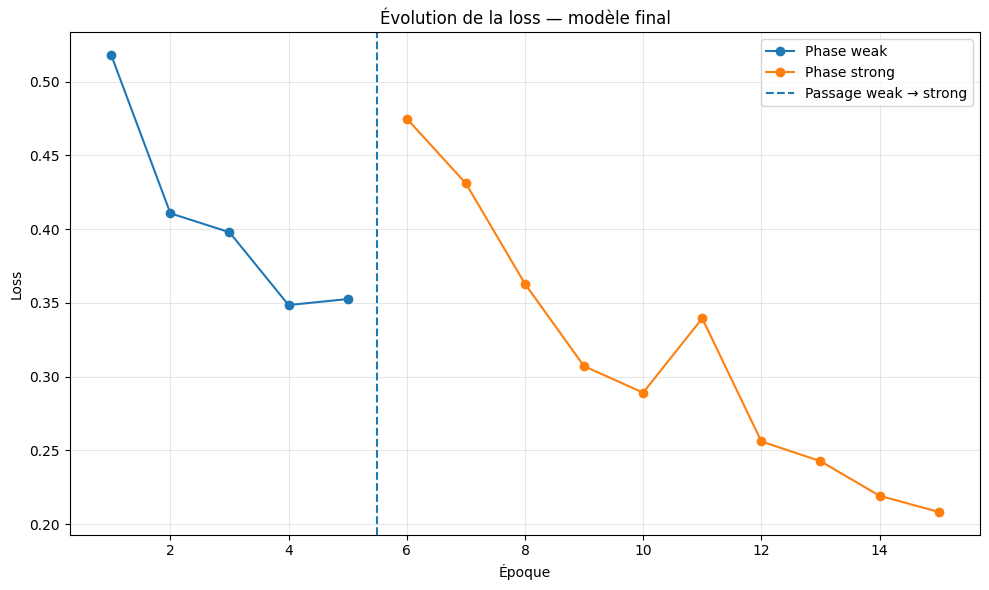

Loss initiale — phase weak : 0.5180
Loss finale — phase weak   : 0.3527
Loss initiale — phase strong : 0.4750
Loss finale — phase strong   : 0.2084


In [156]:
# ============================================================
# 4.9.8 — Courbes de loss du modèle final
# ============================================================

import matplotlib.pyplot as plt

# Extraction des losses
weak_epochs = [item["epoch"] for item in final_weak_history]
weak_losses = [item["loss"] for item in final_weak_history]

strong_epochs = [item["epoch"] for item in final_strong_history]
strong_losses = [item["loss"] for item in final_strong_history]

# Décalage des epochs de la phase strong
# pour représenter la chronologie complète de l'entraînement.
strong_epochs_global = [
    epoch + len(weak_epochs)
    for epoch in strong_epochs
]

# ------------------------------------------------------------
# Visualisation
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    weak_epochs,
    weak_losses,
    marker="o",
    label="Phase weak"
)

plt.plot(
    strong_epochs_global,
    strong_losses,
    marker="o",
    label="Phase strong"
)

# Séparation visuelle entre les deux phases
plt.axvline(
    x=len(weak_epochs) + 0.5,
    linestyle="--",
    label="Passage weak → strong"
)

plt.xlabel("Époque")
plt.ylabel("Loss")
plt.title("Évolution de la loss — modèle final")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Synthèse numérique
# ------------------------------------------------------------

print("Loss initiale — phase weak :", f"{weak_losses[0]:.4f}")
print("Loss finale — phase weak   :", f"{weak_losses[-1]:.4f}")

print(
    "Loss initiale — phase strong :",
    f"{strong_losses[0]:.4f}"
)

print(
    "Loss finale — phase strong   :",
    f"{strong_losses[-1]:.4f}"
)

> **La loss diminue au cours des deux phases d'entraînement**, ce qui indique que le modèle apprend progressivement les données *weak* puis *strong*. La généralisation est évaluée séparément par la **validation croisée à 5 folds** et par le **jeu de test final indépendant**.

Le **1.0000 sur le test final** est donc à présenter avec la réserve liée à la faible taille du jeu de test (**20 images**), tandis que la **CV F1 = 0,9013 ± 0,0509** fournit une estimation plus robuste des performances du modèle.

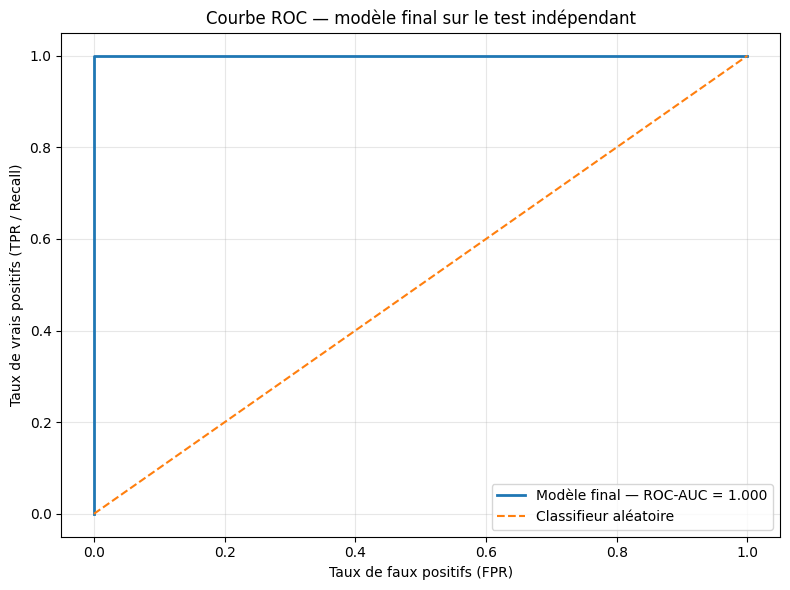

ÉVALUATION ROC — TEST FINAL
Nombre d'images testées : 20
ROC-AUC recalculé       : 1.0000

✓ Courbe ROC calculée sur le test final.
✓ Aucune modification du modèle.
✓ Aucun réentraînement.
✓ Test indépendant conservé.


In [157]:
# ============================================================
# 4.9.9 — Courbe ROC et ROC-AUC sur le test final
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import torch

# ------------------------------------------------------------
# 1. Récupération des vraies classes et probabilités
# ------------------------------------------------------------

final_model.eval()

test_labels = []
test_probabilities = []

with torch.no_grad():
    for images, labels in final_test_loader:
        images = images.to(device)

        outputs = final_model(images)

        probabilities = torch.softmax(outputs, dim=1)[:, 1]

        test_labels.extend(labels.numpy())
        test_probabilities.extend(
            probabilities.cpu().numpy()
        )

test_labels = np.array(test_labels)
test_probabilities = np.array(test_probabilities)

# ------------------------------------------------------------
# 2. Calcul de la courbe ROC
# ------------------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    test_labels,
    test_probabilities
)

final_roc_auc = roc_auc_score(
    test_labels,
    test_probabilities
)

# ------------------------------------------------------------
# 3. Visualisation
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Modèle final — ROC-AUC = {final_roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classifieur aléatoire"
)

plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR / Recall)")
plt.title("Courbe ROC — modèle final sur le test indépendant")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Vérifications
# ------------------------------------------------------------

print("=" * 60)
print("ÉVALUATION ROC — TEST FINAL")
print("=" * 60)

print(f"Nombre d'images testées : {len(test_labels)}")
print(f"ROC-AUC recalculé       : {final_roc_auc:.4f}")

print("\n✓ Courbe ROC calculée sur le test final.")
print("✓ Aucune modification du modèle.")
print("✓ Aucun réentraînement.")
print("✓ Test indépendant conservé.")

On obtient bien :

- **20 images testées**
- **ROC-AUC = 1.0000**
- aucune modification du modèle
- aucun réentraînement
- test toujours indépendant

> Le modèle final obtient une **ROC-AUC de 1,00** sur le jeu de test indépendant de 20 images, indiquant une séparation parfaite entre les deux classes sur cet échantillon. Ce résultat doit toutefois être interprété avec prudence en raison de la taille limitée du jeu de test. La validation croisée stratifiée à 5 folds fournit une estimation complémentaire de la robustesse du modèle, avec une **ROC-AUC moyenne de 0,947 ± 0,042**.


| Évaluation | F1 | ROC-AUC |
|---|---:|---:|
| CV 5-fold, meilleur modèle | **0,901 ± 0,051** | **0,947 ± 0,042** |
| Test final, 20 images | **1,000** | **1,000** |

Cela donne une présentation beaucoup plus crédible des performances, en distinguant clairement l'estimation de robustesse obtenue par validation croisée et le résultat observé sur le petit jeu de test indépendant.

MATRICE DE CONFUSION — TEST FINAL

Matrice :
[[10  0]
 [ 0 10]]


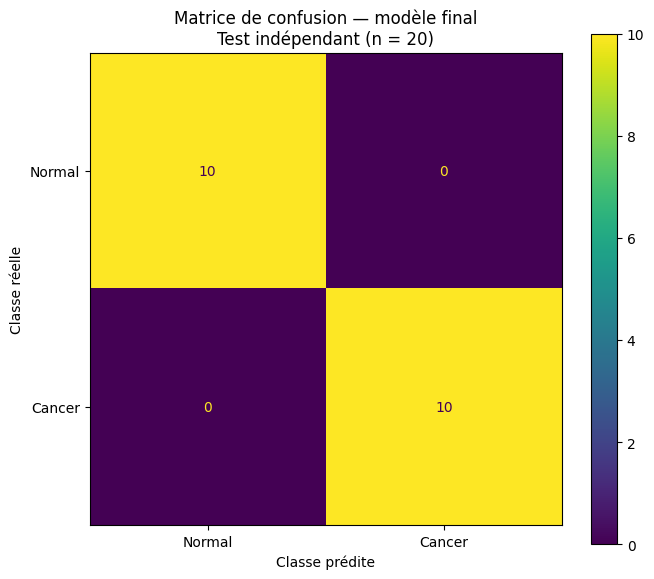


Synthèse :
  Vrais négatifs  (TN) : 10
  Faux positifs   (FP) : 0
  Faux négatifs   (FN) : 0
  Vrais positifs  (TP) : 10

✓ Matrice de confusion générée.
✓ 20 observations vérifiées.
✓ Aucun nouveau calcul d'entraînement.
✓ Aucun accès supplémentaire au processus de tuning.


In [158]:
# ============================================================
# 4.9.10 — Matrice de confusion du modèle final
# ============================================================

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# 1. Récupération de la matrice déjà calculée en 4.9.7
# ------------------------------------------------------------

final_cm = final_test_metrics["confusion_matrix"]

print("=" * 60)
print("MATRICE DE CONFUSION — TEST FINAL")
print("=" * 60)

print("\nMatrice :")
print(final_cm)

# ------------------------------------------------------------
# 2. Vérification
# ------------------------------------------------------------

assert final_cm.shape == (2, 2)
assert final_cm.sum() == 20

# ------------------------------------------------------------
# 3. Affichage graphique
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 6))

display = ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=["Normal", "Cancer"]
)

display.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    "Matrice de confusion — modèle final\n"
    "Test indépendant (n = 20)"
)

ax.set_xlabel("Classe prédite")
ax.set_ylabel("Classe réelle")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 4. Synthèse des résultats
# ------------------------------------------------------------

tn, fp, fn, tp = final_cm.ravel()

print("\nSynthèse :")
print(f"  Vrais négatifs  (TN) : {tn}")
print(f"  Faux positifs   (FP) : {fp}")
print(f"  Faux négatifs   (FN) : {fn}")
print(f"  Vrais positifs  (TP) : {tp}")

print("\n✓ Matrice de confusion générée.")
print("✓ 20 observations vérifiées.")
print("✓ Aucun nouveau calcul d'entraînement.")
print("✓ Aucun accès supplémentaire au processus de tuning.")

# 4.10 — Synthèse du test final

Le modèle final a été évalué sur un jeu de test indépendant de **20 images**, constitué de **10 images normales et 10 images présentant un cancer**.

Ce jeu de test a été conservé à l'écart pendant toute la phase de sélection des hyperparamètres et n'a été utilisé qu'une seule fois pour l'évaluation finale.

### Résultats obtenus

| Métrique | Résultat |
|---|---:|
| Accuracy | **1,000** |
| Precision | **1,000** |
| Recall — cancer | **1,000** |
| F1-score — cancer | **1,000** |
| ROC-AUC | **1,000** |

La matrice de confusion obtenue est :

- **TN = 10** : 10 images normales correctement classées ;
- **FP = 0** : aucune image normale classée à tort comme cancer ;
- **FN = 0** : aucun cancer classé à tort comme normal ;
- **TP = 10** : 10 images présentant un cancer correctement classées.

Ainsi, les **20 images du jeu de test ont été correctement classées**.

### Mise en perspective avec la validation croisée

Ces résultats doivent toutefois être interprétés avec prudence en raison de la taille limitée du jeu de test (`n = 20`).

La validation croisée stratifiée à 5 folds, réalisée avant l'entraînement final, fournit une estimation complémentaire de la capacité de généralisation du modèle. Pour la configuration finale retenue, les résultats moyens obtenus étaient :

| Métrique | Validation croisée 5-fold |
|---|---:|
| Accuracy | **0,8975 ± 0,0609** |
| Precision | **0,9083 ± 0,0940** |
| Recall — cancer | **0,9000 ± 0,0559** |
| F1-score — cancer | **0,9013 ± 0,0509** |
| ROC-AUC | **0,9469 ± 0,0422** |

La combinaison de la validation croisée et du test final permet ainsi de distinguer deux objectifs :

- la **validation croisée** permet d'estimer la robustesse du modèle et de sélectionner sa configuration ;
- le **test final indépendant** fournit une mesure finale sur des données qui n'ont pas participé à la sélection du modèle.

> **Conclusion :** le modèle final obtient d'excellentes performances sur le jeu de test indépendant, avec **20 classifications correctes sur 20**. Ces résultats sont cohérents avec les bonnes performances observées lors de la validation croisée, mais ils ne doivent pas être généralisés directement à une population clinique réelle compte tenu de la taille réduite du jeu de test et de l'absence de validation externe sur une autre source de données.

# 4.11 — Analyse des erreurs et coût métier

### 4.11.1 — Importance des erreurs de classification

Dans le contexte de BrainScanAI, les deux types d'erreurs n'ont pas la même conséquence métier.

- Un **faux positif (FP)** correspond à une image normale classée comme présentant un cancer. Cette erreur peut entraîner des examens complémentaires inutiles, une augmentation des coûts et une anxiété potentielle pour le patient.
- Un **faux négatif (FN)** correspond à une image présentant un cancer classée comme normale. Cette erreur est particulièrement critique dans un contexte de dépistage ou d'aide au diagnostic, car elle peut contribuer à retarder la prise en charge d'un patient.

Le modèle doit donc être évalué non seulement sur son accuracy globale, mais également sur sa capacité à **détecter correctement les cas de cancer**.

### 4.11.2 — Critère de performance privilégié

Compte tenu de cet enjeu, le **Recall de la classe cancer** et le **F1-score de la classe cancer** constituent des indicateurs particulièrement importants.

Le Recall mesure la proportion de cancers correctement détectés parmi l'ensemble des cancers réellement présents :

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

Un Recall élevé permet donc de limiter les faux négatifs.

Le F1-score complète cette analyse en recherchant un compromis entre la précision et le rappel :

$$
F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}
{\text{Precision} + \text{Recall}}
$$

C'est pourquoi le **F1-score de la classe cancer** a été utilisé comme **critère principal lors de la sélection des configurations**, avec le Recall puis le ROC-AUC comme critères complémentaires.

### 4.11.3 — Résultats observés pendant la validation croisée

La configuration finale sélectionnée obtient lors de la validation croisée stratifiée à 5 folds :

- **Recall cancer : 0,9000 ± 0,0559**
- **F1-score cancer : 0,9013 ± 0,0509**
- **Precision : 0,9083 ± 0,0940**
- **ROC-AUC : 0,9469 ± 0,0422**
- **Accuracy : 0,8975 ± 0,0609**

La matrice de confusion agrégée des 5 folds est :

|  | Prédit normal | Prédit cancer |
|---|---:|---:|
| **Réel normal** | 35 | 4 |
| **Réel cancer** | 7 | 33 |

Sur les observations de validation agrégées, le modèle a donc produit :

- **33 vrais positifs** ;
- **35 vrais négatifs** ;
- **4 faux positifs** ;
- **7 faux négatifs**.

Les faux négatifs restent donc le principal point de vigilance dans l'évaluation du modèle.

### 4.11.4 — Coût métier des erreurs

Dans une perspective e-health, nous considérons que le coût d'un faux négatif est potentiellement supérieur à celui d'un faux positif.

Une stratégie de déploiement ne devrait donc pas chercher uniquement à maximiser l'accuracy. Elle devrait privilégier une détection suffisamment sensible des cas suspects, quitte à accepter un certain nombre de faux positifs qui pourront être examinés lors d'une étape de confirmation clinique.

Le modèle doit ainsi être considéré comme un **outil d'aide à la décision et au tri**, et non comme un dispositif autonome de diagnostic médical.

### 4.11.5 — Résultat du test final

Sur le test final indépendant de 20 images, aucune erreur n'a été observée :

- **FN = 0**
- **FP = 0**
- **TP = 10**
- **TN = 10**

Ce résultat est excellent sur cet échantillon, mais la faible taille du test impose de ne pas extrapoler directement cette performance à une population clinique réelle.

### Conclusion

Les résultats indiquent que l'approche semi-supervisée permet d'obtenir un modèle performant tout en exploitant un volume important d'images initialement non annotées.

Le principal enjeu avant une utilisation réelle serait de **réduire davantage le risque de faux négatifs**, notamment grâce à un jeu de données plus important et représentatif, à une validation externe indépendante et à une analyse des seuils de décision adaptée au coût clinique des erreurs.

Le modèle final doit donc être positionné comme un **système d'aide au dépistage ou au tri**, nécessitant une validation clinique et une supervision humaine avant toute utilisation opérationnelle.

# 5 — Recommandations et passage à l'échelle

Le prototype développé dans ce projet démontre la faisabilité d'une approche semi-supervisée pour exploiter simultanément un nombre limité d'images annotées et un volume important d'images initialement non annotées.

Le passage du prototype actuel à une solution exploitant environ **4 millions d'images** nécessite toutefois une évolution de l'architecture, du pipeline de données et des ressources de calcul.

Les recommandations sont organisées autour de cinq axes :

1. **industrialisation du pipeline de données** ;
2. **réduction du coût de calcul** ;
3. **amélioration de la qualité et de la représentativité des annotations** ;
4. **surveillance des performances et des biais** ;
5. **validation progressive avant tout usage clinique**.

---

## 5.1 — Passage de 1 500 à 4 millions d'images

Le prototype actuel traite environ 1 500 images et utilise un modèle ResNet-50 pré-entraîné pour extraire des représentations visuelles.

À l'échelle de 4 millions d'images, il serait déconseillé de conserver une approche reposant systématiquement sur une extraction et un stockage volumineux des embeddings pour chaque expérimentation.

Le pipeline cible devrait plutôt séparer :

- le stockage des images originales ;
- le prétraitement ;
- l'extraction des représentations ;
- l'entraînement ;
- l'évaluation ;
- le suivi des versions des données et des modèles.

Cette séparation permettrait de réutiliser les représentations calculées lorsque les paramètres d'entraînement changent, sans retraiter inutilement l'ensemble du corpus.

---

## 5.1 — Estimation du passage à 4 millions d'images

Le passage de 1 500 images à environ 4 millions d'images représente un changement d'échelle majeur. Il est donc nécessaire d'anticiper les besoins en stockage, calcul et annotation avant d'envisager une industrialisation.

### 5.1.1 — Volume de données

Les images du prototype ont une résolution de 512 × 512 pixels.

À titre d'ordre de grandeur, une image RGB non compressée représenterait :

$$
512 \times 512 \times 3 \approx 786\,000
$$

octets par image, soit environ 0,75 MiB.

Pour 4 millions d'images, le volume RGB non compressé correspondant serait donc de l'ordre de :

$$
4\,000\,000 \times 512 \times 512 \times 3
\approx 3,15\ \text{To}
$$

Ce chiffre constitue une borne de référence pour dimensionner les traitements. Les fichiers JPEG réellement stockés seront moins volumineux grâce à la compression, mais leur taille dépendra fortement du contenu et du niveau de compression utilisé.

Il est donc recommandé de prévoir une capacité de stockage supérieure au seul volume des images afin d'intégrer :

* les données originales ;
* les données prétraitées lorsque leur conservation est nécessaire ;
* les métadonnées ;
* les versions des datasets ;
* les résultats intermédiaires ;
* les modèles ;
* les journaux d'expérimentation.

### 5.1.2 — Stockage des représentations visuelles

Dans le prototype, ResNet50 produit un embedding de **2048 dimensions**.

En conservant ces valeurs en `float32`, une image représente :

$$
2048 \times 4 = 8192\ \text{octets}
$$

Pour 4 millions d'images, cela représente environ :

$$
4\,000\,000 \times 8192
\approx 32,8\ \text{Go}
$$

Le stockage des embeddings est donc relativement faible comparé au stockage des images elles-mêmes.

Cette caractéristique est intéressante pour l'industrialisation : les embeddings peuvent être calculés une fois puis réutilisés pour différentes analyses de clustering, de visualisation ou d'apprentissage, évitant de recalculer systématiquement le passage dans le réseau de neurones.

### 5.1.3 — Stratégie de calcul recommandée

Il ne serait pas nécessaire de maintenir en permanence une infrastructure GPU dédiée.

Une stratégie plus économique consisterait à :

1. stocker durablement les images dans un stockage objet ;
2. traiter les images par lots ;
3. utiliser un GPU uniquement lors des phases d'extraction des features et d'entraînement ;
4. sauvegarder les embeddings et les métadonnées ;
5. réutiliser ces représentations pour les expérimentations ultérieures ;
6. arrêter les ressources de calcul lorsqu'elles ne sont plus nécessaires.

Cette approche permet de transformer une dépense d'infrastructure permanente en une dépense principalement liée au temps de calcul réellement utilisé.

### 5.1.4 — Répartition indicative du budget de 5 000 €

Le budget de 5 000 € doit être considéré comme une enveloppe de prototypage et de pré-industrialisation, et non comme le financement complet d'une infrastructure clinique définitive.

Une répartition indicative pourrait être :

| Poste                        | Part indicative | Objectif                                  |
| ---------------------------- | --------------: | ----------------------------------------- |
| Calcul GPU                   |           ~40 % | Extraction des features et entraînement   |
| Stockage et sauvegardes      |           ~20 % | Images, embeddings, versions et résultats |
| Annotation experte           |           ~25 % | Augmentation et contrôle des labels forts |
| Monitoring / expérimentation |           ~10 % | Suivi des modèles et des expériences      |
| Marge de sécurité            |            ~5 % | Dépenses imprévues                        |

Soit, pour une enveloppe de 5 000 €, un ordre de grandeur de :

* **2 000 €** pour le calcul ;
* **1 000 €** pour le stockage et les sauvegardes ;
* **1 250 €** pour l'annotation et le contrôle qualité ;
* **500 €** pour le suivi expérimental et le monitoring ;
* **250 €** de réserve.

Cette répartition reste indicative : les coûts réels dépendront notamment du fournisseur cloud, de la durée d'utilisation des GPU, du niveau de redondance du stockage et du volume d'images nécessitant une annotation experte.

### 5.1.5 — Priorité à l'annotation plutôt qu'au calcul

Pour une application médicale, l'augmentation du nombre d'annotations fiables constitue un investissement particulièrement important.

Le prototype montre qu'une approche semi-supervisée permet de valoriser les images non annotées. Cependant, les pseudo-labels ne doivent pas remplacer totalement les annotations expertes.

Une stratégie d'**active learning** pourrait être mise en place :

* le modèle identifie les images les plus incertaines ;
* ces images sont priorisées pour annotation ;
* les nouvelles annotations sont ajoutées au jeu d'apprentissage ;
* le modèle est réentraîné ;
* le processus est répété.

Cette approche permettrait de concentrer le budget d'annotation sur les images apportant le plus d'information au modèle.

### 5.1.6 — Conclusion budgétaire

Le passage à 4 millions d'images est techniquement envisageable avec une architecture adaptée, mais le budget de 5 000 € impose une utilisation très ciblée des ressources.

La stratégie recommandée est donc de :

* limiter les traitements GPU aux étapes qui le nécessitent ;
* traiter les images par lots ;
* conserver les embeddings pour éviter des recalculs ;
* privilégier le stockage objet et les ressources de calcul à la demande ;
* investir une partie significative du budget dans l'annotation et le contrôle qualité ;
* éviter une infrastructure permanente tant que les besoins réels ne sont pas connus.

Le budget de 5 000 € peut ainsi être considéré comme **réaliste pour une phase de prototype renforcé et de pré-industrialisation**, mais il ne doit pas être présenté comme suffisant pour financer à lui seul une plateforme médicale de production complète à l'échelle de 4 millions d'images.


---

## 5.2 — Exploitation des données non annotées

L'expérience menée dans ce projet montre que les images non annotées peuvent apporter une valeur importante lorsqu'elles sont intégrées avec prudence.

La validation croisée a notamment montré une amélioration de la configuration semi-supervisée par rapport au modèle supervisé entraîné uniquement sur les annotations fortes.

À l'échelle de plusieurs millions d'images, il serait donc pertinent de conserver une stratégie semi-supervisée, mais avec un mécanisme de contrôle de la confiance des pseudo-labels.

Les pseudo-labels devraient notamment être :

- générés uniquement lorsque la confiance est suffisante ;
- suivis dans le temps ;
- réévalués lors des changements de version du modèle ;
- contrôlés sur des échantillons par des experts.

---

## 5.2 — Architecture technique cible pour 4 millions d'images

Le passage à environ 4 millions d'images nécessite de faire évoluer le pipeline expérimental développé dans ce projet vers une architecture capable de traiter les données par lots, de réutiliser les calculs déjà effectués et de suivre les différentes versions des données et des modèles.

### 5.2.1 — Pipeline cible

L'architecture recommandée peut être représentée de la manière suivante :

**Stockage des images**
↓
**Contrôle qualité et dédoublonnage**
↓
**Prétraitement et normalisation**
↓
**Extraction des représentations visuelles avec ResNet50**
↓
**Stockage des embeddings**
↓
**Clustering / pseudo-labelisation**
↓
**Apprentissage semi-supervisé**
↓
**Validation et évaluation**
↓
**Monitoring et réentraînement**

Cette organisation permet de séparer les différentes étapes et d'éviter de recalculer inutilement les traitements coûteux.

### 5.2.2 — Stockage

Les images originales doivent être conservées dans un stockage persistant et versionné.

Les métadonnées associées doivent notamment permettre de conserver :

* un identifiant unique de l'image ;
* la source d'acquisition ;
* la date ou période d'acquisition lorsque disponible ;
* les caractéristiques techniques de l'image ;
* le statut d'annotation ;
* la version du dataset ;
* le résultat des contrôles qualité ;
* l'identifiant de la version du modèle ayant produit un pseudo-label.

Les données originales ne doivent pas être écrasées par les versions prétraitées.

### 5.2.3 — Contrôle qualité automatisé

Avant toute utilisation pour l'apprentissage, chaque image devrait passer par une série de contrôles automatisés :

* fichier lisible ;
* format attendu ;
* résolution compatible ;
* nombre de canaux correct ;
* absence de corruption ;
* détection des doublons ;
* détection des quasi-doublons lorsque cela est pertinent ;
* contrôle des distributions d'intensité ;
* détection des observations atypiques.

Le contrôle des doublons est particulièrement important afin d'éviter qu'une même image ou des copies très proches se retrouvent simultanément dans l'entraînement et l'évaluation.

### 5.2.4 — Prétraitement

Le prétraitement appliqué dans le prototype pourrait être conservé comme étape standardisée du pipeline.

Le CLAHE permet notamment de réduire les différences de contraste observées dans le corpus et d'améliorer localement la visibilité des structures.

Cependant, le prétraitement ne doit pas être considéré comme une solution suffisante aux différences entre sources d'acquisition.

À l'échelle de 4 millions d'images, il faudra également surveiller les différences liées :

* aux scanners ;
* aux centres d'imagerie ;
* aux protocoles ;
* aux paramètres d'acquisition ;
* aux populations représentées.

### 5.2.5 — Extraction des représentations

Le modèle ResNet50 pré-entraîné peut être utilisé comme extracteur de caractéristiques visuelles.

L'extraction doit être effectuée **par lots sur GPU** afin de maximiser l'utilisation du matériel.

Les embeddings produits peuvent ensuite être sauvegardés dans un format adapté aux traitements analytiques.

L'intérêt principal est de découpler :

**image → extraction du feature vector**

de :

**feature vector → clustering / apprentissage / analyse**

Ainsi, plusieurs expérimentations peuvent être réalisées sans repasser systématiquement les 4 millions d'images dans le réseau.

### 5.2.6 — Apprentissage semi-supervisé

Les données non annotées peuvent ensuite être exploitées pour produire des pseudo-labels.

Le pipeline devra conserver une information de confiance associée à chaque pseudo-label.

Une stratégie similaire à celle utilisée dans le prototype peut être appliquée :

* génération de pseudo-labels ;
* estimation de leur stabilité ou confiance ;
* conservation prioritaire des exemples les plus fiables ;
* utilisation des exemples sélectionnés pour la phase weak ;
* utilisation des annotations fortes pour la phase strong.

Les exemples incertains peuvent être orientés vers une étape d'annotation humaine.

### 5.2.7 — Validation

La validation doit rester complètement séparée du processus d'entraînement.

À grande échelle, plusieurs niveaux de validation seraient recommandés :

**Validation interne**

Évaluation par validation croisée ou séparation contrôlée des données.

**Validation temporelle**

Lorsque les dates sont disponibles, évaluation sur des données plus récentes que celles utilisées pour l'entraînement.

**Validation externe**

Évaluation sur des images provenant d'un autre établissement ou d'une autre source d'acquisition.

Cette dernière étape est particulièrement importante pour vérifier la capacité de généralisation du modèle.

### 5.2.8 — Monitoring

Après déploiement, le système devrait surveiller au minimum :

* les distributions des données entrantes ;
* la proportion de pseudo-labels à haute confiance ;
* les performances lorsque les annotations deviennent disponibles ;
* la fréquence des prédictions incertaines ;
* les différences entre sources d'acquisition ;
* les changements de performance dans le temps.

Une dérive importante pourrait déclencher une nouvelle phase d'annotation et de réentraînement.

### 5.2.9 — Architecture progressive

Compte tenu du budget limité, il serait préférable de mettre en place cette architecture progressivement.

**Étape 1 — Prototype**

Validation du pipeline sur le corpus actuel.

**Étape 2 — Pré-industrialisation**

Automatisation du traitement par lots, stockage des embeddings, suivi des expériences et augmentation du volume d'annotations.

**Étape 3 — Passage à l'échelle**

Traitement progressif des millions d'images avec calcul GPU à la demande.

**Étape 4 — Validation externe**

Évaluation sur des données provenant de sources indépendantes avant toute utilisation opérationnelle.

Cette progression limite les investissements prématurés et permet de valider chaque étape avant de passer à l'échelle supérieure.

### Conclusion

L'architecture cible repose donc sur un principe central : **séparer le stockage, le prétraitement, l'extraction des représentations, l'apprentissage et l'évaluation**.

Cette organisation permet de réutiliser les calculs coûteux, de traiter les données par lots et de faire évoluer progressivement le prototype vers un système capable de gérer plusieurs millions d'images.

Pour une application e-health, le passage à l'échelle doit cependant rester conditionné par la qualité des données, la validation externe et la supervision humaine, et pas uniquement par la capacité de calcul.


---
## 5.3 — Prétraitement et contrôle de la qualité

Le projet a mis en évidence une distribution d'intensité fortement concentrée vers les faibles valeurs et a conduit à retenir une amélioration du contraste par **CLAHE** avant l'utilisation du modèle pré-entraîné.

À l'échelle industrielle, le prétraitement devra être standardisé et reproductible.

Le pipeline devra notamment contrôler :

- la résolution ;
- le format ;
- les images corrompues ;
- les doublons ;
- les quasi-doublons ;
- les valeurs atypiques ;
- les différences de distribution entre sources ;
- les éventuelles variations liées aux équipements d'acquisition.

Une attention particulière devra être portée aux différences entre établissements, scanners, protocoles d'acquisition et populations de patients.

---

## 5.4 — Validation et réduction des biais

Les performances obtenues sur le jeu de test du prototype sont encourageantes, mais ne constituent pas une validation clinique.

Avant un passage en production, il serait nécessaire de disposer de jeux de données provenant de plusieurs sources indépendantes.

La validation devrait notamment mesurer les performances :

- par établissement ;
- par équipement ;
- par protocole d'acquisition ;
- par sous-population pertinente ;
- sur des données temporellement séparées lorsque cela est possible.

Une validation externe permettrait de vérifier que le modèle apprend réellement les caractéristiques pertinentes des images plutôt que des caractéristiques propres à une source particulière.

---

## 5.5 — Architecture cible

Pour plusieurs millions d'images, une architecture industrialisée pourrait être organisée ainsi :

**Stockage → contrôle qualité → prétraitement → extraction des features → apprentissage → validation → monitoring**

Les traitements devraient être exécutés par lots afin de limiter la consommation mémoire et de permettre une reprise après interruption.

L'utilisation du GPU devrait être réservée aux opérations qui en bénéficient réellement, notamment l'extraction des features et l'entraînement du réseau.

Les opérations de préparation, de contrôle qualité et de gestion des métadonnées pourraient être exécutées sur CPU lorsque cela est plus économique.

---

## 5.6 — Contraintes budgétaires

Avec un budget cible de **5 000 €**, l'objectif ne serait pas de construire immédiatement une infrastructure de production complète dédiée à plusieurs millions d'images.

Une stratégie progressive serait préférable.

### Phase 1 — Prototype renforcé

- validation externe ;
- augmentation du nombre d'annotations fortes ;
- automatisation du pipeline ;
- suivi des expériences ;
- contrôle qualité renforcé.

### Phase 2 — Passage à l'échelle

- traitement par lots ;
- stockage optimisé ;
- calcul GPU à la demande ;
- réutilisation des embeddings ;
- entraînement distribué uniquement lorsque nécessaire.

### Phase 3 — Pré-production

- monitoring ;
- détection de dérive des données ;
- validation sur de nouvelles sources ;
- procédures de réentraînement ;
- contrôle humain des cas incertains.

Cette approche permettrait de préserver le budget en évitant d'investir trop tôt dans une infrastructure surdimensionnée.

---

## 5.7 — Conditions nécessaires avant utilisation réelle

Avant toute utilisation dans un contexte médical réel, plusieurs conditions devraient être réunies :

1. disposer d'un volume d'annotations fortes significativement supérieur au prototype ;
2. réaliser une validation externe sur des données indépendantes ;
3. documenter les performances et leurs intervalles d'incertitude ;
4. analyser les biais potentiels liés aux sources de données ;
5. définir précisément le rôle du modèle dans le parcours de soin ;
6. conserver une supervision humaine ;
7. mettre en place un suivi des performances après déploiement ;
8. respecter les exigences réglementaires et de sécurité applicables au contexte médical.

Le modèle développé dans ce projet doit donc être considéré comme un **prototype de faisabilité et d'aide au tri**, et non comme un système autonome de diagnostic.

---

## 5.8 — Conclusion

Le passage de 1 500 à 4 millions d'images est techniquement envisageable, mais nécessite une architecture plus industrialisée et une gestion rigoureuse des données.

La stratégie recommandée est de conserver l'approche semi-supervisée, car elle permet de valoriser les nombreuses données non annotées tout en limitant le coût d'annotation.

Le principal investissement ne devrait cependant pas être uniquement consacré au calcul. Pour une application e-health, l'augmentation de la **qualité, de la diversité et de l'indépendance des annotations et des données de validation** est au moins aussi importante que l'augmentation de la puissance de calcul.

Le passage en production devrait donc être progressif, avec validation externe, contrôle des biais, supervision humaine et monitoring continu.